<h1 style="color: #CEDDF4;">DEPI Round 4, MS Data Engineer and AI Track</h1>
<h2 style="color: #CEDDF4;" >Final Project: Gold and Oil Prediction System</h2>
<h3 style="color: #CEDDF4;" > Part (2): Python Code for Machine Learning and Modeling</h3>
<h4 style="color: #CEDDF4;" > 2.3: ML for Stock Market Prices</h4>

In this section, we aim to forecast major stock market prices over a specified timeframe. For the scope of this academic exercise, the prediction window is set from **January 1, 2026, to April 30, 2026**. 

To evaluate performance, we will implement and compare two distinct modeling approaches:

*   **Top Features Model:** This approach utilizes a curated subset of variables identified as having the most significant impact on each individual stock market prices. The exact number of features retained is an adjustable hyperparameter that can be optimized during the model's fine-tuning phase.
*   **Full Feature Model:** This baseline approach incorporates all available features within the dataset to generate predictions.

<h4 style="color: #CEDDF4;" >1. Import Libraries</h4>

In [2]:
import os
import math
from pathlib import Path
from functools import reduce
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score
)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor
import lightgbm as lgb
import joblib
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
import numpy as np
import matplotlib.ticker as mticker

In [3]:
base_dir = Path.cwd()
#raw data path to contain all raw files gathered either manually, web scraping or APIs
raw_data_dir=base_dir/'raw data'
#cleaned data path, will be separated into two main folders which are: market data (contains the data with daily logs) and macroeconomic data
##cleaned market data
cleaned_market_data_dir=base_dir/'cleaned data'/'market_data'
##cleaned macroeconomic data
cleaned_macro_data_dir=base_dir/'cleaned data'/'macroeconomic_data'
##ai modeling data
ai_data_dir=base_dir/'ai model'

<h4 style="color: #CEDDF4;" >2. Data Reading and Processing</h4>

In [4]:
df=pd.read_csv(ai_data_dir/'new_master_table.csv')

<h4 style="color: #CEDDF4;" >2.1 Handling data </h4>

In [5]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True, format='mixed', errors='coerce')
data = df[df['date'] <= '2025-08-30']
data_clean = data.copy()

for col in data_clean.columns:
    if data_clean[col].dtype == "object":
        data_clean[col] = data_clean[col].astype(str).str.replace('%', '', regex=False)
        data_clean[col] = pd.to_numeric(data_clean[col], errors='ignore')
data_clean = data_clean.apply(pd.to_numeric, errors='coerce')
data_clean = data_clean.dropna(axis=1, how='all')

<h4 style="color: #CEDDF4;">3. Egypt (EGX30) Price Prediction</h4>

<h4 style="color: #CEDDF4;"> 3.1 Setup</h4>

In [6]:
# define target variable
target_col_Egypt_EGX30 = 'egx30_price_egp'
# avoid modifying original dataset
df_Egypt_EGX30 = pd.read_csv(ai_data_dir / 'new_master_table.csv')

<h4 style="color: #CEDDF4;"> 3.2 Time preprocessing</h4>

In [7]:
df_Egypt_EGX30['date'] = pd.to_datetime(df_Egypt_EGX30['date'], dayfirst=False, format='mixed', errors='coerce')
df_Egypt_EGX30 = df_Egypt_EGX30.sort_values('date')

<h4 style="color: #CEDDF4;"> 3.3 Remove leakage features</h4>

In [8]:
leakage_keywords_Egypt_EGX30 = [
    '_open_', '_high_', '_low_',     # intraday OHLC leakage on all assets
    '_open',  '_high',  '_low',      # suffix variants
    'gpr_event',                     # forward-looking GPR event flag
    'ai_gpr_Unnamed',                # index artefact
    'gold_price_oz_egp',             # EGP-denominated gold (derived, leaks FX)
    'cbe_inflations_headline_inflation_yy',  # monthly fill creates leakage
    'cbe_inflations_core_inflation_yy',
    '_energy_',                      # all country-level energy mix columns
    'egpusd_value',                  # duplicated by FX cols
    'dollar_historical_data_value',  # duplicated by dollarindex_value
    'cpi_PCPIPCH',                   # duplicate CPI series
]

df_Egypt_EGX30 = df_Egypt_EGX30.drop(columns=[
    c for c in df_Egypt_EGX30.columns
    if any(k in c for k in leakage_keywords_Egypt_EGX30)
], errors='ignore')

#drop all OTHER stock market price columns (cross-market leakage)
other_stock_cols_Egypt_EGX30 = [
    'nasdaq_price_usd',
    'nasdaq_high_usd',
    'nasdaq_low_usd',
    'nasdaq_open_usd',
    'sp500_price_usd',
    'sp500_high_usd',
    'sp500_low_usd',
    'sp500_open_usd',
    'dowjones_price_usd',
    'dowjones_high_usd',
    'dowjones_low_usd',
    'dowjones_open_usd',
    'china_shanghai_price_usd',
    'china_shanghai_high_usd',
    'china_shanghai_low_usd',
    'china_shanghai_open_usd',
    'hongkong_hongkong_price_usd',
    'hongkong_hongkong_high_usd',
    'hongkong_hongkong_low_usd',
    'hongkong_hongkong_open_usd',
    'uk_london_price_usd',
    'uk_london_high_usd',
    'uk_london_low_usd',
    'uk_london_open_usd',
    'japan_tokyo_price_usd',
    'japan_tokyo_high_usd',
    'japan_tokyo_low_usd',
    'japan_tokyo_open_usd',
    'egx30_high_price_egp',
    'egx30_low_price_egp',
    'egx30_change_percent',
]

df_Egypt_EGX30 = df_Egypt_EGX30.drop(columns=[
    c for c in other_stock_cols_Egypt_EGX30 if c in df_Egypt_EGX30.columns
], errors='ignore')

<h4 style="color: #CEDDF4;"> 3.4 feature engineering</h4>

In [9]:
df_Egypt_EGX30['real_rate_us'] = df_Egypt_EGX30['usd_fedfunds_value'] - df_Egypt_EGX30['cpi_value']            # US real interest rate
df_Egypt_EGX30['real_rate_eu'] = df_Egypt_EGX30['euro_interest_value'] - df_Egypt_EGX30['euro_inflation_value']  # EU real interest rate

df_Egypt_EGX30['yield_spread_10_2'] = (                                                               # US yield curve spread
    df_Egypt_EGX30['10y_treasury_historical_data_monthly_value'] -
    df_Egypt_EGX30['2y_treasury_historical_data_monthly_value']
)
df_Egypt_EGX30['yield_spread_10_1'] = (                                                               # short-end spread
    df_Egypt_EGX30['10y_treasury_historical_data_monthly_value'] -
    df_Egypt_EGX30['1y_treasury_historical_data_monthly_value']
)

df_Egypt_EGX30['oil_x_dxy']  = df_Egypt_EGX30['brent_oil_price_usd'] * df_Egypt_EGX30['dollarindex_value']     # oil × dollar interaction
df_Egypt_EGX30['vix_x_dxy']  = df_Egypt_EGX30['vix_price_usd']       * df_Egypt_EGX30['dollarindex_value']     # volatility × dollar interaction
df_Egypt_EGX30['gold_x_dxy'] = df_Egypt_EGX30['gold_price_usd']      * df_Egypt_EGX30['dollarindex_value']     # gold × dollar interaction

df_Egypt_EGX30['vix_mom']  = df_Egypt_EGX30['vix_price_usd'].pct_change()        # VIX momentum (risk-on/off)
df_Egypt_EGX30['oil_mom']  = df_Egypt_EGX30['brent_oil_price_usd'].pct_change()  # oil momentum
df_Egypt_EGX30['gold_mom'] = df_Egypt_EGX30['gold_price_usd'].pct_change()       # gold momentum

df_Egypt_EGX30['log_price'] = np.log(df_Egypt_EGX30[target_col_Egypt_EGX30])  # log transformation for stability
df_Egypt_EGX30['return']    = df_Egypt_EGX30['log_price'].diff()            # daily log-return

# ── simple moving averages & distance from SMA (trend-following signals) ──────
for w in [5, 10, 20, 50]:
    df_Egypt_EGX30[f'sma_{w}']          = df_Egypt_EGX30[target_col_Egypt_EGX30].rolling(w).mean().shift(1)
    df_Egypt_EGX30[f'price_vs_sma_{w}'] = (df_Egypt_EGX30[target_col_Egypt_EGX30] / df_Egypt_EGX30[f'sma_{w}'] - 1).shift(1)

# ── RSI-14 (momentum oscillator) ──────────────────────────────────────────────
_delta_Egypt_EGX30    = df_Egypt_EGX30['return'].clip(lower=0)
_loss_Egypt_EGX30     = (-df_Egypt_EGX30['return']).clip(lower=0)
_avg_gain_Egypt_EGX30 = _delta_Egypt_EGX30.rolling(14).mean()
_avg_loss_Egypt_EGX30 = _loss_Egypt_EGX30.rolling(14).mean().replace(0, 1e-9)
df_Egypt_EGX30['rsi_14'] = (100 - 100 / (1 + _avg_gain_Egypt_EGX30 / _avg_loss_Egypt_EGX30)).shift(1)

# ── Bollinger Band width (volatility regime signal) ───────────────────────────
_bb_mid_Egypt_EGX30       = df_Egypt_EGX30[target_col_Egypt_EGX30].rolling(20).mean()
_bb_std_Egypt_EGX30       = df_Egypt_EGX30[target_col_Egypt_EGX30].rolling(20).std()
df_Egypt_EGX30['bb_width']= (4 * _bb_std_Egypt_EGX30 / _bb_mid_Egypt_EGX30).shift(1)  # normalised bandwidth

# ── calendar features ─────────────────────────────────────────────────────────
df_Egypt_EGX30['day_of_week']    = df_Egypt_EGX30['date'].dt.dayofweek    # Mon=0 … Fri=4
df_Egypt_EGX30['month']          = df_Egypt_EGX30['date'].dt.month
df_Egypt_EGX30['quarter']        = df_Egypt_EGX30['date'].dt.quarter
df_Egypt_EGX30['is_month_end']   = df_Egypt_EGX30['date'].dt.is_month_end.astype(int)
df_Egypt_EGX30['is_quarter_end'] = df_Egypt_EGX30['date'].dt.is_quarter_end.astype(int)

# ── target: next-day smoothed return (identical to gold/oil model) ────────────
df_Egypt_EGX30['target'] = df_Egypt_EGX30['return'].rolling(5).mean().shift(-1)  # future smoothed return target
df_Egypt_EGX30['target'] = df_Egypt_EGX30['target'].clip(-0.03, 0.03)            # limit extreme values

for lag in [1, 2, 3, 5, 10, 20]:
    df_Egypt_EGX30[f'return_lag_{lag}'] = df_Egypt_EGX30['return'].shift(lag)  # past returns

df_Egypt_EGX30['log_price_lag1'] = df_Egypt_EGX30['log_price'].shift(1)  # previous price level

# ── lagged macro signals (prevent same-day leakage) ──────────────────────────
df_Egypt_EGX30['vix_lag1']      = df_Egypt_EGX30['vix_price_usd'].shift(1)   # yesterday's fear index
df_Egypt_EGX30['gold_lag1']     = df_Egypt_EGX30['gold_price_usd'].shift(1)  # yesterday's gold price
df_Egypt_EGX30['oil_lag1']      = df_Egypt_EGX30['brent_oil_price_usd'].shift(1)  # yesterday's oil price
df_Egypt_EGX30['dxy_lag1']      = df_Egypt_EGX30['dollarindex_value'].shift(1)    # yesterday's dollar index

df_Egypt_EGX30['vol_7']         = df_Egypt_EGX30['return'].rolling(7).std().shift(1)    # short-term realised volatility
df_Egypt_EGX30['vol_20']        = df_Egypt_EGX30['return'].rolling(20).std().shift(1)   # medium-term realised volatility
df_Egypt_EGX30['vol_ratio']     = df_Egypt_EGX30['vol_7'] / (df_Egypt_EGX30['vol_20'] + 1e-9)  # vol regime: >1 = expanding

df_Egypt_EGX30['mom_7']         = df_Egypt_EGX30['return'].rolling(7).mean().shift(1)   # short-term momentum
df_Egypt_EGX30['mom_20']        = df_Egypt_EGX30['return'].rolling(20).mean().shift(1)  # medium-term momentum
df_Egypt_EGX30['mom_crossover'] = df_Egypt_EGX30['mom_7'] - df_Egypt_EGX30['mom_20']           # momentum crossover signal

df_Egypt_EGX30['price_trend_7'] = df_Egypt_EGX30[target_col_Egypt_EGX30].rolling(7).mean().shift(1)   # 7-day price trend
df_Egypt_EGX30['price_trend_20']= df_Egypt_EGX30[target_col_Egypt_EGX30].rolling(20).mean().shift(1)  # 20-day price trend

C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\2866488158.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_Egypt_EGX30['dxy_lag1']      = df_Egypt_EGX30['dollarindex_value'].shift(1)    # yesterday's dollar index
C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\2866488158.py:63: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_Egypt_EGX30['vol_7']         = df_Egypt_EGX30['return'].rolling(7).std().shift(1)    # short-term realised volatility
C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\2866488158.py:64: Performance

<h4 style="color: #CEDDF4;"> 3.5 Data cleaning</h4>

In [10]:
df_Egypt_EGX30 = df_Egypt_EGX30.dropna()  # remove missing values

<h4 style="color: #CEDDF4;"> 3.6 Feature selection</h4>

In [11]:
features_Egypt_EGX30 = [c for c in df_Egypt_EGX30.columns if c not in ['date', target_col_Egypt_EGX30, 'target']]  # model inputs

<h4 style="color: #CEDDF4;"> 3.7 Train/test split</h4>

In [12]:
train_Egypt_EGX30 = df_Egypt_EGX30[df_Egypt_EGX30['date'] <= '2025-12-31']                                            # training period
test_Egypt_EGX30  = df_Egypt_EGX30[(df_Egypt_EGX30['date'] > '2025-12-31') & (df_Egypt_EGX30['date'] <= '2026-04-30')]  # testing period

X_train_Egypt_EGX30 = train_Egypt_EGX30[features_Egypt_EGX30]
y_train_Egypt_EGX30 = train_Egypt_EGX30['target']

X_test_Egypt_EGX30  = test_Egypt_EGX30[features_Egypt_EGX30]
y_test_Egypt_EGX30  = test_Egypt_EGX30['target']

<h4 style="color: #CEDDF4;"> 3.8 Time series Cross-validation</h4>

In [13]:
tscv_Egypt_EGX30 = TimeSeriesSplit(n_splits=5)

for i, (tr, val) in enumerate(tscv_Egypt_EGX30.split(X_train_Egypt_EGX30)):

    model_cv_Egypt_EGX30 = lgb.LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.01,
        num_leaves=64,
        max_depth=6,
        verbose=-1
    )

    model_cv_Egypt_EGX30.fit(X_train_Egypt_EGX30.iloc[tr], y_train_Egypt_EGX30.iloc[tr])  # train fold model

    pred_cv_Egypt_EGX30 = model_cv_Egypt_EGX30.predict(X_train_Egypt_EGX30.iloc[val])  # validation prediction

    print("Fold", i+1)
    print("MAE:", mean_absolute_error(y_train_Egypt_EGX30.iloc[val], pred_cv_Egypt_EGX30))  # error
    print("DIR:", np.mean(np.sign(y_train_Egypt_EGX30.iloc[val]) == np.sign(pred_cv_Egypt_EGX30)))  # direction accuracy

Fold 1
MAE: 0.0016826857829400487
DIR: 0.86
Fold 2
MAE: 0.001866701120149495
DIR: 0.8433333333333334
Fold 3
MAE: 0.002246569801517261
DIR: 0.8183333333333334
Fold 4
MAE: 0.002350385143987619
DIR: 0.855
Fold 5
MAE: 0.0020864450880285134
DIR: 0.8583333333333333


<h4 style="color: #CEDDF4;"> 3.9 Full Model training</h4>

In [14]:
model_Egypt_EGX30 = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

model_Egypt_EGX30.fit(X_train_Egypt_EGX30, y_train_Egypt_EGX30)

,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.01
,n_estimators,3000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


<h4 style="color: #CEDDF4;"> 3.10 Feature selection</h4>

In [15]:
selector_Egypt_EGX30 = SelectFromModel(model_Egypt_EGX30, threshold='median', prefit=True)

X_train_sel_Egypt_EGX30 = selector_Egypt_EGX30.transform(X_train_Egypt_EGX30)
X_test_sel_Egypt_EGX30  = selector_Egypt_EGX30.transform(X_test_Egypt_EGX30)

model_Egypt_EGX30.fit(X_train_sel_Egypt_EGX30, y_train_Egypt_EGX30)

with open(ai_data_dir/'models'/"standalone_EGX30_full_features_model.pkl", "wb") as f:
    pickle.dump(model_Egypt_EGX30, f)

c:\Users\HMSY\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
c:\Users\HMSY\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


<h4 style="color: #CEDDF4;"> 3.11 Prediction (full model)</h4>

In [16]:
pred_returns_Egypt_EGX30 = model_Egypt_EGX30.predict(X_test_sel_Egypt_EGX30)

c:\Users\HMSY\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


<h4 style="color: #CEDDF4;"> 3.12 Price Prediction (full model)</h4>

In [17]:
start_price_Egypt_EGX30 = train_Egypt_EGX30[target_col_Egypt_EGX30].iloc[-1]

prices_Egypt_EGX30 = [start_price_Egypt_EGX30]

for r in pred_returns_Egypt_EGX30:
    prices_Egypt_EGX30.append(prices_Egypt_EGX30[-1] * np.exp(r))

prices_Egypt_EGX30 = prices_Egypt_EGX30[1:]

test_Egypt_EGX30 = test_Egypt_EGX30.copy()
test_Egypt_EGX30['pred_price'] = prices_Egypt_EGX30

<h4 style="color: #CEDDF4;"> 3.13 Evaluation (full model)</h4>

In [18]:
mae_Egypt_EGX30       = mean_absolute_error(test_Egypt_EGX30[target_col_Egypt_EGX30], test_Egypt_EGX30['pred_price'])
direction_Egypt_EGX30 = np.mean(np.sign(test_Egypt_EGX30['target']) == np.sign(pred_returns_Egypt_EGX30))

print("Full Model MAE:", mae_Egypt_EGX30)
print("Full Model Direction:", direction_Egypt_EGX30)

Full Model MAE: 647.7208954768539
Full Model Direction: 0.8487394957983193


<h4 style="color: #CEDDF4;"> 3.14 Top Features Extraction</h4>

In [19]:
importance_model_Egypt_EGX30 = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

importance_model_Egypt_EGX30.fit(X_train_Egypt_EGX30, y_train_Egypt_EGX30)

importance_Egypt_EGX30 = pd.Series(
    importance_model_Egypt_EGX30.feature_importances_,
    index=X_train_Egypt_EGX30.columns
).sort_values(ascending=False)

<h4 style="color: #CEDDF4;"> 3.15 Top Features selection</h4>

In [20]:
top_k_Egypt_EGX30        = 15
top_features_Egypt_EGX30 = importance_Egypt_EGX30.head(top_k_Egypt_EGX30).index.tolist()

X_train_top_Egypt_EGX30 = X_train_Egypt_EGX30[top_features_Egypt_EGX30]
X_test_top_Egypt_EGX30  = X_test_Egypt_EGX30[top_features_Egypt_EGX30]

<h4 style="color: #CEDDF4;"> 3.16 Top model training</h4>

In [21]:
top_model_Egypt_EGX30 = lgb.LGBMRegressor(
    objective='regression',
    boosting_type='gbdt',

    n_estimators=3000,
    learning_rate=0.02,

    num_leaves=128,
    max_depth=10,

    min_child_samples=10,
    min_child_weight=1e-3,

    subsample=0.9,
    subsample_freq=1,

    colsample_bytree=0.9,

    reg_alpha=0.1,
    reg_lambda=0.3,

    random_state=42,
    verbose=-1
)

top_model_Egypt_EGX30.fit(X_train_top_Egypt_EGX30, y_train_Egypt_EGX30)

#model saving into pickle file

with open(ai_data_dir/'models'/"standalone_EGX30_top_features_model.pkl", "wb") as f:
    pickle.dump(top_model_Egypt_EGX30, f)

pred_top_Egypt_EGX30 = top_model_Egypt_EGX30.predict(X_test_top_Egypt_EGX30)

<h4 style="color: #CEDDF4;"> 3.17 Price Prediction (top model)</h4>

In [22]:
prices_top_Egypt_EGX30 = [start_price_Egypt_EGX30]

for r in pred_top_Egypt_EGX30:
    prices_top_Egypt_EGX30.append(prices_top_Egypt_EGX30[-1] * np.exp(r))

prices_top_Egypt_EGX30 = prices_top_Egypt_EGX30[1:]

test_Egypt_EGX30['pred_price_top'] = prices_top_Egypt_EGX30

<h4 style="color: #CEDDF4;"> 3.18 Evaluation (top model)</h4>

In [23]:
mae_top_Egypt_EGX30       = mean_absolute_error(test_Egypt_EGX30[target_col_Egypt_EGX30], test_Egypt_EGX30['pred_price_top'])
direction_top_Egypt_EGX30 = np.mean(np.sign(test_Egypt_EGX30['target']) == np.sign(pred_top_Egypt_EGX30))

print("Top Features Model MAE:", mae_top_Egypt_EGX30)
print("Top Features Model Direction:", direction_top_Egypt_EGX30)

Top Features Model MAE: 424.9795719391463
Top Features Model Direction: 0.8487394957983193


<h4 style="color: #CEDDF4;"> 3.19 Model Comparison Using Visualizations</h4>

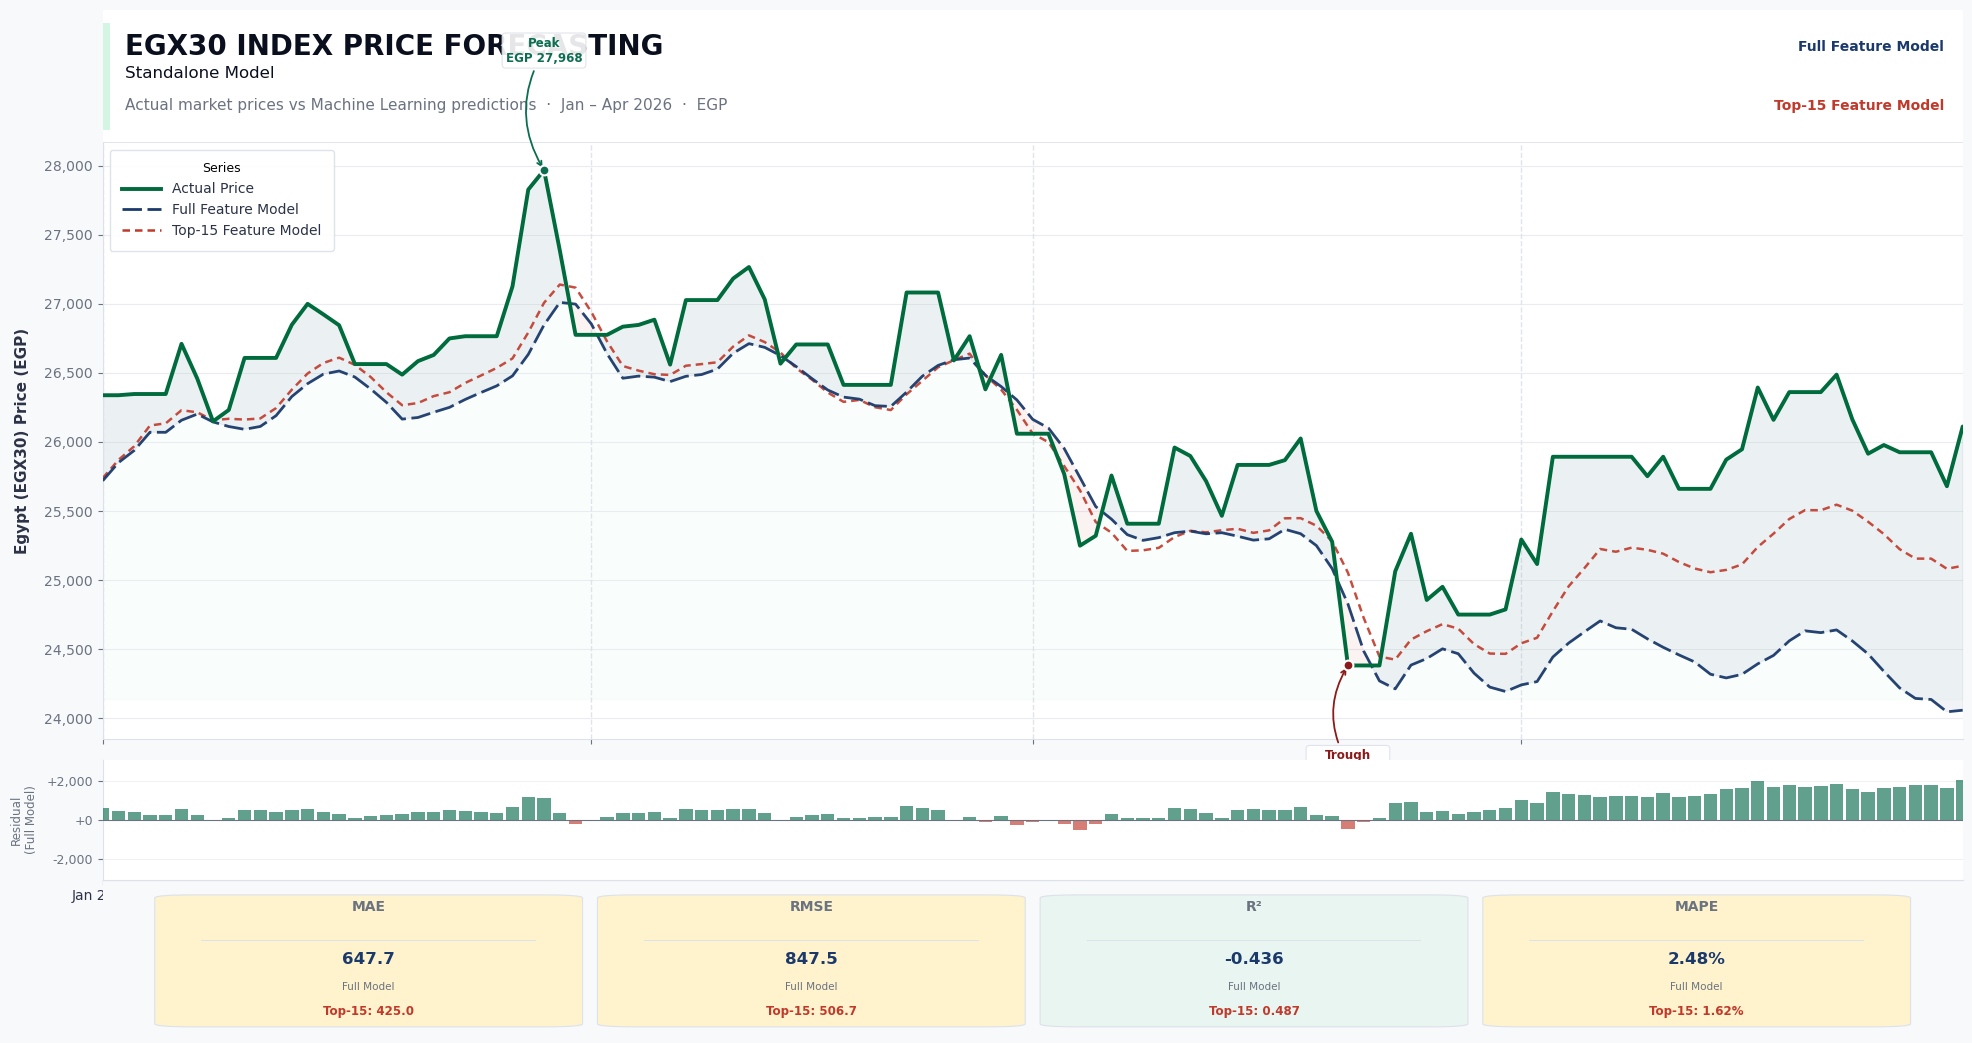

In [24]:
# ── KPI helper ────────────────────────────────────────────────────────────────
def kpis_Egypt_EGX30(a, p):
    mae  = np.mean(np.abs(a - p))
    rmse = np.sqrt(np.mean((a - p) ** 2))
    r2   = 1 - np.sum((a - p) ** 2) / np.sum((a - a.mean()) ** 2)
    mape = np.mean(np.abs((a - p) / a)) * 100
    return mae, rmse, r2, mape

plot_df_Egypt_EGX30   = test_Egypt_EGX30.sort_values('date').copy()
dates_Egypt_EGX30     = plot_df_Egypt_EGX30['date'].values
actual_Egypt_EGX30    = plot_df_Egypt_EGX30[target_col_Egypt_EGX30].values
full_pred_Egypt_EGX30 = plot_df_Egypt_EGX30['pred_price'].values
top_pred_Egypt_EGX30  = plot_df_Egypt_EGX30['pred_price_top'].values

mae_f_Egypt_EGX30, rmse_f_Egypt_EGX30, r2_f_Egypt_EGX30, mape_f_Egypt_EGX30 = kpis_Egypt_EGX30(actual_Egypt_EGX30, full_pred_Egypt_EGX30)
mae_t_Egypt_EGX30, rmse_t_Egypt_EGX30, r2_t_Egypt_EGX30, mape_t_Egypt_EGX30 = kpis_Egypt_EGX30(actual_Egypt_EGX30, top_pred_Egypt_EGX30)

# ── Palette ───────────────────────────────────────────────────────────────────
PAGE, WHITE, BORDER, GRID = '#F8F9FB', '#FFFFFF', '#DDE1E9', '#EAECF2'
MKT_DARK  = '#006B3C'
MKT_FILL  = '#D5F5E3'
NAVY      = '#1B3A6B'
CRIMSON   = '#C0392B'
TEXT_H, TEXT_B, TEXT_M = '#0A0F1E', '#2C3347', '#6B7280'
GREEN_KPI, GREEN_BG     = '#0B6E4F', '#E8F5F0'
RED_KPI                 = '#8B1A1A'
AMBER_KPI, AMBER_BG     = '#7A4F00', '#FEF3CD'

# ── Figure & layout ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 11), facecolor=PAGE)
outer = gridspec.GridSpec(3, 1, height_ratios=[0.13, 0.72, 0.15],
                          hspace=0, left=0.04, right=0.97, top=0.97, bottom=0.04)

# ── Header band ───────────────────────────────────────────────────────────────
ax_head = fig.add_subplot(outer[0])
ax_head.set_facecolor(WHITE)
ax_head.set_xlim(0, 1); ax_head.set_ylim(0, 1)
for sp in ax_head.spines.values(): sp.set_visible(False)
ax_head.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax_head.add_patch(mpatches.FancyBboxPatch((0, 0.1), 0.004, 0.8,
    boxstyle='square,pad=0', fc=MKT_FILL, ec='none',
    transform=ax_head.transAxes, clip_on=False))
ax_head.text(0.012, 0.72, 'EGX30 INDEX PRICE FORECASTING', transform=ax_head.transAxes,
             fontsize=20, fontweight='bold', color=TEXT_H, va='center')
ax_head.text(0.012, 0.52, 'Standalone Model', transform=ax_head.transAxes,
             fontsize=12, fontweight='normal', color=TEXT_H, va='center')
ax_head.text(0.012, 0.28,
    'Actual market prices vs Machine Learning predictions  ·  Jan – Apr 2026  ·  EGP',
    transform=ax_head.transAxes, fontsize=11, color=TEXT_M, va='center')
ax_head.text(0.99, 0.72, 'Full Feature Model', transform=ax_head.transAxes,
             fontsize=10, fontweight='bold', color=NAVY, ha='right', va='center')
ax_head.text(0.99, 0.28, f'Top-{top_k_Egypt_EGX30} Feature Model', transform=ax_head.transAxes,
             fontsize=10, fontweight='bold', color=CRIMSON, ha='right', va='center')
ax_head.axhline(0, color=BORDER, linewidth=1.2)

# ── Chart + residual ──────────────────────────────────────────────────────────
inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[1],
                                         height_ratios=[5, 1], hspace=0.06)
ax   = fig.add_subplot(inner[0])
ax_r = fig.add_subplot(inner[1], sharex=ax)

for a in [ax, ax_r]:
    a.set_facecolor(WHITE)
    a.tick_params(colors=TEXT_M, labelsize=10)
    for sp in a.spines.values(): sp.set_edgecolor(BORDER); sp.set_linewidth(0.8)
    a.spines['top'].set_visible(False); a.spines['right'].set_visible(False)

# fills
ax.fill_between(dates_Egypt_EGX30, actual_Egypt_EGX30, actual_Egypt_EGX30.min() - actual_Egypt_EGX30.min() * 0.01,
    color=MKT_FILL, alpha=0.12, zorder=1)
ax.fill_between(dates_Egypt_EGX30, actual_Egypt_EGX30, full_pred_Egypt_EGX30,
    where=(actual_Egypt_EGX30 >= full_pred_Egypt_EGX30), color=NAVY,    alpha=0.06, zorder=2, interpolate=True)
ax.fill_between(dates_Egypt_EGX30, actual_Egypt_EGX30, full_pred_Egypt_EGX30,
    where=(actual_Egypt_EGX30 < full_pred_Egypt_EGX30),  color=CRIMSON, alpha=0.06, zorder=2, interpolate=True)

# lines
ax.plot(dates_Egypt_EGX30, actual_Egypt_EGX30,    color=MKT_DARK, linewidth=2.8, zorder=6,
        solid_capstyle='round', label='Actual Price')
ax.plot(dates_Egypt_EGX30, full_pred_Egypt_EGX30, color=NAVY,     linewidth=2.0, linestyle=(0,(7,2)),
        zorder=5, alpha=0.95, label='Full Feature Model')
ax.plot(dates_Egypt_EGX30, top_pred_Egypt_EGX30,  color=CRIMSON,  linewidth=1.8, linestyle=(0,(3,2)),
        zorder=4, alpha=0.90, label=f'Top-{top_k_Egypt_EGX30} Feature Model')

# month dividers
for ms in pd.date_range(plot_df_Egypt_EGX30['date'].min(), plot_df_Egypt_EGX30['date'].max(), freq='MS'):
    ax.axvline(ms, color=BORDER, linewidth=1.0, linestyle='--', alpha=0.9, zorder=1)
ax.set_xlim(dates_Egypt_EGX30[0], dates_Egypt_EGX30[-1])

# peak & trough annotations
pidx_Egypt_EGX30 = np.argmax(actual_Egypt_EGX30)
pval_Egypt_EGX30 = actual_Egypt_EGX30[pidx_Egypt_EGX30]
pdate_Egypt_EGX30 = dates_Egypt_EGX30[pidx_Egypt_EGX30]
tidx_Egypt_EGX30 = np.argmin(actual_Egypt_EGX30)
tval_Egypt_EGX30 = actual_Egypt_EGX30[tidx_Egypt_EGX30]
tdate_Egypt_EGX30 = dates_Egypt_EGX30[tidx_Egypt_EGX30]
offset_Egypt_EGX30 = actual_Egypt_EGX30.mean() * 0.03
for x, y, lbl, col, ya, arc in [
    (pdate_Egypt_EGX30, pval_Egypt_EGX30, f'Peak\nEGP {pval_Egypt_EGX30:,.0f}',   GREEN_KPI, pval_Egypt_EGX30 + offset_Egypt_EGX30,   0.3),
    (tdate_Egypt_EGX30, tval_Egypt_EGX30, f'Trough\nEGP {tval_Egypt_EGX30:,.0f}', RED_KPI,   tval_Egypt_EGX30 - offset_Egypt_EGX30,  -0.3),
]:
    ax.annotate(lbl, xy=(x, y), xytext=(x, ya), color=col,
        fontsize=8.5, fontweight='bold', ha='center',
        arrowprops=dict(arrowstyle='->', color=col,
            connectionstyle=f'arc3,rad={arc}', lw=1.3),
        bbox=dict(boxstyle='round,pad=0.3', fc=WHITE, ec=BORDER, alpha=0.9, lw=0.8),
        zorder=10)
    ax.scatter([x], [y], color=col, s=50, zorder=11, edgecolors=WHITE, linewidths=1.5)

# grid & labels
ax.yaxis.grid(True, color=GRID, linewidth=0.8, zorder=0); ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_ylabel(f'Egypt (EGX30) Price (EGP)', color=TEXT_B, fontsize=11,
              fontweight='bold', labelpad=10)
ax.tick_params(axis='x', labelbottom=False)

ax.legend(handles=[
    Line2D([0], [0], color=MKT_DARK, linewidth=2.8,                      label='Actual Price'),
    Line2D([0], [0], color=NAVY,      linewidth=2.0, linestyle=(0,(7,2)), label='Full Feature Model'),
    Line2D([0], [0], color=CRIMSON,   linewidth=1.8, linestyle=(0,(3,2)), label=f'Top-{top_k_Egypt_EGX30} Feature Model'),
], loc='upper left', frameon=True, framealpha=0.95, facecolor=WHITE, edgecolor=BORDER,
   labelcolor=TEXT_B, fontsize=10, borderpad=0.9, handlelength=2.8,
   title='Series', title_fontsize=9)

# residual strip
res_Egypt_EGX30 = actual_Egypt_EGX30 - full_pred_Egypt_EGX30
ax_r.bar(dates_Egypt_EGX30, res_Egypt_EGX30,
         color=[GREEN_KPI if v >= 0 else CRIMSON for v in res_Egypt_EGX30],
         alpha=0.65, width=0.85, zorder=3)
ax_r.axhline(0, color=TEXT_M, linewidth=0.8, zorder=4)
ax_r.yaxis.grid(True, color=GRID, linewidth=0.5, zorder=0); ax_r.set_axisbelow(True)
ax_r.set_ylabel('Residual\n(Full Model)', color=TEXT_M, fontsize=8.5, labelpad=6)
ax_r.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+,.0f}'))
ax_r.tick_params(colors=TEXT_M, labelsize=9)
pad_Egypt_EGX30 = max(abs(res_Egypt_EGX30.min()), abs(res_Egypt_EGX30.max())) * 1.5
ax_r.set_ylim(-pad_Egypt_EGX30, pad_Egypt_EGX30)
ax_r.xaxis.set_major_locator(mdates.MonthLocator())
ax_r.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax_r.tick_params(axis='x', labelsize=10, colors=TEXT_B)

# ── KPI strip ─────────────────────────────────────────────────────────────────
ax_kpi = fig.add_subplot(outer[2])
ax_kpi.set_facecolor(PAGE); ax_kpi.set_xlim(0, 1); ax_kpi.set_ylim(0, 1)
for sp in ax_kpi.spines.values(): sp.set_visible(False)
ax_kpi.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax_kpi.axhline(1.0, color=BORDER, linewidth=1.0)

kpi_cards_Egypt_EGX30 = [
    ('MAE',  f'{mae_f_Egypt_EGX30:,.1f}',  f'{mae_t_Egypt_EGX30:,.1f}',  AMBER_KPI, AMBER_BG),
    ('RMSE', f'{rmse_f_Egypt_EGX30:,.1f}', f'{rmse_t_Egypt_EGX30:,.1f}', AMBER_KPI, AMBER_BG),
    ('R²',   f'{r2_f_Egypt_EGX30:.3f}',    f'{r2_t_Egypt_EGX30:.3f}',    GREEN_KPI, GREEN_BG),
    ('MAPE', f'{mape_f_Egypt_EGX30:.2f}%', f'{mape_t_Egypt_EGX30:.2f}%', AMBER_KPI, AMBER_BG),
]
card_w = 0.19
gap    = (1.0 - len(kpi_cards_Egypt_EGX30) * card_w) / (len(kpi_cards_Egypt_EGX30) + 1)
for i, (metric, vf, vt, tcol, bgcol) in enumerate(kpi_cards_Egypt_EGX30):
    x0 = gap + i * (card_w + gap); xc = x0 + card_w / 2
    ax_kpi.add_patch(mpatches.FancyBboxPatch((x0, 0.06), card_w, 0.82,
        boxstyle='round,pad=0.02', fc=bgcol, ec=BORDER, linewidth=0.8,
        transform=ax_kpi.transAxes, clip_on=False))
    ax_kpi.text(xc, 0.82, metric, transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=10, fontweight='bold', color=TEXT_M)
    ax_kpi.add_patch(mpatches.FancyBboxPatch((x0 + 0.005, 0.60), card_w - 0.01, 0.005,
        boxstyle='square,pad=0', fc=BORDER, ec='none',
        transform=ax_kpi.transAxes, clip_on=False))
    ax_kpi.text(xc, 0.48, vf, transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=12, fontweight='bold', color=NAVY)
    ax_kpi.text(xc, 0.30, 'Full Model', transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=7.5, color=TEXT_M)
    ax_kpi.text(xc, 0.14, f'Top-{top_k_Egypt_EGX30}: {vt}', transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=8.5, fontweight='bold', color=CRIMSON)

plt.savefig(ai_data_dir / 'visualizations'/'standalone_EGX30_price_prediction_model.png',
            dpi=300, bbox_inches='tight', facecolor=PAGE)
plt.show()

<h4 style="color: #CEDDF4;"> 3.20 Egypt (EGX30) Price Prediction (tomorrow)</h4>

In [25]:
latest_top_Egypt_EGX30 = X_test_top_Egypt_EGX30.iloc[-1:]

pred_return_tomorrow_Egypt_EGX30 = top_model_Egypt_EGX30.predict(latest_top_Egypt_EGX30)[0]

last_log_price_Egypt_EGX30 = np.log(train_Egypt_EGX30[target_col_Egypt_EGX30].iloc[-1])

pred_price_tomorrow_Egypt_EGX30 = np.exp(last_log_price_Egypt_EGX30 + pred_return_tomorrow_Egypt_EGX30)

print("Predicted Egypt (EGX30) Price Tomorrow:", pred_price_tomorrow_Egypt_EGX30)

Predicted Egypt (EGX30) Price Tomorrow: 25652.89470013759


<h4 style="color: #CEDDF4;">4. NASDAQ Price Prediction</h4>

<h4 style="color: #CEDDF4;"> 4.1 Setup</h4>

In [26]:
# define target variable
target_col_NASDAQ = 'nasdaq_price_usd'
# avoid modifying original dataset
df_NASDAQ = pd.read_csv(ai_data_dir / 'new_master_table.csv')

<h4 style="color: #CEDDF4;"> 4.2 Time preprocessing</h4>

In [27]:
df_NASDAQ['date'] = pd.to_datetime(df_NASDAQ['date'], dayfirst=False, format='mixed', errors='coerce')
df_NASDAQ = df_NASDAQ.sort_values('date')

<h4 style="color: #CEDDF4;"> 4.3 Remove leakage features</h4>

In [28]:
leakage_keywords_NASDAQ = [
    '_open_', '_high_', '_low_',     
    '_open',  '_high',  '_low',      
    'gpr_event',                     
    'ai_gpr_Unnamed',                
    'gold_price_oz_egp',             
    'cbe_inflations_headline_inflation_yy',  
    'cbe_inflations_core_inflation_yy',
    '_energy_',                      
    'egpusd_value',                  
    'dollar_historical_data_value',  
    'cpi_PCPIPCH',                   
]

df_NASDAQ = df_NASDAQ.drop(columns=[
    c for c in df_NASDAQ.columns
    if any(k in c for k in leakage_keywords_NASDAQ)
], errors='ignore')

# ── 2. drop all OTHER stock market price columns (cross-market leakage) ───────
other_stock_cols_NASDAQ = [
    'nasdaq_high_usd',
    'nasdaq_low_usd',
    'nasdaq_open_usd',
    'sp500_price_usd',
    'sp500_high_usd',
    'sp500_low_usd',
    'sp500_open_usd',
    'dowjones_price_usd',
    'dowjones_high_usd',
    'dowjones_low_usd',
    'dowjones_open_usd',
    'china_shanghai_price_usd',
    'china_shanghai_high_usd',
    'china_shanghai_low_usd',
    'china_shanghai_open_usd',
    'hongkong_hongkong_price_usd',
    'hongkong_hongkong_high_usd',
    'hongkong_hongkong_low_usd',
    'hongkong_hongkong_open_usd',
    'uk_london_price_usd',
    'uk_london_high_usd',
    'uk_london_low_usd',
    'uk_london_open_usd',
    'japan_tokyo_price_usd',
    'japan_tokyo_high_usd',
    'japan_tokyo_low_usd',
    'japan_tokyo_open_usd',
    'egx30_price_egp',
    'egx30_high_price_egp',
    'egx30_low_price_egp',
    'egx30_change_percent',
]

df_NASDAQ = df_NASDAQ.drop(columns=[
    c for c in other_stock_cols_NASDAQ if c in df_NASDAQ.columns
], errors='ignore')

<h4 style="color: #CEDDF4;"> 4.4 Macro feature engineering</h4>

In [29]:
df_NASDAQ['real_rate_us'] = df_NASDAQ['usd_fedfunds_value'] - df_NASDAQ['cpi_value']            # US real interest rate
df_NASDAQ['real_rate_eu'] = df_NASDAQ['euro_interest_value'] - df_NASDAQ['euro_inflation_value']  # EU real interest rate

df_NASDAQ['yield_spread_10_2'] = (                                                               # US yield curve spread
    df_NASDAQ['10y_treasury_historical_data_monthly_value'] -
    df_NASDAQ['2y_treasury_historical_data_monthly_value']
)
df_NASDAQ['yield_spread_10_1'] = (                                                               # short-end spread
    df_NASDAQ['10y_treasury_historical_data_monthly_value'] -
    df_NASDAQ['1y_treasury_historical_data_monthly_value']
)

df_NASDAQ['oil_x_dxy']  = df_NASDAQ['brent_oil_price_usd'] * df_NASDAQ['dollarindex_value']     # oil × dollar interaction
df_NASDAQ['vix_x_dxy']  = df_NASDAQ['vix_price_usd']       * df_NASDAQ['dollarindex_value']     # volatility × dollar interaction
df_NASDAQ['gold_x_dxy'] = df_NASDAQ['gold_price_usd']      * df_NASDAQ['dollarindex_value']     # gold × dollar interaction

df_NASDAQ['vix_mom']  = df_NASDAQ['vix_price_usd'].pct_change()        # VIX momentum (risk-on/off)
df_NASDAQ['oil_mom']  = df_NASDAQ['brent_oil_price_usd'].pct_change()  # oil momentum
df_NASDAQ['gold_mom'] = df_NASDAQ['gold_price_usd'].pct_change()       # gold momentum

<h4 style="color: #CEDDF4;"> 4.5 Feature engineering</h4>

In [30]:
df_NASDAQ['log_price'] = np.log(df_NASDAQ[target_col_NASDAQ])  # log transformation for stability
df_NASDAQ['return']    = df_NASDAQ['log_price'].diff()            # daily log-return

# ── simple moving averages & distance from SMA (trend-following signals) ──────
for w in [5, 10, 20, 50]:
    df_NASDAQ[f'sma_{w}']          = df_NASDAQ[target_col_NASDAQ].rolling(w).mean().shift(1)
    df_NASDAQ[f'price_vs_sma_{w}'] = (df_NASDAQ[target_col_NASDAQ] / df_NASDAQ[f'sma_{w}'] - 1).shift(1)

# ── RSI-14 (momentum oscillator) ──────────────────────────────────────────────
_delta_NASDAQ    = df_NASDAQ['return'].clip(lower=0)
_loss_NASDAQ     = (-df_NASDAQ['return']).clip(lower=0)
_avg_gain_NASDAQ = _delta_NASDAQ.rolling(14).mean()
_avg_loss_NASDAQ = _loss_NASDAQ.rolling(14).mean().replace(0, 1e-9)
df_NASDAQ['rsi_14'] = (100 - 100 / (1 + _avg_gain_NASDAQ / _avg_loss_NASDAQ)).shift(1)

# ── Bollinger Band width (volatility regime signal) ───────────────────────────
_bb_mid_NASDAQ       = df_NASDAQ[target_col_NASDAQ].rolling(20).mean()
_bb_std_NASDAQ       = df_NASDAQ[target_col_NASDAQ].rolling(20).std()
df_NASDAQ['bb_width']= (4 * _bb_std_NASDAQ / _bb_mid_NASDAQ).shift(1)  # normalised bandwidth

# ── calendar features ─────────────────────────────────────────────────────────
df_NASDAQ['day_of_week']    = df_NASDAQ['date'].dt.dayofweek    # Mon=0 … Fri=4
df_NASDAQ['month']          = df_NASDAQ['date'].dt.month
df_NASDAQ['quarter']        = df_NASDAQ['date'].dt.quarter
df_NASDAQ['is_month_end']   = df_NASDAQ['date'].dt.is_month_end.astype(int)
df_NASDAQ['is_quarter_end'] = df_NASDAQ['date'].dt.is_quarter_end.astype(int)

# ── target: next-day smoothed return (identical to gold/oil model) ────────────
df_NASDAQ['target'] = df_NASDAQ['return'].rolling(5).mean().shift(-1)  # future smoothed return target
df_NASDAQ['target'] = df_NASDAQ['target'].clip(-0.03, 0.03)            # limit extreme values

<h4 style="color: #CEDDF4;"> 4.6 Lag features</h4>

In [31]:
for lag in [1, 2, 3, 5, 10, 20]:
    df_NASDAQ[f'return_lag_{lag}'] = df_NASDAQ['return'].shift(lag)  # past returns

df_NASDAQ['log_price_lag1'] = df_NASDAQ['log_price'].shift(1)  # previous price level

# ── lagged macro signals (prevent same-day leakage) ──────────────────────────
df_NASDAQ['vix_lag1']      = df_NASDAQ['vix_price_usd'].shift(1)   # yesterday's fear index
df_NASDAQ['gold_lag1']     = df_NASDAQ['gold_price_usd'].shift(1)  # yesterday's gold price
df_NASDAQ['oil_lag1']      = df_NASDAQ['brent_oil_price_usd'].shift(1)  # yesterday's oil price
df_NASDAQ['dxy_lag1']      = df_NASDAQ['dollarindex_value'].shift(1)    # yesterday's dollar index

C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\2138153003.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_NASDAQ['dxy_lag1']      = df_NASDAQ['dollarindex_value'].shift(1)    # yesterday's dollar index


<h4 style="color: #CEDDF4;"> 4.7 Volatility and momentum</h4>

In [32]:
df_NASDAQ['vol_7']         = df_NASDAQ['return'].rolling(7).std().shift(1)    # short-term realised volatility
df_NASDAQ['vol_20']        = df_NASDAQ['return'].rolling(20).std().shift(1)   # medium-term realised volatility
df_NASDAQ['vol_ratio']     = df_NASDAQ['vol_7'] / (df_NASDAQ['vol_20'] + 1e-9)  # vol regime: >1 = expanding

df_NASDAQ['mom_7']         = df_NASDAQ['return'].rolling(7).mean().shift(1)   # short-term momentum
df_NASDAQ['mom_20']        = df_NASDAQ['return'].rolling(20).mean().shift(1)  # medium-term momentum
df_NASDAQ['mom_crossover'] = df_NASDAQ['mom_7'] - df_NASDAQ['mom_20']           # momentum crossover signal

df_NASDAQ['price_trend_7'] = df_NASDAQ[target_col_NASDAQ].rolling(7).mean().shift(1)   # 7-day price trend
df_NASDAQ['price_trend_20']= df_NASDAQ[target_col_NASDAQ].rolling(20).mean().shift(1)  # 20-day price trend

C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\661142781.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_NASDAQ['vol_7']         = df_NASDAQ['return'].rolling(7).std().shift(1)    # short-term realised volatility
C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\661142781.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_NASDAQ['vol_20']        = df_NASDAQ['return'].rolling(20).std().shift(1)   # medium-term realised volatility
C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\661142781.py:3: PerformanceWarning: Data

<h4 style="color: #CEDDF4;"> 4.8 Data cleaning</h4>

In [33]:
df_NASDAQ = df_NASDAQ.dropna()  # remove missing values

<h4 style="color: #CEDDF4;"> 4.9 Feature selection</h4>

In [34]:
features_NASDAQ = [c for c in df_NASDAQ.columns if c not in ['date', target_col_NASDAQ, 'target']]  # model inputs

<h4 style="color: #CEDDF4;"> 4.10 Train/test split</h4>

In [35]:
train_NASDAQ = df_NASDAQ[df_NASDAQ['date'] <= '2025-12-31']                                            # training period
test_NASDAQ  = df_NASDAQ[(df_NASDAQ['date'] > '2025-12-31') & (df_NASDAQ['date'] <= '2026-04-30')]  # testing period

X_train_NASDAQ = train_NASDAQ[features_NASDAQ]
y_train_NASDAQ = train_NASDAQ['target']

X_test_NASDAQ  = test_NASDAQ[features_NASDAQ]
y_test_NASDAQ  = test_NASDAQ['target']

<h4 style="color: #CEDDF4;"> 4.11 time series Cross-validation</h4>

In [36]:
tscv_NASDAQ = TimeSeriesSplit(n_splits=5)

for i, (tr, val) in enumerate(tscv_NASDAQ.split(X_train_NASDAQ)):

    model_cv_NASDAQ = lgb.LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.01,
        num_leaves=64,
        max_depth=6,
        verbose=-1
    )

    model_cv_NASDAQ.fit(X_train_NASDAQ.iloc[tr], y_train_NASDAQ.iloc[tr])  # train fold model

    pred_cv_NASDAQ = model_cv_NASDAQ.predict(X_train_NASDAQ.iloc[val])  # validation prediction

    print("Fold", i+1)
    print("MAE:", mean_absolute_error(y_train_NASDAQ.iloc[val], pred_cv_NASDAQ))  # error
    print("DIR:", np.mean(np.sign(y_train_NASDAQ.iloc[val]) == np.sign(pred_cv_NASDAQ)))  # direction accuracy

Fold 1
MAE: 0.0018047003784037723
DIR: 0.835
Fold 2
MAE: 0.0024314566157903022
DIR: 0.8316666666666667
Fold 3
MAE: 0.0023570123601496995
DIR: 0.8433333333333334
Fold 4
MAE: 0.0022727363410152165
DIR: 0.7733333333333333
Fold 5
MAE: 0.001842537366234353
DIR: 0.8316666666666667


<h4 style="color: #CEDDF4;"> 4.12 Full Model training</h4>

In [37]:
model_NASDAQ = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

model_NASDAQ.fit(X_train_NASDAQ, y_train_NASDAQ)

,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.01
,n_estimators,3000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


<h4 style="color: #CEDDF4;"> 4.13 Feature selection</h4>

In [38]:
selector_NASDAQ = SelectFromModel(model_NASDAQ, threshold='median', prefit=True)

X_train_sel_NASDAQ = selector_NASDAQ.transform(X_train_NASDAQ)
X_test_sel_NASDAQ  = selector_NASDAQ.transform(X_test_NASDAQ)

model_NASDAQ.fit(X_train_sel_NASDAQ, y_train_NASDAQ)

with open(ai_data_dir/'models'/"standalone_NASDAQ_full_features_model.pkl", "wb") as f:
    pickle.dump(model_NASDAQ, f)

c:\Users\HMSY\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
c:\Users\HMSY\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


<h4 style="color: #CEDDF4;"> 4.14 Prediction (full model)</h4>

In [39]:
pred_returns_NASDAQ = model_NASDAQ.predict(X_test_sel_NASDAQ)

c:\Users\HMSY\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


<h4 style="color: #CEDDF4;"> 4.15 Price Prediction (full model)</h4>

In [40]:
start_price_NASDAQ = train_NASDAQ[target_col_NASDAQ].iloc[-1]

prices_NASDAQ = [start_price_NASDAQ]

for r in pred_returns_NASDAQ:
    prices_NASDAQ.append(prices_NASDAQ[-1] * np.exp(r))

prices_NASDAQ = prices_NASDAQ[1:]

test_NASDAQ = test_NASDAQ.copy()
test_NASDAQ['pred_price'] = prices_NASDAQ

<h4 style="color: #CEDDF4;"> 4.16 Evaluation (full model)</h4>

In [41]:
mae_NASDAQ       = mean_absolute_error(test_NASDAQ[target_col_NASDAQ], test_NASDAQ['pred_price'])
direction_NASDAQ = np.mean(np.sign(test_NASDAQ['target']) == np.sign(pred_returns_NASDAQ))

print("Full Model MAE:", mae_NASDAQ)
print("Full Model Direction:", direction_NASDAQ)

Full Model MAE: 1874.6049302830354
Full Model Direction: 0.773109243697479


<h4 style="color: #CEDDF4;"> 4.17 Top Features Extraction</h4>

In [42]:
importance_model_NASDAQ = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

importance_model_NASDAQ.fit(X_train_NASDAQ, y_train_NASDAQ)

#model saving into pickle file

#with open(ai_data_dir/"NASDAQ_top_features_model.pkl", "wb") as f:
    #pickle.dump(importance_model_NASDAQ, f)

importance_NASDAQ = pd.Series(
    importance_model_NASDAQ.feature_importances_,
    index=X_train_NASDAQ.columns
).sort_values(ascending=False)

<h4 style="color: #CEDDF4;"> 4.18 Top Features selection</h4>

In [43]:
top_k_NASDAQ        = 15
top_features_NASDAQ = importance_NASDAQ.head(top_k_NASDAQ).index.tolist()

X_train_top_NASDAQ = X_train_NASDAQ[top_features_NASDAQ]
X_test_top_NASDAQ  = X_test_NASDAQ[top_features_NASDAQ]

<h4 style="color: #CEDDF4;"> 4.19 Top model training</h4>

In [44]:
top_model_NASDAQ = lgb.LGBMRegressor(
    objective='regression',
    boosting_type='gbdt',

    n_estimators=3000,
    learning_rate=0.02,

    num_leaves=128,
    max_depth=10,

    min_child_samples=10,
    min_child_weight=1e-3,

    subsample=0.9,
    subsample_freq=1,

    colsample_bytree=0.9,

    reg_alpha=0.1,
    reg_lambda=0.3,

    random_state=42,
    verbose=-1
)

top_model_NASDAQ.fit(X_train_top_NASDAQ, y_train_NASDAQ)

#model saving into pickle file

with open(ai_data_dir/'models'/"standalone_NASDAQ_top_features_model.pkl", "wb") as f:
    pickle.dump(top_model_NASDAQ, f)

pred_top_NASDAQ = top_model_NASDAQ.predict(X_test_top_NASDAQ)

<h4 style="color: #CEDDF4;"> 4.20 Price Prediction (top model)</h4>

In [45]:
prices_top_NASDAQ = [start_price_NASDAQ]

for r in pred_top_NASDAQ:
    prices_top_NASDAQ.append(prices_top_NASDAQ[-1] * np.exp(r))

prices_top_NASDAQ = prices_top_NASDAQ[1:]

test_NASDAQ['pred_price_top'] = prices_top_NASDAQ

<h4 style="color: #CEDDF4;"> 4.21 Evaluation (top model)</h4>

In [46]:
mae_top_NASDAQ       = mean_absolute_error(test_NASDAQ[target_col_NASDAQ], test_NASDAQ['pred_price_top'])
direction_top_NASDAQ = np.mean(np.sign(test_NASDAQ['target']) == np.sign(pred_top_NASDAQ))

print("Top Features Model MAE:", mae_top_NASDAQ)
print("Top Features Model Direction:", direction_top_NASDAQ)

Top Features Model MAE: 314.6023515266389
Top Features Model Direction: 0.7899159663865546


<h4 style="color: #CEDDF4;"> 4.22 Model Comparison Using Visualizations</h4>

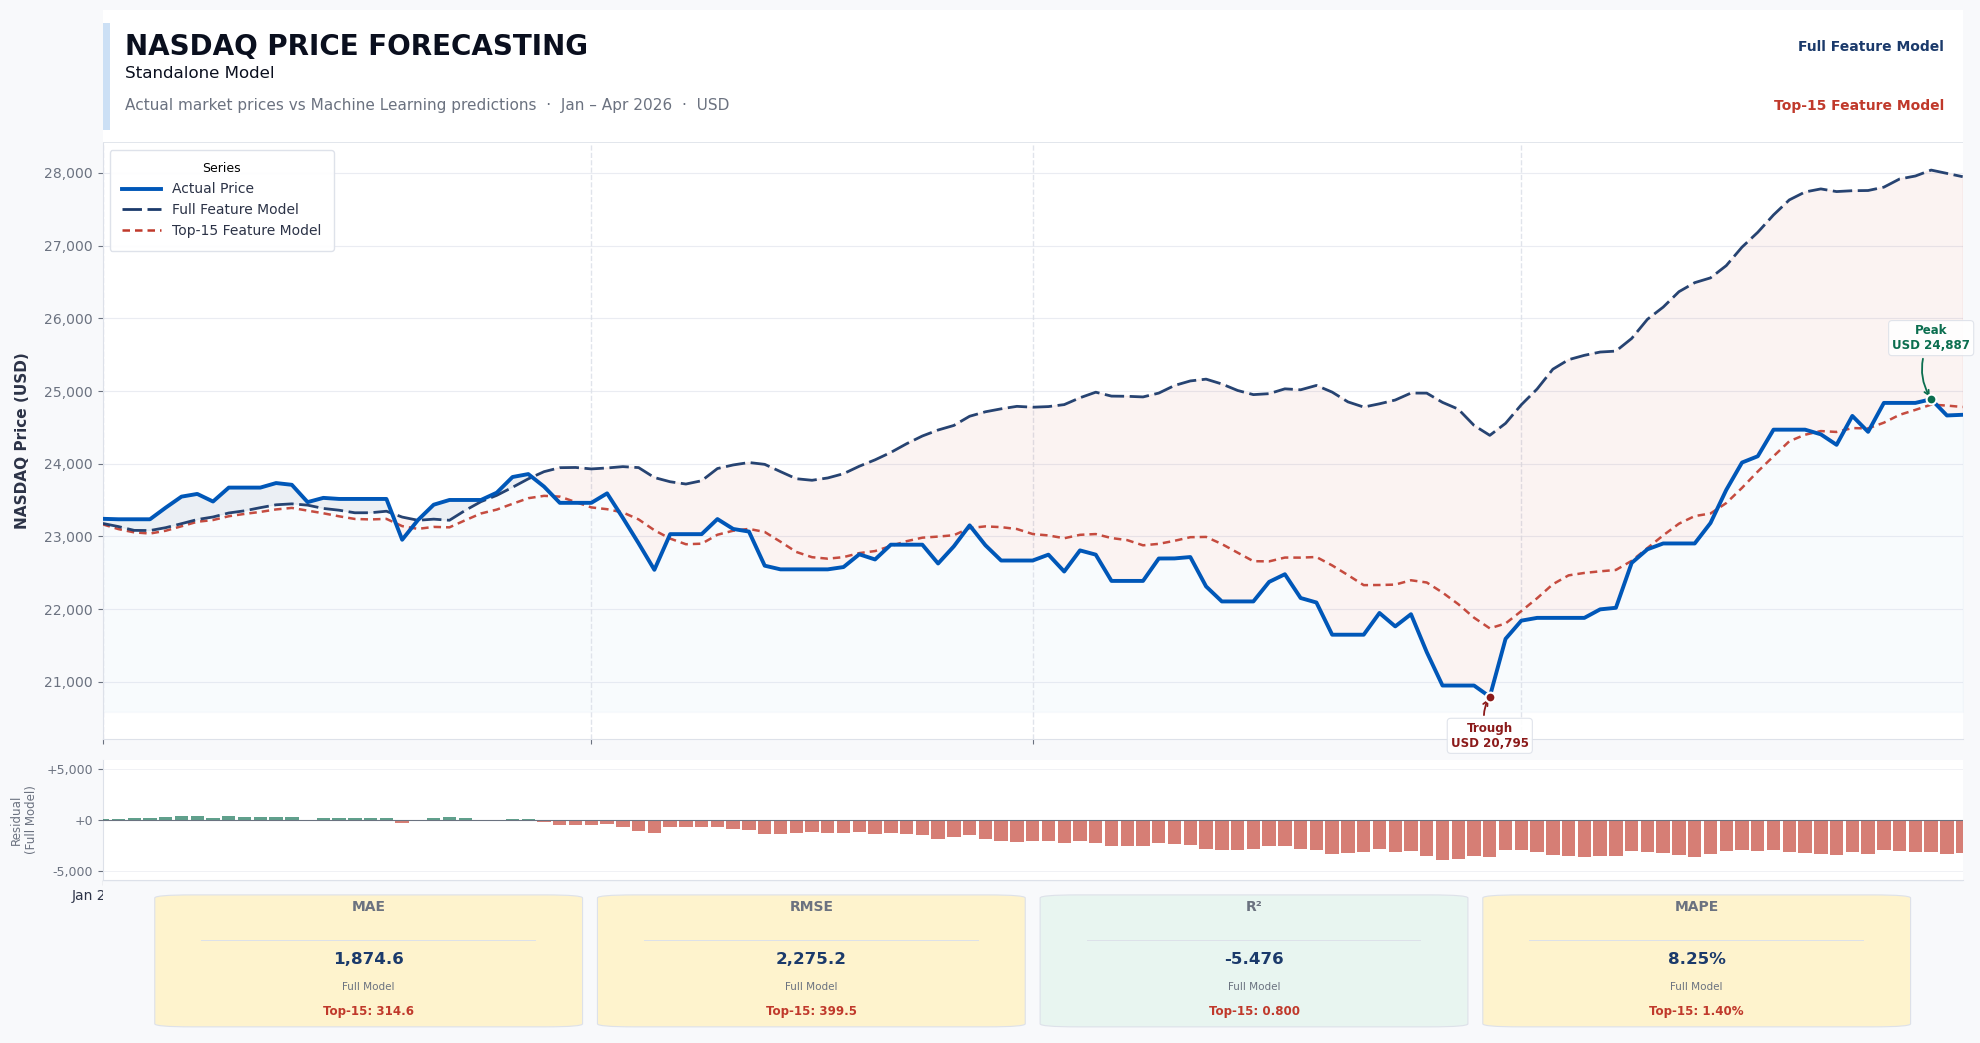

In [47]:
import matplotlib.ticker as mticker

# ── KPI helper ────────────────────────────────────────────────────────────────
def kpis_NASDAQ(a, p):
    mae  = np.mean(np.abs(a - p))
    rmse = np.sqrt(np.mean((a - p) ** 2))
    r2   = 1 - np.sum((a - p) ** 2) / np.sum((a - a.mean()) ** 2)
    mape = np.mean(np.abs((a - p) / a)) * 100
    return mae, rmse, r2, mape

plot_df_NASDAQ   = test_NASDAQ.sort_values('date').copy()
dates_NASDAQ     = plot_df_NASDAQ['date'].values
actual_NASDAQ    = plot_df_NASDAQ[target_col_NASDAQ].values
full_pred_NASDAQ = plot_df_NASDAQ['pred_price'].values
top_pred_NASDAQ  = plot_df_NASDAQ['pred_price_top'].values

mae_f_NASDAQ, rmse_f_NASDAQ, r2_f_NASDAQ, mape_f_NASDAQ = kpis_NASDAQ(actual_NASDAQ, full_pred_NASDAQ)
mae_t_NASDAQ, rmse_t_NASDAQ, r2_t_NASDAQ, mape_t_NASDAQ = kpis_NASDAQ(actual_NASDAQ, top_pred_NASDAQ)

# ── Palette ───────────────────────────────────────────────────────────────────
PAGE, WHITE, BORDER, GRID = '#F8F9FB', '#FFFFFF', '#DDE1E9', '#EAECF2'
MKT_DARK  = '#0057B8'
MKT_FILL  = '#CCE0F5'
NAVY      = '#1B3A6B'
CRIMSON   = '#C0392B'
TEXT_H, TEXT_B, TEXT_M = '#0A0F1E', '#2C3347', '#6B7280'
GREEN_KPI, GREEN_BG     = '#0B6E4F', '#E8F5F0'
RED_KPI                 = '#8B1A1A'
AMBER_KPI, AMBER_BG     = '#7A4F00', '#FEF3CD'

# ── Figure & layout ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 11), facecolor=PAGE)
outer = gridspec.GridSpec(3, 1, height_ratios=[0.13, 0.72, 0.15],
                          hspace=0, left=0.04, right=0.97, top=0.97, bottom=0.04)

# ── Header band ───────────────────────────────────────────────────────────────
ax_head = fig.add_subplot(outer[0])
ax_head.set_facecolor(WHITE)
ax_head.set_xlim(0, 1); ax_head.set_ylim(0, 1)
for sp in ax_head.spines.values(): sp.set_visible(False)
ax_head.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax_head.add_patch(mpatches.FancyBboxPatch((0, 0.1), 0.004, 0.8,
    boxstyle='square,pad=0', fc=MKT_FILL, ec='none',
    transform=ax_head.transAxes, clip_on=False))
ax_head.text(0.012, 0.72, 'NASDAQ PRICE FORECASTING', transform=ax_head.transAxes,
             fontsize=20, fontweight='bold', color=TEXT_H, va='center')
ax_head.text(0.012, 0.52, 'Standalone Model', transform=ax_head.transAxes,
             fontsize=12, fontweight='normal', color=TEXT_H, va='center')
ax_head.text(0.012, 0.28,
    'Actual market prices vs Machine Learning predictions  ·  Jan – Apr 2026  ·  USD',
    transform=ax_head.transAxes, fontsize=11, color=TEXT_M, va='center')
ax_head.text(0.99, 0.72, 'Full Feature Model', transform=ax_head.transAxes,
             fontsize=10, fontweight='bold', color=NAVY, ha='right', va='center')
ax_head.text(0.99, 0.28, f'Top-{top_k_NASDAQ} Feature Model', transform=ax_head.transAxes,
             fontsize=10, fontweight='bold', color=CRIMSON, ha='right', va='center')
ax_head.axhline(0, color=BORDER, linewidth=1.2)

# ── Chart + residual ──────────────────────────────────────────────────────────
inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[1],
                                         height_ratios=[5, 1], hspace=0.06)
ax   = fig.add_subplot(inner[0])
ax_r = fig.add_subplot(inner[1], sharex=ax)

for a in [ax, ax_r]:
    a.set_facecolor(WHITE)
    a.tick_params(colors=TEXT_M, labelsize=10)
    for sp in a.spines.values(): sp.set_edgecolor(BORDER); sp.set_linewidth(0.8)
    a.spines['top'].set_visible(False); a.spines['right'].set_visible(False)

# fills
ax.fill_between(dates_NASDAQ, actual_NASDAQ, actual_NASDAQ.min() - actual_NASDAQ.min() * 0.01,
    color=MKT_FILL, alpha=0.12, zorder=1)
ax.fill_between(dates_NASDAQ, actual_NASDAQ, full_pred_NASDAQ,
    where=(actual_NASDAQ >= full_pred_NASDAQ), color=NAVY,    alpha=0.06, zorder=2, interpolate=True)
ax.fill_between(dates_NASDAQ, actual_NASDAQ, full_pred_NASDAQ,
    where=(actual_NASDAQ < full_pred_NASDAQ),  color=CRIMSON, alpha=0.06, zorder=2, interpolate=True)

# lines
ax.plot(dates_NASDAQ, actual_NASDAQ,    color=MKT_DARK, linewidth=2.8, zorder=6,
        solid_capstyle='round', label='Actual Price')
ax.plot(dates_NASDAQ, full_pred_NASDAQ, color=NAVY,     linewidth=2.0, linestyle=(0,(7,2)),
        zorder=5, alpha=0.95, label='Full Feature Model')
ax.plot(dates_NASDAQ, top_pred_NASDAQ,  color=CRIMSON,  linewidth=1.8, linestyle=(0,(3,2)),
        zorder=4, alpha=0.90, label=f'Top-{top_k_NASDAQ} Feature Model')

# month dividers
for ms in pd.date_range(plot_df_NASDAQ['date'].min(), plot_df_NASDAQ['date'].max(), freq='MS'):
    ax.axvline(ms, color=BORDER, linewidth=1.0, linestyle='--', alpha=0.9, zorder=1)
ax.set_xlim(dates_NASDAQ[0], dates_NASDAQ[-1])

# peak & trough annotations
pidx_NASDAQ = np.argmax(actual_NASDAQ)
pval_NASDAQ = actual_NASDAQ[pidx_NASDAQ]
pdate_NASDAQ = dates_NASDAQ[pidx_NASDAQ]
tidx_NASDAQ = np.argmin(actual_NASDAQ)
tval_NASDAQ = actual_NASDAQ[tidx_NASDAQ]
tdate_NASDAQ = dates_NASDAQ[tidx_NASDAQ]
offset_NASDAQ = actual_NASDAQ.mean() * 0.03
for x, y, lbl, col, ya, arc in [
    (pdate_NASDAQ, pval_NASDAQ, f'Peak\nUSD {pval_NASDAQ:,.0f}',   GREEN_KPI, pval_NASDAQ + offset_NASDAQ,   0.3),
    (tdate_NASDAQ, tval_NASDAQ, f'Trough\nUSD {tval_NASDAQ:,.0f}', RED_KPI,   tval_NASDAQ - offset_NASDAQ,  -0.3),
]:
    ax.annotate(lbl, xy=(x, y), xytext=(x, ya), color=col,
        fontsize=8.5, fontweight='bold', ha='center',
        arrowprops=dict(arrowstyle='->', color=col,
            connectionstyle=f'arc3,rad={arc}', lw=1.3),
        bbox=dict(boxstyle='round,pad=0.3', fc=WHITE, ec=BORDER, alpha=0.9, lw=0.8),
        zorder=10)
    ax.scatter([x], [y], color=col, s=50, zorder=11, edgecolors=WHITE, linewidths=1.5)

# grid & labels
ax.yaxis.grid(True, color=GRID, linewidth=0.8, zorder=0); ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_ylabel(f'NASDAQ Price (USD)', color=TEXT_B, fontsize=11,
              fontweight='bold', labelpad=10)
ax.tick_params(axis='x', labelbottom=False)

ax.legend(handles=[
    Line2D([0], [0], color=MKT_DARK, linewidth=2.8,                      label='Actual Price'),
    Line2D([0], [0], color=NAVY,      linewidth=2.0, linestyle=(0,(7,2)), label='Full Feature Model'),
    Line2D([0], [0], color=CRIMSON,   linewidth=1.8, linestyle=(0,(3,2)), label=f'Top-{top_k_NASDAQ} Feature Model'),
], loc='upper left', frameon=True, framealpha=0.95, facecolor=WHITE, edgecolor=BORDER,
   labelcolor=TEXT_B, fontsize=10, borderpad=0.9, handlelength=2.8,
   title='Series', title_fontsize=9)

# residual strip
res_NASDAQ = actual_NASDAQ - full_pred_NASDAQ
ax_r.bar(dates_NASDAQ, res_NASDAQ,
         color=[GREEN_KPI if v >= 0 else CRIMSON for v in res_NASDAQ],
         alpha=0.65, width=0.85, zorder=3)
ax_r.axhline(0, color=TEXT_M, linewidth=0.8, zorder=4)
ax_r.yaxis.grid(True, color=GRID, linewidth=0.5, zorder=0); ax_r.set_axisbelow(True)
ax_r.set_ylabel('Residual\n(Full Model)', color=TEXT_M, fontsize=8.5, labelpad=6)
ax_r.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+,.0f}'))
ax_r.tick_params(colors=TEXT_M, labelsize=9)
pad_NASDAQ = max(abs(res_NASDAQ.min()), abs(res_NASDAQ.max())) * 1.5
ax_r.set_ylim(-pad_NASDAQ, pad_NASDAQ)
ax_r.xaxis.set_major_locator(mdates.MonthLocator())
ax_r.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax_r.tick_params(axis='x', labelsize=10, colors=TEXT_B)

# ── KPI strip ─────────────────────────────────────────────────────────────────
ax_kpi = fig.add_subplot(outer[2])
ax_kpi.set_facecolor(PAGE); ax_kpi.set_xlim(0, 1); ax_kpi.set_ylim(0, 1)
for sp in ax_kpi.spines.values(): sp.set_visible(False)
ax_kpi.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax_kpi.axhline(1.0, color=BORDER, linewidth=1.0)

kpi_cards_NASDAQ = [
    ('MAE',  f'{mae_f_NASDAQ:,.1f}',  f'{mae_t_NASDAQ:,.1f}',  AMBER_KPI, AMBER_BG),
    ('RMSE', f'{rmse_f_NASDAQ:,.1f}', f'{rmse_t_NASDAQ:,.1f}', AMBER_KPI, AMBER_BG),
    ('R²',   f'{r2_f_NASDAQ:.3f}',    f'{r2_t_NASDAQ:.3f}',    GREEN_KPI, GREEN_BG),
    ('MAPE', f'{mape_f_NASDAQ:.2f}%', f'{mape_t_NASDAQ:.2f}%', AMBER_KPI, AMBER_BG),
]
card_w = 0.19
gap    = (1.0 - len(kpi_cards_NASDAQ) * card_w) / (len(kpi_cards_NASDAQ) + 1)
for i, (metric, vf, vt, tcol, bgcol) in enumerate(kpi_cards_NASDAQ):
    x0 = gap + i * (card_w + gap); xc = x0 + card_w / 2
    ax_kpi.add_patch(mpatches.FancyBboxPatch((x0, 0.06), card_w, 0.82,
        boxstyle='round,pad=0.02', fc=bgcol, ec=BORDER, linewidth=0.8,
        transform=ax_kpi.transAxes, clip_on=False))
    ax_kpi.text(xc, 0.82, metric, transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=10, fontweight='bold', color=TEXT_M)
    ax_kpi.add_patch(mpatches.FancyBboxPatch((x0 + 0.005, 0.60), card_w - 0.01, 0.005,
        boxstyle='square,pad=0', fc=BORDER, ec='none',
        transform=ax_kpi.transAxes, clip_on=False))
    ax_kpi.text(xc, 0.48, vf, transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=12, fontweight='bold', color=NAVY)
    ax_kpi.text(xc, 0.30, 'Full Model', transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=7.5, color=TEXT_M)
    ax_kpi.text(xc, 0.14, f'Top-{top_k_NASDAQ}: {vt}', transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=8.5, fontweight='bold', color=CRIMSON)

plt.savefig(ai_data_dir / 'visualizations'/'standalone_NASDAQ_price_prediction_model.png',
            dpi=300, bbox_inches='tight', facecolor=PAGE)
plt.show()

<h4 style="color: #CEDDF4;"> 4.23 NASDAQ Price Prediction (tomorrow)</h4>

In [48]:
latest_top_NASDAQ = X_test_top_NASDAQ.iloc[-1:]

pred_return_tomorrow_NASDAQ = top_model_NASDAQ.predict(latest_top_NASDAQ)[0]

last_log_price_NASDAQ = np.log(train_NASDAQ[target_col_NASDAQ].iloc[-1])

pred_price_tomorrow_NASDAQ = np.exp(last_log_price_NASDAQ + pred_return_tomorrow_NASDAQ)

print("Predicted NASDAQ Price Tomorrow:", pred_price_tomorrow_NASDAQ)

Predicted NASDAQ Price Tomorrow: 23224.049556039798


<h4 style="color: #CEDDF4;">5. S&P 500 Price Prediction</h4>

<h4 style="color: #CEDDF4;"> 5.1 Setup</h4>

In [49]:
# define target variable
target_col_SandP_500 = 'sp500_price_usd'
# avoid modifying original dataset
df_SandP_500 = pd.read_csv(ai_data_dir / 'new_master_table.csv')

<h4 style="color: #CEDDF4;"> 5.2 Time preprocessing</h4>

In [50]:
df_SandP_500['date'] = pd.to_datetime(df_SandP_500['date'], dayfirst=False, format='mixed', errors='coerce')
df_SandP_500 = df_SandP_500.sort_values('date')

<h4 style="color: #CEDDF4;"> 5.3 Remove leakage features</h4>

In [51]:
# ── 1. always-drop keywords (leakage, noise, duplicates) ────────────────────
leakage_keywords_SandP_500 = [
    '_open_', '_high_', '_low_',     # intraday OHLC leakage on all assets
    '_open',  '_high',  '_low',      # suffix variants
    'gpr_event',                     # forward-looking GPR event flag
    'ai_gpr_Unnamed',                # index artefact
    'gold_price_oz_egp',             # EGP-denominated gold (derived, leaks FX)
    'cbe_inflations_headline_inflation_yy',  # monthly fill creates leakage
    'cbe_inflations_core_inflation_yy',
    '_energy_',                      # all country-level energy mix columns
    'egpusd_value',                  # duplicated by FX cols
    'dollar_historical_data_value',  # duplicated by dollarindex_value
    'cpi_PCPIPCH',                   # duplicate CPI series
]

df_SandP_500 = df_SandP_500.drop(columns=[
    c for c in df_SandP_500.columns
    if any(k in c for k in leakage_keywords_SandP_500)
], errors='ignore')

# ── 2. drop all OTHER stock market price columns (cross-market leakage) ───────
other_stock_cols_SandP_500 = [
    'nasdaq_price_usd',
    'nasdaq_high_usd',
    'nasdaq_low_usd',
    'nasdaq_open_usd',
    'sp500_high_usd',
    'sp500_low_usd',
    'sp500_open_usd',
    'dowjones_price_usd',
    'dowjones_high_usd',
    'dowjones_low_usd',
    'dowjones_open_usd',
    'china_shanghai_price_usd',
    'china_shanghai_high_usd',
    'china_shanghai_low_usd',
    'china_shanghai_open_usd',
    'hongkong_hongkong_price_usd',
    'hongkong_hongkong_high_usd',
    'hongkong_hongkong_low_usd',
    'hongkong_hongkong_open_usd',
    'uk_london_price_usd',
    'uk_london_high_usd',
    'uk_london_low_usd',
    'uk_london_open_usd',
    'japan_tokyo_price_usd',
    'japan_tokyo_high_usd',
    'japan_tokyo_low_usd',
    'japan_tokyo_open_usd',
    'egx30_price_egp',
    'egx30_high_price_egp',
    'egx30_low_price_egp',
    'egx30_change_percent',
]

df_SandP_500 = df_SandP_500.drop(columns=[
    c for c in other_stock_cols_SandP_500 if c in df_SandP_500.columns
], errors='ignore')

<h4 style="color: #CEDDF4;"> 5.4 Macro feature engineering</h4>

In [52]:
df_SandP_500['real_rate_us'] = df_SandP_500['usd_fedfunds_value'] - df_SandP_500['cpi_value']            # US real interest rate
df_SandP_500['real_rate_eu'] = df_SandP_500['euro_interest_value'] - df_SandP_500['euro_inflation_value']  # EU real interest rate

df_SandP_500['yield_spread_10_2'] = (                                                               # US yield curve spread
    df_SandP_500['10y_treasury_historical_data_monthly_value'] -
    df_SandP_500['2y_treasury_historical_data_monthly_value']
)
df_SandP_500['yield_spread_10_1'] = (                                                               # short-end spread
    df_SandP_500['10y_treasury_historical_data_monthly_value'] -
    df_SandP_500['1y_treasury_historical_data_monthly_value']
)

df_SandP_500['oil_x_dxy']  = df_SandP_500['brent_oil_price_usd'] * df_SandP_500['dollarindex_value']     # oil × dollar interaction
df_SandP_500['vix_x_dxy']  = df_SandP_500['vix_price_usd']       * df_SandP_500['dollarindex_value']     # volatility × dollar interaction
df_SandP_500['gold_x_dxy'] = df_SandP_500['gold_price_usd']      * df_SandP_500['dollarindex_value']     # gold × dollar interaction

df_SandP_500['vix_mom']  = df_SandP_500['vix_price_usd'].pct_change()        # VIX momentum (risk-on/off)
df_SandP_500['oil_mom']  = df_SandP_500['brent_oil_price_usd'].pct_change()  # oil momentum
df_SandP_500['gold_mom'] = df_SandP_500['gold_price_usd'].pct_change()       # gold momentum

<h4 style="color: #CEDDF4;"> 5.5 Feature engineering</h4>

In [53]:
df_SandP_500['log_price'] = np.log(df_SandP_500[target_col_SandP_500])  # log transformation for stability
df_SandP_500['return']    = df_SandP_500['log_price'].diff()            # daily log-return

# ── simple moving averages & distance from SMA (trend-following signals) ──────
for w in [5, 10, 20, 50]:
    df_SandP_500[f'sma_{w}']          = df_SandP_500[target_col_SandP_500].rolling(w).mean().shift(1)
    df_SandP_500[f'price_vs_sma_{w}'] = (df_SandP_500[target_col_SandP_500] / df_SandP_500[f'sma_{w}'] - 1).shift(1)

# ── RSI-14 (momentum oscillator) ──────────────────────────────────────────────
_delta_SandP_500    = df_SandP_500['return'].clip(lower=0)
_loss_SandP_500     = (-df_SandP_500['return']).clip(lower=0)
_avg_gain_SandP_500 = _delta_SandP_500.rolling(14).mean()
_avg_loss_SandP_500 = _loss_SandP_500.rolling(14).mean().replace(0, 1e-9)
df_SandP_500['rsi_14'] = (100 - 100 / (1 + _avg_gain_SandP_500 / _avg_loss_SandP_500)).shift(1)

# ── Bollinger Band width (volatility regime signal) ───────────────────────────
_bb_mid_SandP_500       = df_SandP_500[target_col_SandP_500].rolling(20).mean()
_bb_std_SandP_500       = df_SandP_500[target_col_SandP_500].rolling(20).std()
df_SandP_500['bb_width']= (4 * _bb_std_SandP_500 / _bb_mid_SandP_500).shift(1)  # normalised bandwidth

# ── calendar features ─────────────────────────────────────────────────────────
df_SandP_500['day_of_week']    = df_SandP_500['date'].dt.dayofweek    # Mon=0 … Fri=4
df_SandP_500['month']          = df_SandP_500['date'].dt.month
df_SandP_500['quarter']        = df_SandP_500['date'].dt.quarter
df_SandP_500['is_month_end']   = df_SandP_500['date'].dt.is_month_end.astype(int)
df_SandP_500['is_quarter_end'] = df_SandP_500['date'].dt.is_quarter_end.astype(int)

# ── target: next-day smoothed return (identical to gold/oil model) ────────────
df_SandP_500['target'] = df_SandP_500['return'].rolling(5).mean().shift(-1)  # future smoothed return target
df_SandP_500['target'] = df_SandP_500['target'].clip(-0.03, 0.03)            # limit extreme values

<h4 style="color: #CEDDF4;"> 5.6 Lag features</h4>

In [54]:
for lag in [1, 2, 3, 5, 10, 20]:
    df_SandP_500[f'return_lag_{lag}'] = df_SandP_500['return'].shift(lag)  # past returns

df_SandP_500['log_price_lag1'] = df_SandP_500['log_price'].shift(1)  # previous price level

# ── lagged macro signals (prevent same-day leakage) ──────────────────────────
df_SandP_500['vix_lag1']      = df_SandP_500['vix_price_usd'].shift(1)   # yesterday's fear index
df_SandP_500['gold_lag1']     = df_SandP_500['gold_price_usd'].shift(1)  # yesterday's gold price
df_SandP_500['oil_lag1']      = df_SandP_500['brent_oil_price_usd'].shift(1)  # yesterday's oil price
df_SandP_500['dxy_lag1']      = df_SandP_500['dollarindex_value'].shift(1)    # yesterday's dollar index

C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\2232422744.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_SandP_500['dxy_lag1']      = df_SandP_500['dollarindex_value'].shift(1)    # yesterday's dollar index


<h4 style="color: #CEDDF4;"> 5.7 Volatility and momentum</h4>

In [55]:
df_SandP_500['vol_7']         = df_SandP_500['return'].rolling(7).std().shift(1)    # short-term realised volatility
df_SandP_500['vol_20']        = df_SandP_500['return'].rolling(20).std().shift(1)   # medium-term realised volatility
df_SandP_500['vol_ratio']     = df_SandP_500['vol_7'] / (df_SandP_500['vol_20'] + 1e-9)  # vol regime: >1 = expanding

df_SandP_500['mom_7']         = df_SandP_500['return'].rolling(7).mean().shift(1)   # short-term momentum
df_SandP_500['mom_20']        = df_SandP_500['return'].rolling(20).mean().shift(1)  # medium-term momentum
df_SandP_500['mom_crossover'] = df_SandP_500['mom_7'] - df_SandP_500['mom_20']           # momentum crossover signal

df_SandP_500['price_trend_7'] = df_SandP_500[target_col_SandP_500].rolling(7).mean().shift(1)   # 7-day price trend
df_SandP_500['price_trend_20']= df_SandP_500[target_col_SandP_500].rolling(20).mean().shift(1)  # 20-day price trend

C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\704236840.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_SandP_500['vol_7']         = df_SandP_500['return'].rolling(7).std().shift(1)    # short-term realised volatility
C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\704236840.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_SandP_500['vol_20']        = df_SandP_500['return'].rolling(20).std().shift(1)   # medium-term realised volatility
C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\704236840.py:3: PerformanceW

<h4 style="color: #CEDDF4;"> 5.8 Data cleaning</h4>

In [56]:
df_SandP_500 = df_SandP_500.dropna()  # remove missing values

<h4 style="color: #CEDDF4;"> 5.9 Feature selection</h4>

In [57]:
features_SandP_500 = [c for c in df_SandP_500.columns if c not in ['date', target_col_SandP_500, 'target']]  # model inputs

<h4 style="color: #CEDDF4;"> 5.10 Train/test split</h4>

In [58]:
train_SandP_500 = df_SandP_500[df_SandP_500['date'] <= '2025-12-31']                                            # training period
test_SandP_500  = df_SandP_500[(df_SandP_500['date'] > '2025-12-31') & (df_SandP_500['date'] <= '2026-04-30')]  # testing period

X_train_SandP_500 = train_SandP_500[features_SandP_500]
y_train_SandP_500 = train_SandP_500['target']

X_test_SandP_500  = test_SandP_500[features_SandP_500]
y_test_SandP_500  = test_SandP_500['target']

<h4 style="color: #CEDDF4;"> 5.11 time series Cross-validation</h4>

In [59]:
tscv_SandP_500 = TimeSeriesSplit(n_splits=5)

for i, (tr, val) in enumerate(tscv_SandP_500.split(X_train_SandP_500)):

    model_cv_SandP_500 = lgb.LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.01,
        num_leaves=64,
        max_depth=6,
        verbose=-1
    )

    model_cv_SandP_500.fit(X_train_SandP_500.iloc[tr], y_train_SandP_500.iloc[tr])  # train fold model

    pred_cv_SandP_500 = model_cv_SandP_500.predict(X_train_SandP_500.iloc[val])  # validation prediction

    print("Fold", i+1)
    print("MAE:", mean_absolute_error(y_train_SandP_500.iloc[val], pred_cv_SandP_500))  # error
    print("DIR:", np.mean(np.sign(y_train_SandP_500.iloc[val]) == np.sign(pred_cv_SandP_500)))  # direction accuracy

Fold 1
MAE: 0.0015123414327406258
DIR: 0.8283333333333334
Fold 2
MAE: 0.0021801017063409448
DIR: 0.85
Fold 3
MAE: 0.0016790633351931924
DIR: 0.84
Fold 4
MAE: 0.001635482455513902
DIR: 0.7733333333333333
Fold 5
MAE: 0.0013768524734429014
DIR: 0.83


<h4 style="color: #CEDDF4;"> 5.12 Full Model training</h4>

In [60]:
model_SandP_500 = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

model_SandP_500.fit(X_train_SandP_500, y_train_SandP_500)

,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.01
,n_estimators,3000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


<h4 style="color: #CEDDF4;"> 5.13 Feature selection</h4>

In [61]:
selector_SandP_500 = SelectFromModel(model_SandP_500, threshold='median', prefit=True)

X_train_sel_SandP_500 = selector_SandP_500.transform(X_train_SandP_500)
X_test_sel_SandP_500  = selector_SandP_500.transform(X_test_SandP_500)

model_SandP_500.fit(X_train_sel_SandP_500, y_train_SandP_500)

with open(ai_data_dir/'models'/"standalone_SP500_full_features_model.pkl", "wb") as f:
    pickle.dump(model_SandP_500, f)

c:\Users\HMSY\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
c:\Users\HMSY\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


<h4 style="color: #CEDDF4;"> 5.14 Prediction (full model)</h4>

In [62]:
pred_returns_SandP_500 = model_SandP_500.predict(X_test_sel_SandP_500)

c:\Users\HMSY\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


<h4 style="color: #CEDDF4;"> 5.15 Price Prediction (full model)</h4>

In [63]:
start_price_SandP_500 = train_SandP_500[target_col_SandP_500].iloc[-1]

prices_SandP_500 = [start_price_SandP_500]

for r in pred_returns_SandP_500:
    prices_SandP_500.append(prices_SandP_500[-1] * np.exp(r))

prices_SandP_500 = prices_SandP_500[1:]

test_SandP_500 = test_SandP_500.copy()
test_SandP_500['pred_price'] = prices_SandP_500

<h4 style="color: #CEDDF4;"> 5.16 Evaluation (full model)</h4>

In [64]:
mae_SandP_500       = mean_absolute_error(test_SandP_500[target_col_SandP_500], test_SandP_500['pred_price'])
direction_SandP_500 = np.mean(np.sign(test_SandP_500['target']) == np.sign(pred_returns_SandP_500))

print("Full Model MAE:", mae_SandP_500)
print("Full Model Direction:", direction_SandP_500)

Full Model MAE: 756.572566879253
Full Model Direction: 0.7478991596638656


<h4 style="color: #CEDDF4;"> 5.17 Top Features Extraction</h4>

In [65]:
importance_model_SandP_500 = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

importance_model_SandP_500.fit(X_train_SandP_500, y_train_SandP_500)

#model saving into pickle file

#with open(ai_data_dir/"SandP_500_top_features_model.pkl", "wb") as f:
    #pickle.dump(importance_model_SandP_500, f)

importance_SandP_500 = pd.Series(
    importance_model_SandP_500.feature_importances_,
    index=X_train_SandP_500.columns
).sort_values(ascending=False)

<h4 style="color: #CEDDF4;"> 5.18 Top Features selection</h4>

In [66]:
top_k_SandP_500        = 15
top_features_SandP_500 = importance_SandP_500.head(top_k_SandP_500).index.tolist()

X_train_top_SandP_500 = X_train_SandP_500[top_features_SandP_500]
X_test_top_SandP_500  = X_test_SandP_500[top_features_SandP_500]

<h4 style="color: #CEDDF4;"> 5.19 Top model training</h4>

In [67]:
top_model_SandP_500 = lgb.LGBMRegressor(
    objective='regression',
    boosting_type='gbdt',

    n_estimators=3000,
    learning_rate=0.02,

    num_leaves=128,
    max_depth=10,

    min_child_samples=10,
    min_child_weight=1e-3,

    subsample=0.9,
    subsample_freq=1,

    colsample_bytree=0.9,

    reg_alpha=0.1,
    reg_lambda=0.3,

    random_state=42,
    verbose=-1
)

top_model_SandP_500.fit(X_train_top_SandP_500, y_train_SandP_500)

#model saving into pickle file

with open(ai_data_dir/'models'/"standalone_SP500_top_features_model.pkl", "wb") as f:
    pickle.dump(top_model_SandP_500, f)

pred_top_SandP_500 = top_model_SandP_500.predict(X_test_top_SandP_500)

<h4 style="color: #CEDDF4;"> 5.20 Price Prediction (top model)</h4>

In [68]:
prices_top_SandP_500 = [start_price_SandP_500]

for r in pred_top_SandP_500:
    prices_top_SandP_500.append(prices_top_SandP_500[-1] * np.exp(r))

prices_top_SandP_500 = prices_top_SandP_500[1:]

test_SandP_500['pred_price_top'] = prices_top_SandP_500

<h4 style="color: #CEDDF4;"> 5.21 Evaluation (top model)</h4>

In [69]:
mae_top_SandP_500       = mean_absolute_error(test_SandP_500[target_col_SandP_500], test_SandP_500['pred_price_top'])
direction_top_SandP_500 = np.mean(np.sign(test_SandP_500['target']) == np.sign(pred_top_SandP_500))

print("Top Features Model MAE:", mae_top_SandP_500)
print("Top Features Model Direction:", direction_top_SandP_500)

Top Features Model MAE: 61.1062603094285
Top Features Model Direction: 0.8151260504201681


<h4 style="color: #CEDDF4;"> 5.22 Model Comparison Using Visualizations</h4>

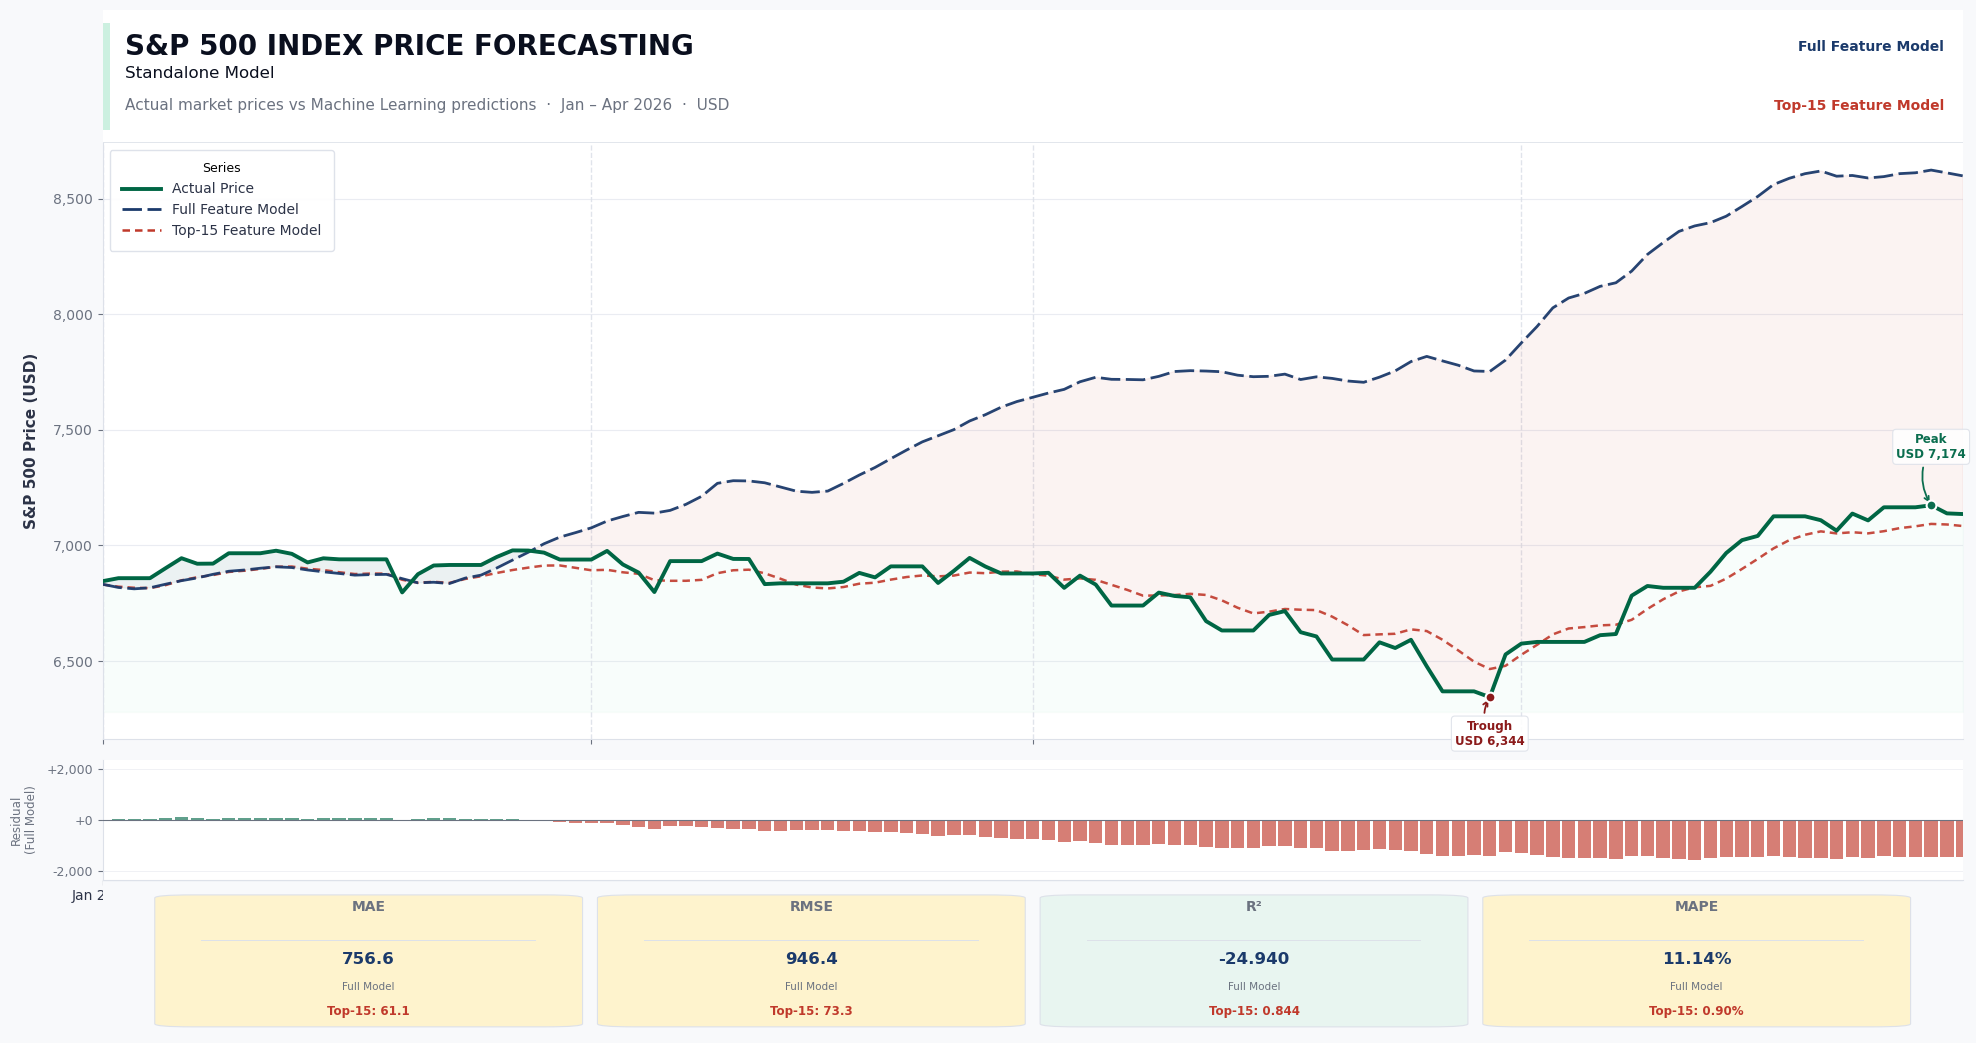

In [70]:
# ── KPI helper ────────────────────────────────────────────────────────────────
def kpis_SandP_500(a, p):
    mae  = np.mean(np.abs(a - p))
    rmse = np.sqrt(np.mean((a - p) ** 2))
    r2   = 1 - np.sum((a - p) ** 2) / np.sum((a - a.mean()) ** 2)
    mape = np.mean(np.abs((a - p) / a)) * 100
    return mae, rmse, r2, mape

plot_df_SandP_500   = test_SandP_500.sort_values('date').copy()
dates_SandP_500     = plot_df_SandP_500['date'].values
actual_SandP_500    = plot_df_SandP_500[target_col_SandP_500].values
full_pred_SandP_500 = plot_df_SandP_500['pred_price'].values
top_pred_SandP_500  = plot_df_SandP_500['pred_price_top'].values

mae_f_SandP_500, rmse_f_SandP_500, r2_f_SandP_500, mape_f_SandP_500 = kpis_SandP_500(actual_SandP_500, full_pred_SandP_500)
mae_t_SandP_500, rmse_t_SandP_500, r2_t_SandP_500, mape_t_SandP_500 = kpis_SandP_500(actual_SandP_500, top_pred_SandP_500)

# ── Palette ───────────────────────────────────────────────────────────────────
PAGE, WHITE, BORDER, GRID = '#F8F9FB', '#FFFFFF', '#DDE1E9', '#EAECF2'
MKT_DARK  = '#006644'
MKT_FILL  = '#CCF0E0'
NAVY      = '#1B3A6B'
CRIMSON   = '#C0392B'
TEXT_H, TEXT_B, TEXT_M = '#0A0F1E', '#2C3347', '#6B7280'
GREEN_KPI, GREEN_BG     = '#0B6E4F', '#E8F5F0'
RED_KPI                 = '#8B1A1A'
AMBER_KPI, AMBER_BG     = '#7A4F00', '#FEF3CD'

# ── Figure & layout ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 11), facecolor=PAGE)
outer = gridspec.GridSpec(3, 1, height_ratios=[0.13, 0.72, 0.15],
                          hspace=0, left=0.04, right=0.97, top=0.97, bottom=0.04)

# ── Header band ───────────────────────────────────────────────────────────────
ax_head = fig.add_subplot(outer[0])
ax_head.set_facecolor(WHITE)
ax_head.set_xlim(0, 1); ax_head.set_ylim(0, 1)
for sp in ax_head.spines.values(): sp.set_visible(False)
ax_head.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax_head.add_patch(mpatches.FancyBboxPatch((0, 0.1), 0.004, 0.8,
    boxstyle='square,pad=0', fc=MKT_FILL, ec='none',
    transform=ax_head.transAxes, clip_on=False))
ax_head.text(0.012, 0.72, 'S&P 500 INDEX PRICE FORECASTING', transform=ax_head.transAxes,
             fontsize=20, fontweight='bold', color=TEXT_H, va='center')
ax_head.text(0.012, 0.52, 'Standalone Model', transform=ax_head.transAxes,
             fontsize=12, fontweight='normal', color=TEXT_H, va='center')
ax_head.text(0.012, 0.28,
    'Actual market prices vs Machine Learning predictions  ·  Jan – Apr 2026  ·  USD',
    transform=ax_head.transAxes, fontsize=11, color=TEXT_M, va='center')
ax_head.text(0.99, 0.72, 'Full Feature Model', transform=ax_head.transAxes,
             fontsize=10, fontweight='bold', color=NAVY, ha='right', va='center')
ax_head.text(0.99, 0.28, f'Top-{top_k_SandP_500} Feature Model', transform=ax_head.transAxes,
             fontsize=10, fontweight='bold', color=CRIMSON, ha='right', va='center')
ax_head.axhline(0, color=BORDER, linewidth=1.2)

# ── Chart + residual ──────────────────────────────────────────────────────────
inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[1],
                                         height_ratios=[5, 1], hspace=0.06)
ax   = fig.add_subplot(inner[0])
ax_r = fig.add_subplot(inner[1], sharex=ax)

for a in [ax, ax_r]:
    a.set_facecolor(WHITE)
    a.tick_params(colors=TEXT_M, labelsize=10)
    for sp in a.spines.values(): sp.set_edgecolor(BORDER); sp.set_linewidth(0.8)
    a.spines['top'].set_visible(False); a.spines['right'].set_visible(False)

# fills
ax.fill_between(dates_SandP_500, actual_SandP_500, actual_SandP_500.min() - actual_SandP_500.min() * 0.01,
    color=MKT_FILL, alpha=0.12, zorder=1)
ax.fill_between(dates_SandP_500, actual_SandP_500, full_pred_SandP_500,
    where=(actual_SandP_500 >= full_pred_SandP_500), color=NAVY,    alpha=0.06, zorder=2, interpolate=True)
ax.fill_between(dates_SandP_500, actual_SandP_500, full_pred_SandP_500,
    where=(actual_SandP_500 < full_pred_SandP_500),  color=CRIMSON, alpha=0.06, zorder=2, interpolate=True)

# lines
ax.plot(dates_SandP_500, actual_SandP_500,    color=MKT_DARK, linewidth=2.8, zorder=6,
        solid_capstyle='round', label='Actual Price')
ax.plot(dates_SandP_500, full_pred_SandP_500, color=NAVY,     linewidth=2.0, linestyle=(0,(7,2)),
        zorder=5, alpha=0.95, label='Full Feature Model')
ax.plot(dates_SandP_500, top_pred_SandP_500,  color=CRIMSON,  linewidth=1.8, linestyle=(0,(3,2)),
        zorder=4, alpha=0.90, label=f'Top-{top_k_SandP_500} Feature Model')

# month dividers
for ms in pd.date_range(plot_df_SandP_500['date'].min(), plot_df_SandP_500['date'].max(), freq='MS'):
    ax.axvline(ms, color=BORDER, linewidth=1.0, linestyle='--', alpha=0.9, zorder=1)
ax.set_xlim(dates_SandP_500[0], dates_SandP_500[-1])

# peak & trough annotations
pidx_SandP_500 = np.argmax(actual_SandP_500)
pval_SandP_500 = actual_SandP_500[pidx_SandP_500]
pdate_SandP_500 = dates_SandP_500[pidx_SandP_500]
tidx_SandP_500 = np.argmin(actual_SandP_500)
tval_SandP_500 = actual_SandP_500[tidx_SandP_500]
tdate_SandP_500 = dates_SandP_500[tidx_SandP_500]
offset_SandP_500 = actual_SandP_500.mean() * 0.03
for x, y, lbl, col, ya, arc in [
    (pdate_SandP_500, pval_SandP_500, f'Peak\nUSD {pval_SandP_500:,.0f}',   GREEN_KPI, pval_SandP_500 + offset_SandP_500,   0.3),
    (tdate_SandP_500, tval_SandP_500, f'Trough\nUSD {tval_SandP_500:,.0f}', RED_KPI,   tval_SandP_500 - offset_SandP_500,  -0.3),
]:
    ax.annotate(lbl, xy=(x, y), xytext=(x, ya), color=col,
        fontsize=8.5, fontweight='bold', ha='center',
        arrowprops=dict(arrowstyle='->', color=col,
            connectionstyle=f'arc3,rad={arc}', lw=1.3),
        bbox=dict(boxstyle='round,pad=0.3', fc=WHITE, ec=BORDER, alpha=0.9, lw=0.8),
        zorder=10)
    ax.scatter([x], [y], color=col, s=50, zorder=11, edgecolors=WHITE, linewidths=1.5)

# grid & labels
ax.yaxis.grid(True, color=GRID, linewidth=0.8, zorder=0); ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_ylabel(f'S&P 500 Price (USD)', color=TEXT_B, fontsize=11,
              fontweight='bold', labelpad=10)
ax.tick_params(axis='x', labelbottom=False)

ax.legend(handles=[
    Line2D([0], [0], color=MKT_DARK, linewidth=2.8,                      label='Actual Price'),
    Line2D([0], [0], color=NAVY,      linewidth=2.0, linestyle=(0,(7,2)), label='Full Feature Model'),
    Line2D([0], [0], color=CRIMSON,   linewidth=1.8, linestyle=(0,(3,2)), label=f'Top-{top_k_SandP_500} Feature Model'),
], loc='upper left', frameon=True, framealpha=0.95, facecolor=WHITE, edgecolor=BORDER,
   labelcolor=TEXT_B, fontsize=10, borderpad=0.9, handlelength=2.8,
   title='Series', title_fontsize=9)

# residual strip
res_SandP_500 = actual_SandP_500 - full_pred_SandP_500
ax_r.bar(dates_SandP_500, res_SandP_500,
         color=[GREEN_KPI if v >= 0 else CRIMSON for v in res_SandP_500],
         alpha=0.65, width=0.85, zorder=3)
ax_r.axhline(0, color=TEXT_M, linewidth=0.8, zorder=4)
ax_r.yaxis.grid(True, color=GRID, linewidth=0.5, zorder=0); ax_r.set_axisbelow(True)
ax_r.set_ylabel('Residual\n(Full Model)', color=TEXT_M, fontsize=8.5, labelpad=6)
ax_r.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+,.0f}'))
ax_r.tick_params(colors=TEXT_M, labelsize=9)
pad_SandP_500 = max(abs(res_SandP_500.min()), abs(res_SandP_500.max())) * 1.5
ax_r.set_ylim(-pad_SandP_500, pad_SandP_500)
ax_r.xaxis.set_major_locator(mdates.MonthLocator())
ax_r.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax_r.tick_params(axis='x', labelsize=10, colors=TEXT_B)

# ── KPI strip ─────────────────────────────────────────────────────────────────
ax_kpi = fig.add_subplot(outer[2])
ax_kpi.set_facecolor(PAGE); ax_kpi.set_xlim(0, 1); ax_kpi.set_ylim(0, 1)
for sp in ax_kpi.spines.values(): sp.set_visible(False)
ax_kpi.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax_kpi.axhline(1.0, color=BORDER, linewidth=1.0)

kpi_cards_SandP_500 = [
    ('MAE',  f'{mae_f_SandP_500:,.1f}',  f'{mae_t_SandP_500:,.1f}',  AMBER_KPI, AMBER_BG),
    ('RMSE', f'{rmse_f_SandP_500:,.1f}', f'{rmse_t_SandP_500:,.1f}', AMBER_KPI, AMBER_BG),
    ('R²',   f'{r2_f_SandP_500:.3f}',    f'{r2_t_SandP_500:.3f}',    GREEN_KPI, GREEN_BG),
    ('MAPE', f'{mape_f_SandP_500:.2f}%', f'{mape_t_SandP_500:.2f}%', AMBER_KPI, AMBER_BG),
]
card_w = 0.19
gap    = (1.0 - len(kpi_cards_SandP_500) * card_w) / (len(kpi_cards_SandP_500) + 1)
for i, (metric, vf, vt, tcol, bgcol) in enumerate(kpi_cards_SandP_500):
    x0 = gap + i * (card_w + gap); xc = x0 + card_w / 2
    ax_kpi.add_patch(mpatches.FancyBboxPatch((x0, 0.06), card_w, 0.82,
        boxstyle='round,pad=0.02', fc=bgcol, ec=BORDER, linewidth=0.8,
        transform=ax_kpi.transAxes, clip_on=False))
    ax_kpi.text(xc, 0.82, metric, transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=10, fontweight='bold', color=TEXT_M)
    ax_kpi.add_patch(mpatches.FancyBboxPatch((x0 + 0.005, 0.60), card_w - 0.01, 0.005,
        boxstyle='square,pad=0', fc=BORDER, ec='none',
        transform=ax_kpi.transAxes, clip_on=False))
    ax_kpi.text(xc, 0.48, vf, transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=12, fontweight='bold', color=NAVY)
    ax_kpi.text(xc, 0.30, 'Full Model', transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=7.5, color=TEXT_M)
    ax_kpi.text(xc, 0.14, f'Top-{top_k_SandP_500}: {vt}', transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=8.5, fontweight='bold', color=CRIMSON)

plt.savefig(ai_data_dir / 'visualizations'/'standalone_SandP_500_price_prediction_model.png',
            dpi=300, bbox_inches='tight', facecolor=PAGE)
plt.show()

<h4 style="color: #CEDDF4;"> 5.23 S&P 500 Price Prediction (tomorrow)</h4>

In [71]:
latest_top_SandP_500 = X_test_top_SandP_500.iloc[-1:]

pred_return_tomorrow_SandP_500 = top_model_SandP_500.predict(latest_top_SandP_500)[0]

last_log_price_SandP_500 = np.log(train_SandP_500[target_col_SandP_500].iloc[-1])

pred_price_tomorrow_SandP_500 = np.exp(last_log_price_SandP_500 + pred_return_tomorrow_SandP_500)

print("Predicted S&P 500 Price Tomorrow:", pred_price_tomorrow_SandP_500)

Predicted S&P 500 Price Tomorrow: 6839.159235106022


<h4 style="color: #CEDDF4;">6. Dow Jones Price Prediction</h4>

<h4 style="color: #CEDDF4;"> 6.1 Setup</h4>

In [72]:
# define target variable
target_col_Dow_Jones = 'dowjones_price_usd'
# avoid modifying original dataset
df_Dow_Jones = pd.read_csv(ai_data_dir / 'new_master_table.csv')

<h4 style="color: #CEDDF4;"> 6.2 Time preprocessing</h4>

In [73]:
df_Dow_Jones['date'] = pd.to_datetime(df_Dow_Jones['date'], dayfirst=False, format='mixed', errors='coerce')
df_Dow_Jones = df_Dow_Jones.sort_values('date')

<h4 style="color: #CEDDF4;"> 6.3 Remove leakage features</h4>

In [74]:
# ── 1. always-drop keywords (leakage, noise, duplicates) ────────────────────
leakage_keywords_Dow_Jones = [
    '_open_', '_high_', '_low_',     # intraday OHLC leakage on all assets
    '_open',  '_high',  '_low',      # suffix variants
    'gpr_event',                     # forward-looking GPR event flag
    'ai_gpr_Unnamed',                # index artefact
    'gold_price_oz_egp',             # EGP-denominated gold (derived, leaks FX)
    'cbe_inflations_headline_inflation_yy',  # monthly fill creates leakage
    'cbe_inflations_core_inflation_yy',
    '_energy_',                      # all country-level energy mix columns
    'egpusd_value',                  # duplicated by FX cols
    'dollar_historical_data_value',  # duplicated by dollarindex_value
    'cpi_PCPIPCH',                   # duplicate CPI series
]

df_Dow_Jones = df_Dow_Jones.drop(columns=[
    c for c in df_Dow_Jones.columns
    if any(k in c for k in leakage_keywords_Dow_Jones)
], errors='ignore')

# ── 2. drop all OTHER stock market price columns (cross-market leakage) ───────
other_stock_cols_Dow_Jones = [
    'nasdaq_price_usd',
    'nasdaq_high_usd',
    'nasdaq_low_usd',
    'nasdaq_open_usd',
    'sp500_price_usd',
    'sp500_high_usd',
    'sp500_low_usd',
    'sp500_open_usd',
    'dowjones_high_usd',
    'dowjones_low_usd',
    'dowjones_open_usd',
    'china_shanghai_price_usd',
    'china_shanghai_high_usd',
    'china_shanghai_low_usd',
    'china_shanghai_open_usd',
    'hongkong_hongkong_price_usd',
    'hongkong_hongkong_high_usd',
    'hongkong_hongkong_low_usd',
    'hongkong_hongkong_open_usd',
    'uk_london_price_usd',
    'uk_london_high_usd',
    'uk_london_low_usd',
    'uk_london_open_usd',
    'japan_tokyo_price_usd',
    'japan_tokyo_high_usd',
    'japan_tokyo_low_usd',
    'japan_tokyo_open_usd',
    'egx30_price_egp',
    'egx30_high_price_egp',
    'egx30_low_price_egp',
    'egx30_change_percent',
]

df_Dow_Jones = df_Dow_Jones.drop(columns=[
    c for c in other_stock_cols_Dow_Jones if c in df_Dow_Jones.columns
], errors='ignore')

<h4 style="color: #CEDDF4;"> 6.4 Macro feature engineering</h4>

In [75]:
df_Dow_Jones['real_rate_us'] = df_Dow_Jones['usd_fedfunds_value'] - df_Dow_Jones['cpi_value']            # US real interest rate
df_Dow_Jones['real_rate_eu'] = df_Dow_Jones['euro_interest_value'] - df_Dow_Jones['euro_inflation_value']  # EU real interest rate

df_Dow_Jones['yield_spread_10_2'] = (                                                               # US yield curve spread
    df_Dow_Jones['10y_treasury_historical_data_monthly_value'] -
    df_Dow_Jones['2y_treasury_historical_data_monthly_value']
)
df_Dow_Jones['yield_spread_10_1'] = (                                                               # short-end spread
    df_Dow_Jones['10y_treasury_historical_data_monthly_value'] -
    df_Dow_Jones['1y_treasury_historical_data_monthly_value']
)

df_Dow_Jones['oil_x_dxy']  = df_Dow_Jones['brent_oil_price_usd'] * df_Dow_Jones['dollarindex_value']     # oil × dollar interaction
df_Dow_Jones['vix_x_dxy']  = df_Dow_Jones['vix_price_usd']       * df_Dow_Jones['dollarindex_value']     # volatility × dollar interaction
df_Dow_Jones['gold_x_dxy'] = df_Dow_Jones['gold_price_usd']      * df_Dow_Jones['dollarindex_value']     # gold × dollar interaction

df_Dow_Jones['vix_mom']  = df_Dow_Jones['vix_price_usd'].pct_change()        # VIX momentum (risk-on/off)
df_Dow_Jones['oil_mom']  = df_Dow_Jones['brent_oil_price_usd'].pct_change()  # oil momentum
df_Dow_Jones['gold_mom'] = df_Dow_Jones['gold_price_usd'].pct_change()       # gold momentum

<h4 style="color: #CEDDF4;"> 6.5 Feature engineering</h4>

In [76]:
df_Dow_Jones['log_price'] = np.log(df_Dow_Jones[target_col_Dow_Jones])  # log transformation for stability
df_Dow_Jones['return']    = df_Dow_Jones['log_price'].diff()            # daily log-return

# ── simple moving averages & distance from SMA (trend-following signals) ──────
for w in [5, 10, 20, 50]:
    df_Dow_Jones[f'sma_{w}']          = df_Dow_Jones[target_col_Dow_Jones].rolling(w).mean().shift(1)
    df_Dow_Jones[f'price_vs_sma_{w}'] = (df_Dow_Jones[target_col_Dow_Jones] / df_Dow_Jones[f'sma_{w}'] - 1).shift(1)

# ── RSI-14 (momentum oscillator) ──────────────────────────────────────────────
_delta_Dow_Jones    = df_Dow_Jones['return'].clip(lower=0)
_loss_Dow_Jones     = (-df_Dow_Jones['return']).clip(lower=0)
_avg_gain_Dow_Jones = _delta_Dow_Jones.rolling(14).mean()
_avg_loss_Dow_Jones = _loss_Dow_Jones.rolling(14).mean().replace(0, 1e-9)
df_Dow_Jones['rsi_14'] = (100 - 100 / (1 + _avg_gain_Dow_Jones / _avg_loss_Dow_Jones)).shift(1)

# ── Bollinger Band width (volatility regime signal) ───────────────────────────
_bb_mid_Dow_Jones       = df_Dow_Jones[target_col_Dow_Jones].rolling(20).mean()
_bb_std_Dow_Jones       = df_Dow_Jones[target_col_Dow_Jones].rolling(20).std()
df_Dow_Jones['bb_width']= (4 * _bb_std_Dow_Jones / _bb_mid_Dow_Jones).shift(1)  # normalised bandwidth

# ── calendar features ─────────────────────────────────────────────────────────
df_Dow_Jones['day_of_week']    = df_Dow_Jones['date'].dt.dayofweek    # Mon=0 … Fri=4
df_Dow_Jones['month']          = df_Dow_Jones['date'].dt.month
df_Dow_Jones['quarter']        = df_Dow_Jones['date'].dt.quarter
df_Dow_Jones['is_month_end']   = df_Dow_Jones['date'].dt.is_month_end.astype(int)
df_Dow_Jones['is_quarter_end'] = df_Dow_Jones['date'].dt.is_quarter_end.astype(int)

# ── target: next-day smoothed return (identical to gold/oil model) ────────────
df_Dow_Jones['target'] = df_Dow_Jones['return'].rolling(5).mean().shift(-1)  # future smoothed return target
df_Dow_Jones['target'] = df_Dow_Jones['target'].clip(-0.03, 0.03)            # limit extreme values

<h4 style="color: #CEDDF4;"> 6.6 Lag features</h4>

In [77]:
for lag in [1, 2, 3, 5, 10, 20]:
    df_Dow_Jones[f'return_lag_{lag}'] = df_Dow_Jones['return'].shift(lag)  # past returns

df_Dow_Jones['log_price_lag1'] = df_Dow_Jones['log_price'].shift(1)  # previous price level

# ── lagged macro signals (prevent same-day leakage) ──────────────────────────
df_Dow_Jones['vix_lag1']      = df_Dow_Jones['vix_price_usd'].shift(1)   # yesterday's fear index
df_Dow_Jones['gold_lag1']     = df_Dow_Jones['gold_price_usd'].shift(1)  # yesterday's gold price
df_Dow_Jones['oil_lag1']      = df_Dow_Jones['brent_oil_price_usd'].shift(1)  # yesterday's oil price
df_Dow_Jones['dxy_lag1']      = df_Dow_Jones['dollarindex_value'].shift(1)    # yesterday's dollar index

C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\181505753.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_Dow_Jones['dxy_lag1']      = df_Dow_Jones['dollarindex_value'].shift(1)    # yesterday's dollar index


<h4 style="color: #CEDDF4;"> 6.7 Volatility and momentum</h4>

In [78]:
df_Dow_Jones['vol_7']         = df_Dow_Jones['return'].rolling(7).std().shift(1)    # short-term realised volatility
df_Dow_Jones['vol_20']        = df_Dow_Jones['return'].rolling(20).std().shift(1)   # medium-term realised volatility
df_Dow_Jones['vol_ratio']     = df_Dow_Jones['vol_7'] / (df_Dow_Jones['vol_20'] + 1e-9)  # vol regime: >1 = expanding

df_Dow_Jones['mom_7']         = df_Dow_Jones['return'].rolling(7).mean().shift(1)   # short-term momentum
df_Dow_Jones['mom_20']        = df_Dow_Jones['return'].rolling(20).mean().shift(1)  # medium-term momentum
df_Dow_Jones['mom_crossover'] = df_Dow_Jones['mom_7'] - df_Dow_Jones['mom_20']           # momentum crossover signal

df_Dow_Jones['price_trend_7'] = df_Dow_Jones[target_col_Dow_Jones].rolling(7).mean().shift(1)   # 7-day price trend
df_Dow_Jones['price_trend_20']= df_Dow_Jones[target_col_Dow_Jones].rolling(20).mean().shift(1)  # 20-day price trend

C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\2014395727.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_Dow_Jones['vol_7']         = df_Dow_Jones['return'].rolling(7).std().shift(1)    # short-term realised volatility
C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\2014395727.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_Dow_Jones['vol_20']        = df_Dow_Jones['return'].rolling(20).std().shift(1)   # medium-term realised volatility
C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\2014395727.py:3: Performan

<h4 style="color: #CEDDF4;"> 6.8 Data cleaning</h4>

In [79]:
df_Dow_Jones = df_Dow_Jones.dropna()  # remove missing values

<h4 style="color: #CEDDF4;"> 6.9 Feature selection</h4>

In [80]:
features_Dow_Jones = [c for c in df_Dow_Jones.columns if c not in ['date', target_col_Dow_Jones, 'target']]  # model inputs

<h4 style="color: #CEDDF4;"> 6.10 Train/test split</h4>

In [81]:
train_Dow_Jones = df_Dow_Jones[df_Dow_Jones['date'] <= '2025-12-31']                                            # training period
test_Dow_Jones  = df_Dow_Jones[(df_Dow_Jones['date'] > '2025-12-31') & (df_Dow_Jones['date'] <= '2026-04-30')]  # testing period

X_train_Dow_Jones = train_Dow_Jones[features_Dow_Jones]
y_train_Dow_Jones = train_Dow_Jones['target']

X_test_Dow_Jones  = test_Dow_Jones[features_Dow_Jones]
y_test_Dow_Jones  = test_Dow_Jones['target']

<h4 style="color: #CEDDF4;"> 6.11 time series Cross-validation</h4>

In [82]:
tscv_Dow_Jones = TimeSeriesSplit(n_splits=5)

for i, (tr, val) in enumerate(tscv_Dow_Jones.split(X_train_Dow_Jones)):

    model_cv_Dow_Jones = lgb.LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.01,
        num_leaves=64,
        max_depth=6,
        verbose=-1
    )

    model_cv_Dow_Jones.fit(X_train_Dow_Jones.iloc[tr], y_train_Dow_Jones.iloc[tr])  # train fold model

    pred_cv_Dow_Jones = model_cv_Dow_Jones.predict(X_train_Dow_Jones.iloc[val])  # validation prediction

    print("Fold", i+1)
    print("MAE:", mean_absolute_error(y_train_Dow_Jones.iloc[val], pred_cv_Dow_Jones))  # error
    print("DIR:", np.mean(np.sign(y_train_Dow_Jones.iloc[val]) == np.sign(pred_cv_Dow_Jones)))  # direction accuracy

Fold 1
MAE: 0.0015744368300840495
DIR: 0.8466666666666667
Fold 2
MAE: 0.0022868191235454805
DIR: 0.83
Fold 3
MAE: 0.001601770383709827
DIR: 0.8333333333333334
Fold 4
MAE: 0.0014422312685913197
DIR: 0.7933333333333333
Fold 5
MAE: 0.0013406725002066892
DIR: 0.81


<h4 style="color: #CEDDF4;"> 6.12 Full Model training</h4>

In [83]:
model_Dow_Jones = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

model_Dow_Jones.fit(X_train_Dow_Jones, y_train_Dow_Jones)

,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.01
,n_estimators,3000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


<h4 style="color: #CEDDF4;"> 6.13 Feature selection</h4>

In [84]:
selector_Dow_Jones = SelectFromModel(model_Dow_Jones, threshold='median', prefit=True)

X_train_sel_Dow_Jones = selector_Dow_Jones.transform(X_train_Dow_Jones)
X_test_sel_Dow_Jones  = selector_Dow_Jones.transform(X_test_Dow_Jones)

model_Dow_Jones.fit(X_train_sel_Dow_Jones, y_train_Dow_Jones)

with open(ai_data_dir/'models'/"standalone_Dow_full_features_model.pkl", "wb") as f:
    pickle.dump(model_Dow_Jones, f)

c:\Users\HMSY\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
c:\Users\HMSY\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


<h4 style="color: #CEDDF4;"> 6.14 Prediction (full model)</h4>

In [85]:
pred_returns_Dow_Jones = model_Dow_Jones.predict(X_test_sel_Dow_Jones)

c:\Users\HMSY\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


<h4 style="color: #CEDDF4;"> 6.15 Price Prediction (full model)</h4>

In [86]:
start_price_Dow_Jones = train_Dow_Jones[target_col_Dow_Jones].iloc[-1]

prices_Dow_Jones = [start_price_Dow_Jones]

for r in pred_returns_Dow_Jones:
    prices_Dow_Jones.append(prices_Dow_Jones[-1] * np.exp(r))

prices_Dow_Jones = prices_Dow_Jones[1:]

test_Dow_Jones = test_Dow_Jones.copy()
test_Dow_Jones['pred_price'] = prices_Dow_Jones

<h4 style="color: #CEDDF4;"> 6.16 Evaluation (full model)</h4>

In [87]:
mae_Dow_Jones       = mean_absolute_error(test_Dow_Jones[target_col_Dow_Jones], test_Dow_Jones['pred_price'])
direction_Dow_Jones = np.mean(np.sign(test_Dow_Jones['target']) == np.sign(pred_returns_Dow_Jones))

print("Full Model MAE:", mae_Dow_Jones)
print("Full Model Direction:", direction_Dow_Jones)

Full Model MAE: 5650.671980944644
Full Model Direction: 0.7226890756302521


<h4 style="color: #CEDDF4;"> 6.17 Top Features Extraction</h4>

In [88]:
importance_model_Dow_Jones = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

importance_model_Dow_Jones.fit(X_train_Dow_Jones, y_train_Dow_Jones)

#model saving into pickle file

#with open(ai_data_dir/"Dow_Jones_top_features_model.pkl", "wb") as f:
    #pickle.dump(importance_model_Dow_Jones, f)

importance_Dow_Jones = pd.Series(
    importance_model_Dow_Jones.feature_importances_,
    index=X_train_Dow_Jones.columns
).sort_values(ascending=False)

<h4 style="color: #CEDDF4;"> 6.18 Top Features selection</h4>

In [89]:
top_k_Dow_Jones        = 15
top_features_Dow_Jones = importance_Dow_Jones.head(top_k_Dow_Jones).index.tolist()

X_train_top_Dow_Jones = X_train_Dow_Jones[top_features_Dow_Jones]
X_test_top_Dow_Jones  = X_test_Dow_Jones[top_features_Dow_Jones]

<h4 style="color: #CEDDF4;"> 6.19 Top model training</h4>

In [90]:
top_model_Dow_Jones = lgb.LGBMRegressor(
    objective='regression',
    boosting_type='gbdt',

    n_estimators=3000,
    learning_rate=0.02,

    num_leaves=128,
    max_depth=10,

    min_child_samples=10,
    min_child_weight=1e-3,

    subsample=0.9,
    subsample_freq=1,

    colsample_bytree=0.9,

    reg_alpha=0.1,
    reg_lambda=0.3,

    random_state=42,
    verbose=-1
)

top_model_Dow_Jones.fit(X_train_top_Dow_Jones, y_train_Dow_Jones)

#model saving into pickle file

with open(ai_data_dir/'models'/"standalone_Dow_top_features_model.pkl", "wb") as f:
    pickle.dump(top_model_Dow_Jones, f)

pred_top_Dow_Jones = top_model_Dow_Jones.predict(X_test_top_Dow_Jones)

<h4 style="color: #CEDDF4;"> 6.20 Price Prediction (top model)</h4>

In [91]:
prices_top_Dow_Jones = [start_price_Dow_Jones]

for r in pred_top_Dow_Jones:
    prices_top_Dow_Jones.append(prices_top_Dow_Jones[-1] * np.exp(r))

prices_top_Dow_Jones = prices_top_Dow_Jones[1:]

test_Dow_Jones['pred_price_top'] = prices_top_Dow_Jones

<h4 style="color: #CEDDF4;"> 6.21 Evaluation (top model)</h4>

In [92]:
mae_top_Dow_Jones       = mean_absolute_error(test_Dow_Jones[target_col_Dow_Jones], test_Dow_Jones['pred_price_top'])
direction_top_Dow_Jones = np.mean(np.sign(test_Dow_Jones['target']) == np.sign(pred_top_Dow_Jones))

print("Top Features Model MAE:", mae_top_Dow_Jones)
print("Top Features Model Direction:", direction_top_Dow_Jones)

Top Features Model MAE: 517.301093591288
Top Features Model Direction: 0.7983193277310925


<h4 style="color: #CEDDF4;"> 6.22 Model Comparison Using Visualizations</h4>

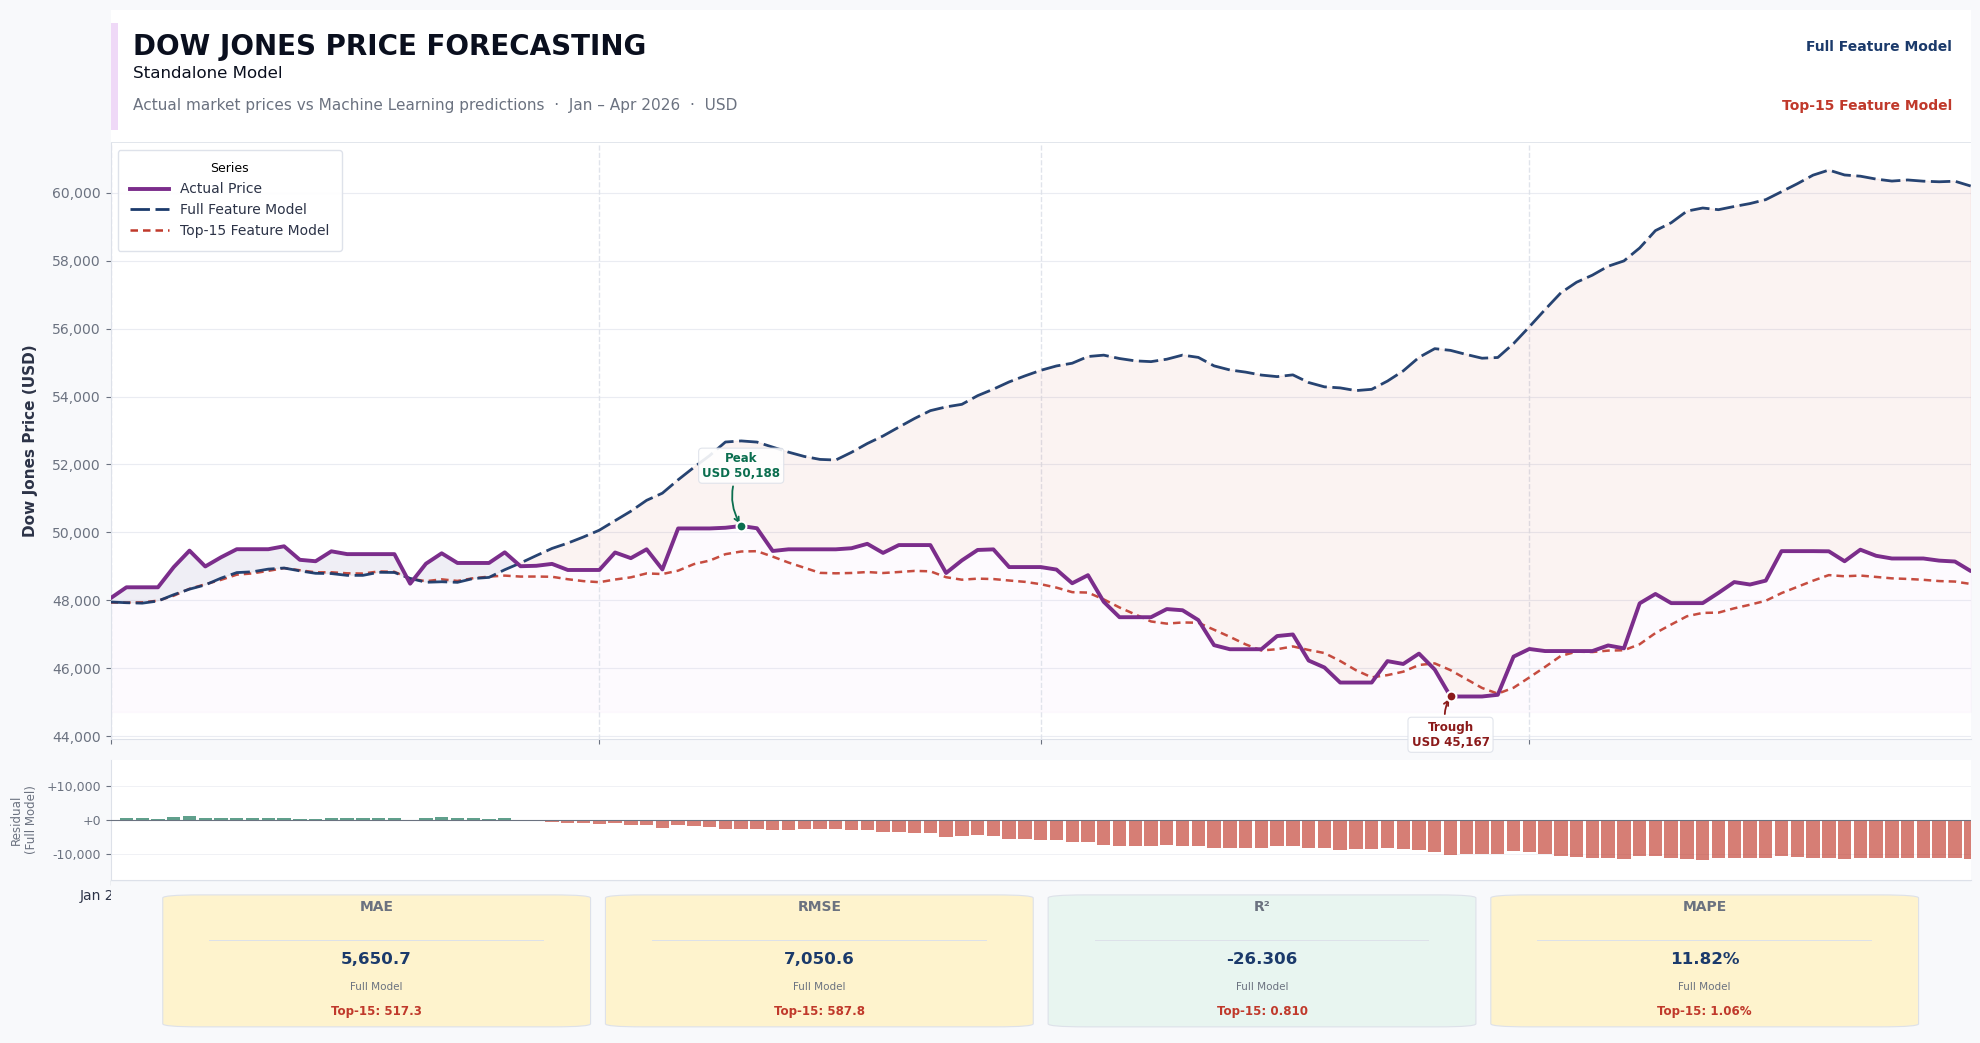

In [93]:
# ── KPI helper ────────────────────────────────────────────────────────────────
def kpis_Dow_Jones(a, p):
    mae  = np.mean(np.abs(a - p))
    rmse = np.sqrt(np.mean((a - p) ** 2))
    r2   = 1 - np.sum((a - p) ** 2) / np.sum((a - a.mean()) ** 2)
    mape = np.mean(np.abs((a - p) / a)) * 100
    return mae, rmse, r2, mape

plot_df_Dow_Jones   = test_Dow_Jones.sort_values('date').copy()
dates_Dow_Jones     = plot_df_Dow_Jones['date'].values
actual_Dow_Jones    = plot_df_Dow_Jones[target_col_Dow_Jones].values
full_pred_Dow_Jones = plot_df_Dow_Jones['pred_price'].values
top_pred_Dow_Jones  = plot_df_Dow_Jones['pred_price_top'].values

mae_f_Dow_Jones, rmse_f_Dow_Jones, r2_f_Dow_Jones, mape_f_Dow_Jones = kpis_Dow_Jones(actual_Dow_Jones, full_pred_Dow_Jones)
mae_t_Dow_Jones, rmse_t_Dow_Jones, r2_t_Dow_Jones, mape_t_Dow_Jones = kpis_Dow_Jones(actual_Dow_Jones, top_pred_Dow_Jones)

# ── Palette ───────────────────────────────────────────────────────────────────
PAGE, WHITE, BORDER, GRID = '#F8F9FB', '#FFFFFF', '#DDE1E9', '#EAECF2'
MKT_DARK  = '#7B2D8B'
MKT_FILL  = '#EFD9F7'
NAVY      = '#1B3A6B'
CRIMSON   = '#C0392B'
TEXT_H, TEXT_B, TEXT_M = '#0A0F1E', '#2C3347', '#6B7280'
GREEN_KPI, GREEN_BG     = '#0B6E4F', '#E8F5F0'
RED_KPI                 = '#8B1A1A'
AMBER_KPI, AMBER_BG     = '#7A4F00', '#FEF3CD'

# ── Figure & layout ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 11), facecolor=PAGE)
outer = gridspec.GridSpec(3, 1, height_ratios=[0.13, 0.72, 0.15],
                          hspace=0, left=0.04, right=0.97, top=0.97, bottom=0.04)

# ── Header band ───────────────────────────────────────────────────────────────
ax_head = fig.add_subplot(outer[0])
ax_head.set_facecolor(WHITE)
ax_head.set_xlim(0, 1); ax_head.set_ylim(0, 1)
for sp in ax_head.spines.values(): sp.set_visible(False)
ax_head.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax_head.add_patch(mpatches.FancyBboxPatch((0, 0.1), 0.004, 0.8,
    boxstyle='square,pad=0', fc=MKT_FILL, ec='none',
    transform=ax_head.transAxes, clip_on=False))
ax_head.text(0.012, 0.72, 'DOW JONES PRICE FORECASTING', transform=ax_head.transAxes,
             fontsize=20, fontweight='bold', color=TEXT_H, va='center')
ax_head.text(0.012, 0.52, 'Standalone Model', transform=ax_head.transAxes,
             fontsize=12, fontweight='normal', color=TEXT_H, va='center')
ax_head.text(0.012, 0.28,
    'Actual market prices vs Machine Learning predictions  ·  Jan – Apr 2026  ·  USD',
    transform=ax_head.transAxes, fontsize=11, color=TEXT_M, va='center')
ax_head.text(0.99, 0.72, 'Full Feature Model', transform=ax_head.transAxes,
             fontsize=10, fontweight='bold', color=NAVY, ha='right', va='center')
ax_head.text(0.99, 0.28, f'Top-{top_k_Dow_Jones} Feature Model', transform=ax_head.transAxes,
             fontsize=10, fontweight='bold', color=CRIMSON, ha='right', va='center')
ax_head.axhline(0, color=BORDER, linewidth=1.2)

# ── Chart + residual ──────────────────────────────────────────────────────────
inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[1],
                                         height_ratios=[5, 1], hspace=0.06)
ax   = fig.add_subplot(inner[0])
ax_r = fig.add_subplot(inner[1], sharex=ax)

for a in [ax, ax_r]:
    a.set_facecolor(WHITE)
    a.tick_params(colors=TEXT_M, labelsize=10)
    for sp in a.spines.values(): sp.set_edgecolor(BORDER); sp.set_linewidth(0.8)
    a.spines['top'].set_visible(False); a.spines['right'].set_visible(False)

# fills
ax.fill_between(dates_Dow_Jones, actual_Dow_Jones, actual_Dow_Jones.min() - actual_Dow_Jones.min() * 0.01,
    color=MKT_FILL, alpha=0.12, zorder=1)
ax.fill_between(dates_Dow_Jones, actual_Dow_Jones, full_pred_Dow_Jones,
    where=(actual_Dow_Jones >= full_pred_Dow_Jones), color=NAVY,    alpha=0.06, zorder=2, interpolate=True)
ax.fill_between(dates_Dow_Jones, actual_Dow_Jones, full_pred_Dow_Jones,
    where=(actual_Dow_Jones < full_pred_Dow_Jones),  color=CRIMSON, alpha=0.06, zorder=2, interpolate=True)

# lines
ax.plot(dates_Dow_Jones, actual_Dow_Jones,    color=MKT_DARK, linewidth=2.8, zorder=6,
        solid_capstyle='round', label='Actual Price')
ax.plot(dates_Dow_Jones, full_pred_Dow_Jones, color=NAVY,     linewidth=2.0, linestyle=(0,(7,2)),
        zorder=5, alpha=0.95, label='Full Feature Model')
ax.plot(dates_Dow_Jones, top_pred_Dow_Jones,  color=CRIMSON,  linewidth=1.8, linestyle=(0,(3,2)),
        zorder=4, alpha=0.90, label=f'Top-{top_k_Dow_Jones} Feature Model')

# month dividers
for ms in pd.date_range(plot_df_Dow_Jones['date'].min(), plot_df_Dow_Jones['date'].max(), freq='MS'):
    ax.axvline(ms, color=BORDER, linewidth=1.0, linestyle='--', alpha=0.9, zorder=1)
ax.set_xlim(dates_Dow_Jones[0], dates_Dow_Jones[-1])

# peak & trough annotations
pidx_Dow_Jones = np.argmax(actual_Dow_Jones)
pval_Dow_Jones = actual_Dow_Jones[pidx_Dow_Jones]
pdate_Dow_Jones = dates_Dow_Jones[pidx_Dow_Jones]
tidx_Dow_Jones = np.argmin(actual_Dow_Jones)
tval_Dow_Jones = actual_Dow_Jones[tidx_Dow_Jones]
tdate_Dow_Jones = dates_Dow_Jones[tidx_Dow_Jones]
offset_Dow_Jones = actual_Dow_Jones.mean() * 0.03
for x, y, lbl, col, ya, arc in [
    (pdate_Dow_Jones, pval_Dow_Jones, f'Peak\nUSD {pval_Dow_Jones:,.0f}',   GREEN_KPI, pval_Dow_Jones + offset_Dow_Jones,   0.3),
    (tdate_Dow_Jones, tval_Dow_Jones, f'Trough\nUSD {tval_Dow_Jones:,.0f}', RED_KPI,   tval_Dow_Jones - offset_Dow_Jones,  -0.3),
]:
    ax.annotate(lbl, xy=(x, y), xytext=(x, ya), color=col,
        fontsize=8.5, fontweight='bold', ha='center',
        arrowprops=dict(arrowstyle='->', color=col,
            connectionstyle=f'arc3,rad={arc}', lw=1.3),
        bbox=dict(boxstyle='round,pad=0.3', fc=WHITE, ec=BORDER, alpha=0.9, lw=0.8),
        zorder=10)
    ax.scatter([x], [y], color=col, s=50, zorder=11, edgecolors=WHITE, linewidths=1.5)

# grid & labels
ax.yaxis.grid(True, color=GRID, linewidth=0.8, zorder=0); ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_ylabel(f'Dow Jones Price (USD)', color=TEXT_B, fontsize=11,
              fontweight='bold', labelpad=10)
ax.tick_params(axis='x', labelbottom=False)

ax.legend(handles=[
    Line2D([0], [0], color=MKT_DARK, linewidth=2.8,                      label='Actual Price'),
    Line2D([0], [0], color=NAVY,      linewidth=2.0, linestyle=(0,(7,2)), label='Full Feature Model'),
    Line2D([0], [0], color=CRIMSON,   linewidth=1.8, linestyle=(0,(3,2)), label=f'Top-{top_k_Dow_Jones} Feature Model'),
], loc='upper left', frameon=True, framealpha=0.95, facecolor=WHITE, edgecolor=BORDER,
   labelcolor=TEXT_B, fontsize=10, borderpad=0.9, handlelength=2.8,
   title='Series', title_fontsize=9)

# residual strip
res_Dow_Jones = actual_Dow_Jones - full_pred_Dow_Jones
ax_r.bar(dates_Dow_Jones, res_Dow_Jones,
         color=[GREEN_KPI if v >= 0 else CRIMSON for v in res_Dow_Jones],
         alpha=0.65, width=0.85, zorder=3)
ax_r.axhline(0, color=TEXT_M, linewidth=0.8, zorder=4)
ax_r.yaxis.grid(True, color=GRID, linewidth=0.5, zorder=0); ax_r.set_axisbelow(True)
ax_r.set_ylabel('Residual\n(Full Model)', color=TEXT_M, fontsize=8.5, labelpad=6)
ax_r.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+,.0f}'))
ax_r.tick_params(colors=TEXT_M, labelsize=9)
pad_Dow_Jones = max(abs(res_Dow_Jones.min()), abs(res_Dow_Jones.max())) * 1.5
ax_r.set_ylim(-pad_Dow_Jones, pad_Dow_Jones)
ax_r.xaxis.set_major_locator(mdates.MonthLocator())
ax_r.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax_r.tick_params(axis='x', labelsize=10, colors=TEXT_B)

# ── KPI strip ─────────────────────────────────────────────────────────────────
ax_kpi = fig.add_subplot(outer[2])
ax_kpi.set_facecolor(PAGE); ax_kpi.set_xlim(0, 1); ax_kpi.set_ylim(0, 1)
for sp in ax_kpi.spines.values(): sp.set_visible(False)
ax_kpi.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax_kpi.axhline(1.0, color=BORDER, linewidth=1.0)

kpi_cards_Dow_Jones = [
    ('MAE',  f'{mae_f_Dow_Jones:,.1f}',  f'{mae_t_Dow_Jones:,.1f}',  AMBER_KPI, AMBER_BG),
    ('RMSE', f'{rmse_f_Dow_Jones:,.1f}', f'{rmse_t_Dow_Jones:,.1f}', AMBER_KPI, AMBER_BG),
    ('R²',   f'{r2_f_Dow_Jones:.3f}',    f'{r2_t_Dow_Jones:.3f}',    GREEN_KPI, GREEN_BG),
    ('MAPE', f'{mape_f_Dow_Jones:.2f}%', f'{mape_t_Dow_Jones:.2f}%', AMBER_KPI, AMBER_BG),
]
card_w = 0.19
gap    = (1.0 - len(kpi_cards_Dow_Jones) * card_w) / (len(kpi_cards_Dow_Jones) + 1)
for i, (metric, vf, vt, tcol, bgcol) in enumerate(kpi_cards_Dow_Jones):
    x0 = gap + i * (card_w + gap); xc = x0 + card_w / 2
    ax_kpi.add_patch(mpatches.FancyBboxPatch((x0, 0.06), card_w, 0.82,
        boxstyle='round,pad=0.02', fc=bgcol, ec=BORDER, linewidth=0.8,
        transform=ax_kpi.transAxes, clip_on=False))
    ax_kpi.text(xc, 0.82, metric, transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=10, fontweight='bold', color=TEXT_M)
    ax_kpi.add_patch(mpatches.FancyBboxPatch((x0 + 0.005, 0.60), card_w - 0.01, 0.005,
        boxstyle='square,pad=0', fc=BORDER, ec='none',
        transform=ax_kpi.transAxes, clip_on=False))
    ax_kpi.text(xc, 0.48, vf, transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=12, fontweight='bold', color=NAVY)
    ax_kpi.text(xc, 0.30, 'Full Model', transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=7.5, color=TEXT_M)
    ax_kpi.text(xc, 0.14, f'Top-{top_k_Dow_Jones}: {vt}', transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=8.5, fontweight='bold', color=CRIMSON)

plt.savefig(ai_data_dir / 'visualizations'/'standalone_Dow_Jones_price_prediction_model.png',
            dpi=300, bbox_inches='tight', facecolor=PAGE)
plt.show()

<h4 style="color: #CEDDF4;"> 6.23 Dow Jones Price Prediction (tomorrow)</h4>

In [94]:
latest_top_Dow_Jones = X_test_top_Dow_Jones.iloc[-1:]

pred_return_tomorrow_Dow_Jones = top_model_Dow_Jones.predict(latest_top_Dow_Jones)[0]

last_log_price_Dow_Jones = np.log(train_Dow_Jones[target_col_Dow_Jones].iloc[-1])

pred_price_tomorrow_Dow_Jones = np.exp(last_log_price_Dow_Jones + pred_return_tomorrow_Dow_Jones)

print("Predicted Dow Jones Price Tomorrow:", pred_price_tomorrow_Dow_Jones)

Predicted Dow Jones Price Tomorrow: 47992.94955442403


<h4 style="color: #CEDDF4;">7. Shanghai Price Prediction</h4>

<h4 style="color: #CEDDF4;"> 7.1 Setup</h4>

In [95]:
# define target variable
target_col_Shanghai = 'china_shanghai_price_usd'
# avoid modifying original dataset
df_Shanghai = pd.read_csv(ai_data_dir / 'new_master_table.csv')

<h4 style="color: #CEDDF4;"> 7.2 Time preprocessing</h4>

In [96]:
df_Shanghai['date'] = pd.to_datetime(df_Shanghai['date'], dayfirst=False, format='mixed', errors='coerce')
df_Shanghai = df_Shanghai.sort_values('date')

<h4 style="color: #CEDDF4;"> 7.3 Remove leakage features</h4>

In [97]:
# ── 1. always-drop keywords (leakage, noise, duplicates) ────────────────────
leakage_keywords_Shanghai = [
    '_open_', '_high_', '_low_',     # intraday OHLC leakage on all assets
    '_open',  '_high',  '_low',      # suffix variants
    'gpr_event',                     # forward-looking GPR event flag
    'ai_gpr_Unnamed',                # index artefact
    'gold_price_oz_egp',             # EGP-denominated gold (derived, leaks FX)
    'cbe_inflations_headline_inflation_yy',  # monthly fill creates leakage
    'cbe_inflations_core_inflation_yy',
    '_energy_',                      # all country-level energy mix columns
    'egpusd_value',                  # duplicated by FX cols
    'dollar_historical_data_value',  # duplicated by dollarindex_value
    'cpi_PCPIPCH',                   # duplicate CPI series
]

df_Shanghai = df_Shanghai.drop(columns=[
    c for c in df_Shanghai.columns
    if any(k in c for k in leakage_keywords_Shanghai)
], errors='ignore')

# ── 2. drop all OTHER stock market price columns (cross-market leakage) ───────
other_stock_cols_Shanghai = [
    'nasdaq_price_usd',
    'nasdaq_high_usd',
    'nasdaq_low_usd',
    'nasdaq_open_usd',
    'sp500_price_usd',
    'sp500_high_usd',
    'sp500_low_usd',
    'sp500_open_usd',
    'dowjones_price_usd',
    'dowjones_high_usd',
    'dowjones_low_usd',
    'dowjones_open_usd',
    'china_shanghai_high_usd',
    'china_shanghai_low_usd',
    'china_shanghai_open_usd',
    'hongkong_hongkong_price_usd',
    'hongkong_hongkong_high_usd',
    'hongkong_hongkong_low_usd',
    'hongkong_hongkong_open_usd',
    'uk_london_price_usd',
    'uk_london_high_usd',
    'uk_london_low_usd',
    'uk_london_open_usd',
    'japan_tokyo_price_usd',
    'japan_tokyo_high_usd',
    'japan_tokyo_low_usd',
    'japan_tokyo_open_usd',
    'egx30_price_egp',
    'egx30_high_price_egp',
    'egx30_low_price_egp',
    'egx30_change_percent',
]

df_Shanghai = df_Shanghai.drop(columns=[
    c for c in other_stock_cols_Shanghai if c in df_Shanghai.columns
], errors='ignore')

<h4 style="color: #CEDDF4;"> 7.4 Macro feature engineering</h4>

In [98]:
df_Shanghai['real_rate_us'] = df_Shanghai['usd_fedfunds_value'] - df_Shanghai['cpi_value']            # US real interest rate
df_Shanghai['real_rate_eu'] = df_Shanghai['euro_interest_value'] - df_Shanghai['euro_inflation_value']  # EU real interest rate

df_Shanghai['yield_spread_10_2'] = (                                                               # US yield curve spread
    df_Shanghai['10y_treasury_historical_data_monthly_value'] -
    df_Shanghai['2y_treasury_historical_data_monthly_value']
)
df_Shanghai['yield_spread_10_1'] = (                                                               # short-end spread
    df_Shanghai['10y_treasury_historical_data_monthly_value'] -
    df_Shanghai['1y_treasury_historical_data_monthly_value']
)

df_Shanghai['oil_x_dxy']  = df_Shanghai['brent_oil_price_usd'] * df_Shanghai['dollarindex_value']     # oil × dollar interaction
df_Shanghai['vix_x_dxy']  = df_Shanghai['vix_price_usd']       * df_Shanghai['dollarindex_value']     # volatility × dollar interaction
df_Shanghai['gold_x_dxy'] = df_Shanghai['gold_price_usd']      * df_Shanghai['dollarindex_value']     # gold × dollar interaction

df_Shanghai['vix_mom']  = df_Shanghai['vix_price_usd'].pct_change()        # VIX momentum (risk-on/off)
df_Shanghai['oil_mom']  = df_Shanghai['brent_oil_price_usd'].pct_change()  # oil momentum
df_Shanghai['gold_mom'] = df_Shanghai['gold_price_usd'].pct_change()       # gold momentum

<h4 style="color: #CEDDF4;"> 7.5 Feature engineering</h4>

In [99]:
df_Shanghai['log_price'] = np.log(df_Shanghai[target_col_Shanghai])  # log transformation for stability
df_Shanghai['return']    = df_Shanghai['log_price'].diff()            # daily log-return

# ── simple moving averages & distance from SMA (trend-following signals) ──────
for w in [5, 10, 20, 50]:
    df_Shanghai[f'sma_{w}']          = df_Shanghai[target_col_Shanghai].rolling(w).mean().shift(1)
    df_Shanghai[f'price_vs_sma_{w}'] = (df_Shanghai[target_col_Shanghai] / df_Shanghai[f'sma_{w}'] - 1).shift(1)

# ── RSI-14 (momentum oscillator) ──────────────────────────────────────────────
_delta_Shanghai    = df_Shanghai['return'].clip(lower=0)
_loss_Shanghai     = (-df_Shanghai['return']).clip(lower=0)
_avg_gain_Shanghai = _delta_Shanghai.rolling(14).mean()
_avg_loss_Shanghai = _loss_Shanghai.rolling(14).mean().replace(0, 1e-9)
df_Shanghai['rsi_14'] = (100 - 100 / (1 + _avg_gain_Shanghai / _avg_loss_Shanghai)).shift(1)

# ── Bollinger Band width (volatility regime signal) ───────────────────────────
_bb_mid_Shanghai       = df_Shanghai[target_col_Shanghai].rolling(20).mean()
_bb_std_Shanghai       = df_Shanghai[target_col_Shanghai].rolling(20).std()
df_Shanghai['bb_width']= (4 * _bb_std_Shanghai / _bb_mid_Shanghai).shift(1)  # normalised bandwidth

# ── calendar features ─────────────────────────────────────────────────────────
df_Shanghai['day_of_week']    = df_Shanghai['date'].dt.dayofweek    # Mon=0 … Fri=4
df_Shanghai['month']          = df_Shanghai['date'].dt.month
df_Shanghai['quarter']        = df_Shanghai['date'].dt.quarter
df_Shanghai['is_month_end']   = df_Shanghai['date'].dt.is_month_end.astype(int)
df_Shanghai['is_quarter_end'] = df_Shanghai['date'].dt.is_quarter_end.astype(int)

# ── target: next-day smoothed return (identical to gold/oil model) ────────────
df_Shanghai['target'] = df_Shanghai['return'].rolling(5).mean().shift(-1)  # future smoothed return target
df_Shanghai['target'] = df_Shanghai['target'].clip(-0.03, 0.03)            # limit extreme values

<h4 style="color: #CEDDF4;"> 7.6 Lag features</h4>

In [100]:
for lag in [1, 2, 3, 5, 10, 20]:
    df_Shanghai[f'return_lag_{lag}'] = df_Shanghai['return'].shift(lag)  # past returns

df_Shanghai['log_price_lag1'] = df_Shanghai['log_price'].shift(1)  # previous price level

# ── lagged macro signals (prevent same-day leakage) ──────────────────────────
df_Shanghai['vix_lag1']      = df_Shanghai['vix_price_usd'].shift(1)   # yesterday's fear index
df_Shanghai['gold_lag1']     = df_Shanghai['gold_price_usd'].shift(1)  # yesterday's gold price
df_Shanghai['oil_lag1']      = df_Shanghai['brent_oil_price_usd'].shift(1)  # yesterday's oil price
df_Shanghai['dxy_lag1']      = df_Shanghai['dollarindex_value'].shift(1)    # yesterday's dollar index

C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\2434179844.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_Shanghai['dxy_lag1']      = df_Shanghai['dollarindex_value'].shift(1)    # yesterday's dollar index


<h4 style="color: #CEDDF4;"> 7.7 Volatility and momentum</h4>

In [101]:
df_Shanghai['vol_7']         = df_Shanghai['return'].rolling(7).std().shift(1)    # short-term realised volatility
df_Shanghai['vol_20']        = df_Shanghai['return'].rolling(20).std().shift(1)   # medium-term realised volatility
df_Shanghai['vol_ratio']     = df_Shanghai['vol_7'] / (df_Shanghai['vol_20'] + 1e-9)  # vol regime: >1 = expanding

df_Shanghai['mom_7']         = df_Shanghai['return'].rolling(7).mean().shift(1)   # short-term momentum
df_Shanghai['mom_20']        = df_Shanghai['return'].rolling(20).mean().shift(1)  # medium-term momentum
df_Shanghai['mom_crossover'] = df_Shanghai['mom_7'] - df_Shanghai['mom_20']           # momentum crossover signal

df_Shanghai['price_trend_7'] = df_Shanghai[target_col_Shanghai].rolling(7).mean().shift(1)   # 7-day price trend
df_Shanghai['price_trend_20']= df_Shanghai[target_col_Shanghai].rolling(20).mean().shift(1)  # 20-day price trend

C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\1257298001.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_Shanghai['vol_7']         = df_Shanghai['return'].rolling(7).std().shift(1)    # short-term realised volatility
C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\1257298001.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_Shanghai['vol_20']        = df_Shanghai['return'].rolling(20).std().shift(1)   # medium-term realised volatility
C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\1257298001.py:3: PerformanceWa

<h4 style="color: #CEDDF4;"> 7.8 Data cleaning</h4>

In [102]:
df_Shanghai = df_Shanghai.dropna()  # remove missing values

<h4 style="color: #CEDDF4;"> 7.9 Feature selection</h4>

In [103]:
features_Shanghai = [c for c in df_Shanghai.columns if c not in ['date', target_col_Shanghai, 'target']]  # model inputs

<h4 style="color: #CEDDF4;"> 7.10 Train/test split</h4>

In [104]:
train_Shanghai = df_Shanghai[df_Shanghai['date'] <= '2025-12-31']                                            # training period
test_Shanghai  = df_Shanghai[(df_Shanghai['date'] > '2025-12-31') & (df_Shanghai['date'] <= '2026-04-30')]  # testing period

X_train_Shanghai = train_Shanghai[features_Shanghai]
y_train_Shanghai = train_Shanghai['target']

X_test_Shanghai  = test_Shanghai[features_Shanghai]
y_test_Shanghai  = test_Shanghai['target']

<h4 style="color: #CEDDF4;"> 7.11 time series Cross-validation</h4>

In [105]:
tscv_Shanghai = TimeSeriesSplit(n_splits=5)

for i, (tr, val) in enumerate(tscv_Shanghai.split(X_train_Shanghai)):

    model_cv_Shanghai = lgb.LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.01,
        num_leaves=64,
        max_depth=6,
        verbose=-1
    )

    model_cv_Shanghai.fit(X_train_Shanghai.iloc[tr], y_train_Shanghai.iloc[tr])  # train fold model

    pred_cv_Shanghai = model_cv_Shanghai.predict(X_train_Shanghai.iloc[val])  # validation prediction

    print("Fold", i+1)
    print("MAE:", mean_absolute_error(y_train_Shanghai.iloc[val], pred_cv_Shanghai))  # error
    print("DIR:", np.mean(np.sign(y_train_Shanghai.iloc[val]) == np.sign(pred_cv_Shanghai)))  # direction accuracy

Fold 1
MAE: 0.002537953711086124
DIR: 0.7616666666666667
Fold 2
MAE: 0.0017588388439176057
DIR: 0.8183333333333334
Fold 3
MAE: 0.0016537449672699238
DIR: 0.785
Fold 4
MAE: 0.0013368198934600348
DIR: 0.7783333333333333
Fold 5
MAE: 0.001382411391663243
DIR: 0.7966666666666666


<h4 style="color: #CEDDF4;"> 7.12 Full Model training</h4>

In [106]:
model_Shanghai = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

model_Shanghai.fit(X_train_Shanghai, y_train_Shanghai)

,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.01
,n_estimators,3000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


<h4 style="color: #CEDDF4;"> 7.13 Feature selection</h4>

In [107]:
selector_Shanghai = SelectFromModel(model_Shanghai, threshold='median', prefit=True)

X_train_sel_Shanghai = selector_Shanghai.transform(X_train_Shanghai)
X_test_sel_Shanghai  = selector_Shanghai.transform(X_test_Shanghai)

model_Shanghai.fit(X_train_sel_Shanghai, y_train_Shanghai)

with open(ai_data_dir/'models'/"standalone_shanghai_full_features_model.pkl", "wb") as f:
    pickle.dump(model_Shanghai, f)

c:\Users\HMSY\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
c:\Users\HMSY\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


<h4 style="color: #CEDDF4;"> 7.14 Prediction (full model)</h4>

In [108]:
pred_returns_Shanghai = model_Shanghai.predict(X_test_sel_Shanghai)

c:\Users\HMSY\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


<h4 style="color: #CEDDF4;"> 7.15 Price Prediction (full model)</h4>

In [109]:
start_price_Shanghai = train_Shanghai[target_col_Shanghai].iloc[-1]

prices_Shanghai = [start_price_Shanghai]

for r in pred_returns_Shanghai:
    prices_Shanghai.append(prices_Shanghai[-1] * np.exp(r))

prices_Shanghai = prices_Shanghai[1:]

test_Shanghai = test_Shanghai.copy()
test_Shanghai['pred_price'] = prices_Shanghai

<h4 style="color: #CEDDF4;"> 7.16 Evaluation (full model)</h4>

In [110]:
mae_Shanghai       = mean_absolute_error(test_Shanghai[target_col_Shanghai], test_Shanghai['pred_price'])
direction_Shanghai = np.mean(np.sign(test_Shanghai['target']) == np.sign(pred_returns_Shanghai))

print("Full Model MAE:", mae_Shanghai)
print("Full Model Direction:", direction_Shanghai)

Full Model MAE: 26.40721318581656
Full Model Direction: 0.8319327731092437


<h4 style="color: #CEDDF4;"> 7.17 Top Features Extraction</h4>

In [111]:
importance_model_Shanghai = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

importance_model_Shanghai.fit(X_train_Shanghai, y_train_Shanghai)

#model saving into pickle file

#with open(ai_data_dir/"Shanghai_top_features_model.pkl", "wb") as f:
    #pickle.dump(importance_model_Shanghai, f)

importance_Shanghai = pd.Series(
    importance_model_Shanghai.feature_importances_,
    index=X_train_Shanghai.columns
).sort_values(ascending=False)

<h4 style="color: #CEDDF4;"> 7.18 Top Features selection</h4>

In [112]:
top_k_Shanghai        = 15
top_features_Shanghai = importance_Shanghai.head(top_k_Shanghai).index.tolist()

X_train_top_Shanghai = X_train_Shanghai[top_features_Shanghai]
X_test_top_Shanghai  = X_test_Shanghai[top_features_Shanghai]

<h4 style="color: #CEDDF4;"> 7.19 Top model training</h4>

In [113]:
top_model_Shanghai = lgb.LGBMRegressor(
    objective='regression',
    boosting_type='gbdt',

    n_estimators=3000,
    learning_rate=0.02,

    num_leaves=128,
    max_depth=10,

    min_child_samples=10,
    min_child_weight=1e-3,

    subsample=0.9,
    subsample_freq=1,

    colsample_bytree=0.9,

    reg_alpha=0.1,
    reg_lambda=0.3,

    random_state=42,
    verbose=-1
)

top_model_Shanghai.fit(X_train_top_Shanghai, y_train_Shanghai)

#model saving into pickle file

with open(ai_data_dir/'models'/"standalone_shanghai_top_features_model.pkl", "wb") as f:
    pickle.dump(top_model_Shanghai, f)

pred_top_Shanghai = top_model_Shanghai.predict(X_test_top_Shanghai)

<h4 style="color: #CEDDF4;"> 7.20 Price Prediction (top model)</h4>

In [114]:
prices_top_Shanghai = [start_price_Shanghai]

for r in pred_top_Shanghai:
    prices_top_Shanghai.append(prices_top_Shanghai[-1] * np.exp(r))

prices_top_Shanghai = prices_top_Shanghai[1:]

test_Shanghai['pred_price_top'] = prices_top_Shanghai

<h4 style="color: #CEDDF4;"> 7.21 Evaluation (top model)</h4>

In [115]:
mae_top_Shanghai       = mean_absolute_error(test_Shanghai[target_col_Shanghai], test_Shanghai['pred_price_top'])
direction_top_Shanghai = np.mean(np.sign(test_Shanghai['target']) == np.sign(pred_top_Shanghai))

print("Top Features Model MAE:", mae_top_Shanghai)
print("Top Features Model Direction:", direction_top_Shanghai)

Top Features Model MAE: 33.370754348683015
Top Features Model Direction: 0.7899159663865546


<h4 style="color: #CEDDF4;"> 7.22 Model Comparison Using Visualizations</h4>

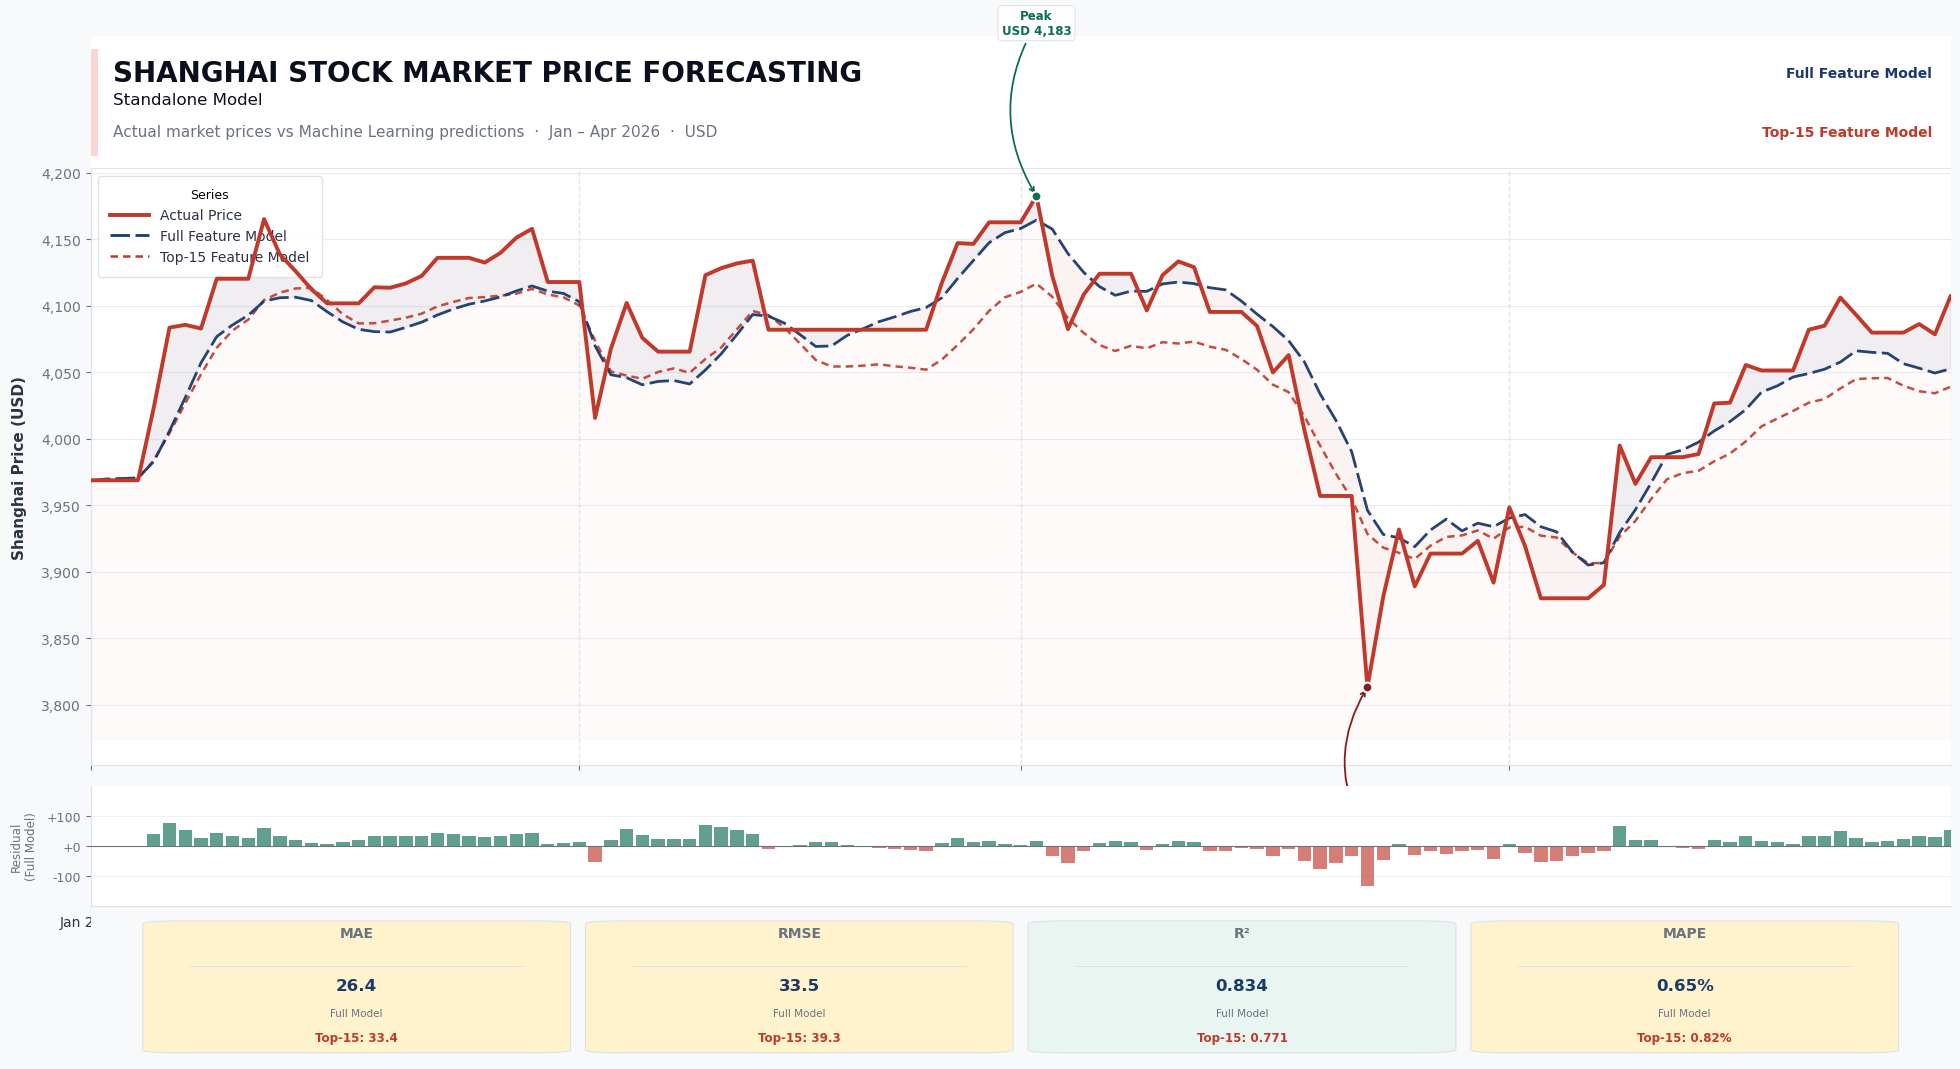

In [116]:
# ── KPI helper ────────────────────────────────────────────────────────────────
def kpis_Shanghai(a, p):
    mae  = np.mean(np.abs(a - p))
    rmse = np.sqrt(np.mean((a - p) ** 2))
    r2   = 1 - np.sum((a - p) ** 2) / np.sum((a - a.mean()) ** 2)
    mape = np.mean(np.abs((a - p) / a)) * 100
    return mae, rmse, r2, mape

plot_df_Shanghai   = test_Shanghai.sort_values('date').copy()
dates_Shanghai     = plot_df_Shanghai['date'].values
actual_Shanghai    = plot_df_Shanghai[target_col_Shanghai].values
full_pred_Shanghai = plot_df_Shanghai['pred_price'].values
top_pred_Shanghai  = plot_df_Shanghai['pred_price_top'].values

mae_f_Shanghai, rmse_f_Shanghai, r2_f_Shanghai, mape_f_Shanghai = kpis_Shanghai(actual_Shanghai, full_pred_Shanghai)
mae_t_Shanghai, rmse_t_Shanghai, r2_t_Shanghai, mape_t_Shanghai = kpis_Shanghai(actual_Shanghai, top_pred_Shanghai)

# ── Palette ───────────────────────────────────────────────────────────────────
PAGE, WHITE, BORDER, GRID = '#F8F9FB', '#FFFFFF', '#DDE1E9', '#EAECF2'
MKT_DARK  = '#C0392B'
MKT_FILL  = '#F9D6D3'
NAVY      = '#1B3A6B'
CRIMSON   = '#C0392B'
TEXT_H, TEXT_B, TEXT_M = '#0A0F1E', '#2C3347', '#6B7280'
GREEN_KPI, GREEN_BG     = '#0B6E4F', '#E8F5F0'
RED_KPI                 = '#8B1A1A'
AMBER_KPI, AMBER_BG     = '#7A4F00', '#FEF3CD'

# ── Figure & layout ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 11), facecolor=PAGE)
outer = gridspec.GridSpec(3, 1, height_ratios=[0.13, 0.72, 0.15],
                          hspace=0, left=0.04, right=0.97, top=0.97, bottom=0.04)

# ── Header band ───────────────────────────────────────────────────────────────
ax_head = fig.add_subplot(outer[0])
ax_head.set_facecolor(WHITE)
ax_head.set_xlim(0, 1); ax_head.set_ylim(0, 1)
for sp in ax_head.spines.values(): sp.set_visible(False)
ax_head.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax_head.add_patch(mpatches.FancyBboxPatch((0, 0.1), 0.004, 0.8,
    boxstyle='square,pad=0', fc=MKT_FILL, ec='none',
    transform=ax_head.transAxes, clip_on=False))
ax_head.text(0.012, 0.72, 'SHANGHAI STOCK MARKET PRICE FORECASTING', transform=ax_head.transAxes,
             fontsize=20, fontweight='bold', color=TEXT_H, va='center')
ax_head.text(0.012, 0.52, 'Standalone Model', transform=ax_head.transAxes,
             fontsize=12, fontweight='normal', color=TEXT_H, va='center')
ax_head.text(0.012, 0.28,
    'Actual market prices vs Machine Learning predictions  ·  Jan – Apr 2026  ·  USD',
    transform=ax_head.transAxes, fontsize=11, color=TEXT_M, va='center')
ax_head.text(0.99, 0.72, 'Full Feature Model', transform=ax_head.transAxes,
             fontsize=10, fontweight='bold', color=NAVY, ha='right', va='center')
ax_head.text(0.99, 0.28, f'Top-{top_k_Shanghai} Feature Model', transform=ax_head.transAxes,
             fontsize=10, fontweight='bold', color=CRIMSON, ha='right', va='center')
ax_head.axhline(0, color=BORDER, linewidth=1.2)

# ── Chart + residual ──────────────────────────────────────────────────────────
inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[1],
                                         height_ratios=[5, 1], hspace=0.06)
ax   = fig.add_subplot(inner[0])
ax_r = fig.add_subplot(inner[1], sharex=ax)

for a in [ax, ax_r]:
    a.set_facecolor(WHITE)
    a.tick_params(colors=TEXT_M, labelsize=10)
    for sp in a.spines.values(): sp.set_edgecolor(BORDER); sp.set_linewidth(0.8)
    a.spines['top'].set_visible(False); a.spines['right'].set_visible(False)

# fills
ax.fill_between(dates_Shanghai, actual_Shanghai, actual_Shanghai.min() - actual_Shanghai.min() * 0.01,
    color=MKT_FILL, alpha=0.12, zorder=1)
ax.fill_between(dates_Shanghai, actual_Shanghai, full_pred_Shanghai,
    where=(actual_Shanghai >= full_pred_Shanghai), color=NAVY,    alpha=0.06, zorder=2, interpolate=True)
ax.fill_between(dates_Shanghai, actual_Shanghai, full_pred_Shanghai,
    where=(actual_Shanghai < full_pred_Shanghai),  color=CRIMSON, alpha=0.06, zorder=2, interpolate=True)

# lines
ax.plot(dates_Shanghai, actual_Shanghai,    color=MKT_DARK, linewidth=2.8, zorder=6,
        solid_capstyle='round', label='Actual Price')
ax.plot(dates_Shanghai, full_pred_Shanghai, color=NAVY,     linewidth=2.0, linestyle=(0,(7,2)),
        zorder=5, alpha=0.95, label='Full Feature Model')
ax.plot(dates_Shanghai, top_pred_Shanghai,  color=CRIMSON,  linewidth=1.8, linestyle=(0,(3,2)),
        zorder=4, alpha=0.90, label=f'Top-{top_k_Shanghai} Feature Model')

# month dividers
for ms in pd.date_range(plot_df_Shanghai['date'].min(), plot_df_Shanghai['date'].max(), freq='MS'):
    ax.axvline(ms, color=BORDER, linewidth=1.0, linestyle='--', alpha=0.9, zorder=1)
ax.set_xlim(dates_Shanghai[0], dates_Shanghai[-1])

# peak & trough annotations
pidx_Shanghai = np.argmax(actual_Shanghai)
pval_Shanghai = actual_Shanghai[pidx_Shanghai]
pdate_Shanghai = dates_Shanghai[pidx_Shanghai]
tidx_Shanghai = np.argmin(actual_Shanghai)
tval_Shanghai = actual_Shanghai[tidx_Shanghai]
tdate_Shanghai = dates_Shanghai[tidx_Shanghai]
offset_Shanghai = actual_Shanghai.mean() * 0.03
for x, y, lbl, col, ya, arc in [
    (pdate_Shanghai, pval_Shanghai, f'Peak\nUSD {pval_Shanghai:,.0f}',   GREEN_KPI, pval_Shanghai + offset_Shanghai,   0.3),
    (tdate_Shanghai, tval_Shanghai, f'Trough\nUSD {tval_Shanghai:,.0f}', RED_KPI,   tval_Shanghai - offset_Shanghai,  -0.3),
]:
    ax.annotate(lbl, xy=(x, y), xytext=(x, ya), color=col,
        fontsize=8.5, fontweight='bold', ha='center',
        arrowprops=dict(arrowstyle='->', color=col,
            connectionstyle=f'arc3,rad={arc}', lw=1.3),
        bbox=dict(boxstyle='round,pad=0.3', fc=WHITE, ec=BORDER, alpha=0.9, lw=0.8),
        zorder=10)
    ax.scatter([x], [y], color=col, s=50, zorder=11, edgecolors=WHITE, linewidths=1.5)

# grid & labels
ax.yaxis.grid(True, color=GRID, linewidth=0.8, zorder=0); ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_ylabel(f'Shanghai Price (USD)', color=TEXT_B, fontsize=11,
              fontweight='bold', labelpad=10)
ax.tick_params(axis='x', labelbottom=False)

ax.legend(handles=[
    Line2D([0], [0], color=MKT_DARK, linewidth=2.8,                      label='Actual Price'),
    Line2D([0], [0], color=NAVY,      linewidth=2.0, linestyle=(0,(7,2)), label='Full Feature Model'),
    Line2D([0], [0], color=CRIMSON,   linewidth=1.8, linestyle=(0,(3,2)), label=f'Top-{top_k_Shanghai} Feature Model'),
], loc='upper left', frameon=True, framealpha=0.95, facecolor=WHITE, edgecolor=BORDER,
   labelcolor=TEXT_B, fontsize=10, borderpad=0.9, handlelength=2.8,
   title='Series', title_fontsize=9)

# residual strip
res_Shanghai = actual_Shanghai - full_pred_Shanghai
ax_r.bar(dates_Shanghai, res_Shanghai,
         color=[GREEN_KPI if v >= 0 else CRIMSON for v in res_Shanghai],
         alpha=0.65, width=0.85, zorder=3)
ax_r.axhline(0, color=TEXT_M, linewidth=0.8, zorder=4)
ax_r.yaxis.grid(True, color=GRID, linewidth=0.5, zorder=0); ax_r.set_axisbelow(True)
ax_r.set_ylabel('Residual\n(Full Model)', color=TEXT_M, fontsize=8.5, labelpad=6)
ax_r.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+,.0f}'))
ax_r.tick_params(colors=TEXT_M, labelsize=9)
pad_Shanghai = max(abs(res_Shanghai.min()), abs(res_Shanghai.max())) * 1.5
ax_r.set_ylim(-pad_Shanghai, pad_Shanghai)
ax_r.xaxis.set_major_locator(mdates.MonthLocator())
ax_r.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax_r.tick_params(axis='x', labelsize=10, colors=TEXT_B)

# ── KPI strip ─────────────────────────────────────────────────────────────────
ax_kpi = fig.add_subplot(outer[2])
ax_kpi.set_facecolor(PAGE); ax_kpi.set_xlim(0, 1); ax_kpi.set_ylim(0, 1)
for sp in ax_kpi.spines.values(): sp.set_visible(False)
ax_kpi.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax_kpi.axhline(1.0, color=BORDER, linewidth=1.0)

kpi_cards_Shanghai = [
    ('MAE',  f'{mae_f_Shanghai:,.1f}',  f'{mae_t_Shanghai:,.1f}',  AMBER_KPI, AMBER_BG),
    ('RMSE', f'{rmse_f_Shanghai:,.1f}', f'{rmse_t_Shanghai:,.1f}', AMBER_KPI, AMBER_BG),
    ('R²',   f'{r2_f_Shanghai:.3f}',    f'{r2_t_Shanghai:.3f}',    GREEN_KPI, GREEN_BG),
    ('MAPE', f'{mape_f_Shanghai:.2f}%', f'{mape_t_Shanghai:.2f}%', AMBER_KPI, AMBER_BG),
]
card_w = 0.19
gap    = (1.0 - len(kpi_cards_Shanghai) * card_w) / (len(kpi_cards_Shanghai) + 1)
for i, (metric, vf, vt, tcol, bgcol) in enumerate(kpi_cards_Shanghai):
    x0 = gap + i * (card_w + gap); xc = x0 + card_w / 2
    ax_kpi.add_patch(mpatches.FancyBboxPatch((x0, 0.06), card_w, 0.82,
        boxstyle='round,pad=0.02', fc=bgcol, ec=BORDER, linewidth=0.8,
        transform=ax_kpi.transAxes, clip_on=False))
    ax_kpi.text(xc, 0.82, metric, transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=10, fontweight='bold', color=TEXT_M)
    ax_kpi.add_patch(mpatches.FancyBboxPatch((x0 + 0.005, 0.60), card_w - 0.01, 0.005,
        boxstyle='square,pad=0', fc=BORDER, ec='none',
        transform=ax_kpi.transAxes, clip_on=False))
    ax_kpi.text(xc, 0.48, vf, transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=12, fontweight='bold', color=NAVY)
    ax_kpi.text(xc, 0.30, 'Full Model', transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=7.5, color=TEXT_M)
    ax_kpi.text(xc, 0.14, f'Top-{top_k_Shanghai}: {vt}', transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=8.5, fontweight='bold', color=CRIMSON)

plt.savefig(ai_data_dir / 'visualizations'/'standalone_Shanghai_price_prediction_model.png',
            dpi=300, bbox_inches='tight', facecolor=PAGE)
plt.show()

<h4 style="color: #CEDDF4;"> 7.23 Shanghai Price Prediction (tomorrow)</h4>

In [117]:
latest_top_Shanghai = X_test_top_Shanghai.iloc[-1:]

pred_return_tomorrow_Shanghai = top_model_Shanghai.predict(latest_top_Shanghai)[0]

last_log_price_Shanghai = np.log(train_Shanghai[target_col_Shanghai].iloc[-1])

pred_price_tomorrow_Shanghai = np.exp(last_log_price_Shanghai + pred_return_tomorrow_Shanghai)

print("Predicted Shanghai Price Tomorrow:", pred_price_tomorrow_Shanghai)

Predicted Shanghai Price Tomorrow: 3973.7448732098583


<h4 style="color: #CEDDF4;">8. Hong Kong Price Prediction</h4>

<h4 style="color: #CEDDF4;"> 8.1 Setup</h4>

In [118]:
# define target variable
target_col_Hong_Kong = 'hongkong_hongkong_price_usd'
# avoid modifying original dataset
df_Hong_Kong = pd.read_csv(ai_data_dir / 'new_master_table.csv')

<h4 style="color: #CEDDF4;"> 8.2 Time preprocessing</h4>

In [119]:
df_Hong_Kong['date'] = pd.to_datetime(df_Hong_Kong['date'], dayfirst=False, format='mixed', errors='coerce')
df_Hong_Kong = df_Hong_Kong.sort_values('date')

<h4 style="color: #CEDDF4;"> 8.3 Remove leakage features</h4>

In [120]:
# ── 1. always-drop keywords (leakage, noise, duplicates) ────────────────────
leakage_keywords_Hong_Kong = [
    '_open_', '_high_', '_low_',     # intraday OHLC leakage on all assets
    '_open',  '_high',  '_low',      # suffix variants
    'gpr_event',                     # forward-looking GPR event flag
    'ai_gpr_Unnamed',                # index artefact
    'gold_price_oz_egp',             # EGP-denominated gold (derived, leaks FX)
    'cbe_inflations_headline_inflation_yy',  # monthly fill creates leakage
    'cbe_inflations_core_inflation_yy',
    '_energy_',                      # all country-level energy mix columns
    'egpusd_value',                  # duplicated by FX cols
    'dollar_historical_data_value',  # duplicated by dollarindex_value
    'cpi_PCPIPCH',                   # duplicate CPI series
]

df_Hong_Kong = df_Hong_Kong.drop(columns=[
    c for c in df_Hong_Kong.columns
    if any(k in c for k in leakage_keywords_Hong_Kong)
], errors='ignore')

# ── 2. drop all OTHER stock market price columns (cross-market leakage) ───────
other_stock_cols_Hong_Kong = [
    'nasdaq_price_usd',
    'nasdaq_high_usd',
    'nasdaq_low_usd',
    'nasdaq_open_usd',
    'sp500_price_usd',
    'sp500_high_usd',
    'sp500_low_usd',
    'sp500_open_usd',
    'dowjones_price_usd',
    'dowjones_high_usd',
    'dowjones_low_usd',
    'dowjones_open_usd',
    'china_shanghai_price_usd',
    'china_shanghai_high_usd',
    'china_shanghai_low_usd',
    'china_shanghai_open_usd',
    'hongkong_hongkong_high_usd',
    'hongkong_hongkong_low_usd',
    'hongkong_hongkong_open_usd',
    'uk_london_price_usd',
    'uk_london_high_usd',
    'uk_london_low_usd',
    'uk_london_open_usd',
    'japan_tokyo_price_usd',
    'japan_tokyo_high_usd',
    'japan_tokyo_low_usd',
    'japan_tokyo_open_usd',
    'egx30_price_egp',
    'egx30_high_price_egp',
    'egx30_low_price_egp',
    'egx30_change_percent',
]

df_Hong_Kong = df_Hong_Kong.drop(columns=[
    c for c in other_stock_cols_Hong_Kong if c in df_Hong_Kong.columns
], errors='ignore')

<h4 style="color: #CEDDF4;"> 8.4 Macro feature engineering</h4>

In [121]:
df_Hong_Kong['real_rate_us'] = df_Hong_Kong['usd_fedfunds_value'] - df_Hong_Kong['cpi_value']            # US real interest rate
df_Hong_Kong['real_rate_eu'] = df_Hong_Kong['euro_interest_value'] - df_Hong_Kong['euro_inflation_value']  # EU real interest rate

df_Hong_Kong['yield_spread_10_2'] = (                                                               # US yield curve spread
    df_Hong_Kong['10y_treasury_historical_data_monthly_value'] -
    df_Hong_Kong['2y_treasury_historical_data_monthly_value']
)
df_Hong_Kong['yield_spread_10_1'] = (                                                               # short-end spread
    df_Hong_Kong['10y_treasury_historical_data_monthly_value'] -
    df_Hong_Kong['1y_treasury_historical_data_monthly_value']
)

df_Hong_Kong['oil_x_dxy']  = df_Hong_Kong['brent_oil_price_usd'] * df_Hong_Kong['dollarindex_value']     # oil × dollar interaction
df_Hong_Kong['vix_x_dxy']  = df_Hong_Kong['vix_price_usd']       * df_Hong_Kong['dollarindex_value']     # volatility × dollar interaction
df_Hong_Kong['gold_x_dxy'] = df_Hong_Kong['gold_price_usd']      * df_Hong_Kong['dollarindex_value']     # gold × dollar interaction

df_Hong_Kong['vix_mom']  = df_Hong_Kong['vix_price_usd'].pct_change()        # VIX momentum (risk-on/off)
df_Hong_Kong['oil_mom']  = df_Hong_Kong['brent_oil_price_usd'].pct_change()  # oil momentum
df_Hong_Kong['gold_mom'] = df_Hong_Kong['gold_price_usd'].pct_change()       # gold momentum

<h4 style="color: #CEDDF4;"> 8.5 Feature engineering</h4>

In [122]:
df_Hong_Kong['log_price'] = np.log(df_Hong_Kong[target_col_Hong_Kong])  # log transformation for stability
df_Hong_Kong['return']    = df_Hong_Kong['log_price'].diff()            # daily log-return

# ── simple moving averages & distance from SMA (trend-following signals) ──────
for w in [5, 10, 20, 50]:
    df_Hong_Kong[f'sma_{w}']          = df_Hong_Kong[target_col_Hong_Kong].rolling(w).mean().shift(1)
    df_Hong_Kong[f'price_vs_sma_{w}'] = (df_Hong_Kong[target_col_Hong_Kong] / df_Hong_Kong[f'sma_{w}'] - 1).shift(1)

# ── RSI-14 (momentum oscillator) ──────────────────────────────────────────────
_delta_Hong_Kong    = df_Hong_Kong['return'].clip(lower=0)
_loss_Hong_Kong     = (-df_Hong_Kong['return']).clip(lower=0)
_avg_gain_Hong_Kong = _delta_Hong_Kong.rolling(14).mean()
_avg_loss_Hong_Kong = _loss_Hong_Kong.rolling(14).mean().replace(0, 1e-9)
df_Hong_Kong['rsi_14'] = (100 - 100 / (1 + _avg_gain_Hong_Kong / _avg_loss_Hong_Kong)).shift(1)

# ── Bollinger Band width (volatility regime signal) ───────────────────────────
_bb_mid_Hong_Kong       = df_Hong_Kong[target_col_Hong_Kong].rolling(20).mean()
_bb_std_Hong_Kong       = df_Hong_Kong[target_col_Hong_Kong].rolling(20).std()
df_Hong_Kong['bb_width']= (4 * _bb_std_Hong_Kong / _bb_mid_Hong_Kong).shift(1)  # normalised bandwidth

# ── calendar features ─────────────────────────────────────────────────────────
df_Hong_Kong['day_of_week']    = df_Hong_Kong['date'].dt.dayofweek    # Mon=0 … Fri=4
df_Hong_Kong['month']          = df_Hong_Kong['date'].dt.month
df_Hong_Kong['quarter']        = df_Hong_Kong['date'].dt.quarter
df_Hong_Kong['is_month_end']   = df_Hong_Kong['date'].dt.is_month_end.astype(int)
df_Hong_Kong['is_quarter_end'] = df_Hong_Kong['date'].dt.is_quarter_end.astype(int)

# ── target: next-day smoothed return (identical to gold/oil model) ────────────
df_Hong_Kong['target'] = df_Hong_Kong['return'].rolling(5).mean().shift(-1)  # future smoothed return target
df_Hong_Kong['target'] = df_Hong_Kong['target'].clip(-0.03, 0.03)            # limit extreme values

<h4 style="color: #CEDDF4;"> 8.6 Lag features</h4>

In [123]:
for lag in [1, 2, 3, 5, 10, 20]:
    df_Hong_Kong[f'return_lag_{lag}'] = df_Hong_Kong['return'].shift(lag)  # past returns

df_Hong_Kong['log_price_lag1'] = df_Hong_Kong['log_price'].shift(1)  # previous price level

# ── lagged macro signals (prevent same-day leakage) ──────────────────────────
df_Hong_Kong['vix_lag1']      = df_Hong_Kong['vix_price_usd'].shift(1)   # yesterday's fear index
df_Hong_Kong['gold_lag1']     = df_Hong_Kong['gold_price_usd'].shift(1)  # yesterday's gold price
df_Hong_Kong['oil_lag1']      = df_Hong_Kong['brent_oil_price_usd'].shift(1)  # yesterday's oil price
df_Hong_Kong['dxy_lag1']      = df_Hong_Kong['dollarindex_value'].shift(1)    # yesterday's dollar index

C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\1555729204.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_Hong_Kong['dxy_lag1']      = df_Hong_Kong['dollarindex_value'].shift(1)    # yesterday's dollar index


<h4 style="color: #CEDDF4;"> 8.7 Volatility and momentum</h4>

In [124]:
df_Hong_Kong['vol_7']         = df_Hong_Kong['return'].rolling(7).std().shift(1)    # short-term realised volatility
df_Hong_Kong['vol_20']        = df_Hong_Kong['return'].rolling(20).std().shift(1)   # medium-term realised volatility
df_Hong_Kong['vol_ratio']     = df_Hong_Kong['vol_7'] / (df_Hong_Kong['vol_20'] + 1e-9)  # vol regime: >1 = expanding

df_Hong_Kong['mom_7']         = df_Hong_Kong['return'].rolling(7).mean().shift(1)   # short-term momentum
df_Hong_Kong['mom_20']        = df_Hong_Kong['return'].rolling(20).mean().shift(1)  # medium-term momentum
df_Hong_Kong['mom_crossover'] = df_Hong_Kong['mom_7'] - df_Hong_Kong['mom_20']           # momentum crossover signal

df_Hong_Kong['price_trend_7'] = df_Hong_Kong[target_col_Hong_Kong].rolling(7).mean().shift(1)   # 7-day price trend
df_Hong_Kong['price_trend_20']= df_Hong_Kong[target_col_Hong_Kong].rolling(20).mean().shift(1)  # 20-day price trend

C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\3119098356.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_Hong_Kong['vol_7']         = df_Hong_Kong['return'].rolling(7).std().shift(1)    # short-term realised volatility
C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\3119098356.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_Hong_Kong['vol_20']        = df_Hong_Kong['return'].rolling(20).std().shift(1)   # medium-term realised volatility
C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\3119098356.py:3: Performan

<h4 style="color: #CEDDF4;"> 8.8 Data cleaning</h4>

In [125]:
df_Hong_Kong = df_Hong_Kong.dropna()  # remove missing values

<h4 style="color: #CEDDF4;"> 8.9 Feature selection</h4>

In [126]:
features_Hong_Kong = [c for c in df_Hong_Kong.columns if c not in ['date', target_col_Hong_Kong, 'target']]  # model inputs

<h4 style="color: #CEDDF4;"> 8.10 Train/test split</h4>

In [127]:
train_Hong_Kong = df_Hong_Kong[df_Hong_Kong['date'] <= '2025-12-31']                                            # training period
test_Hong_Kong  = df_Hong_Kong[(df_Hong_Kong['date'] > '2025-12-31') & (df_Hong_Kong['date'] <= '2026-04-30')]  # testing period

X_train_Hong_Kong = train_Hong_Kong[features_Hong_Kong]
y_train_Hong_Kong = train_Hong_Kong['target']

X_test_Hong_Kong  = test_Hong_Kong[features_Hong_Kong]
y_test_Hong_Kong  = test_Hong_Kong['target']

<h4 style="color: #CEDDF4;"> 8.11 time series Cross-validation</h4>

In [128]:
tscv_Hong_Kong = TimeSeriesSplit(n_splits=5)

for i, (tr, val) in enumerate(tscv_Hong_Kong.split(X_train_Hong_Kong)):

    model_cv_Hong_Kong = lgb.LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.01,
        num_leaves=64,
        max_depth=6,
        verbose=-1
    )

    model_cv_Hong_Kong.fit(X_train_Hong_Kong.iloc[tr], y_train_Hong_Kong.iloc[tr])  # train fold model

    pred_cv_Hong_Kong = model_cv_Hong_Kong.predict(X_train_Hong_Kong.iloc[val])  # validation prediction

    print("Fold", i+1)
    print("MAE:", mean_absolute_error(y_train_Hong_Kong.iloc[val], pred_cv_Hong_Kong))  # error
    print("DIR:", np.mean(np.sign(y_train_Hong_Kong.iloc[val]) == np.sign(pred_cv_Hong_Kong)))  # direction accuracy

Fold 1
MAE: 0.0017071027186526407
DIR: 0.8316666666666667
Fold 2
MAE: 0.0019059319748268545
DIR: 0.845
Fold 3
MAE: 0.0020456011927559967
DIR: 0.865
Fold 4
MAE: 0.002401517869659918
DIR: 0.8333333333333334
Fold 5
MAE: 0.002157796558667478
DIR: 0.8483333333333334


<h4 style="color: #CEDDF4;"> 8.12 Full Model training</h4>

In [129]:
model_Hong_Kong = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

model_Hong_Kong.fit(X_train_Hong_Kong, y_train_Hong_Kong)

,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.01
,n_estimators,3000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


<h4 style="color: #CEDDF4;"> 8.13 Feature selection</h4>

In [130]:
selector_Hong_Kong = SelectFromModel(model_Hong_Kong, threshold='median', prefit=True)

X_train_sel_Hong_Kong = selector_Hong_Kong.transform(X_train_Hong_Kong)
X_test_sel_Hong_Kong  = selector_Hong_Kong.transform(X_test_Hong_Kong)

model_Hong_Kong.fit(X_train_sel_Hong_Kong, y_train_Hong_Kong)

with open(ai_data_dir/'models'/"standalone_hongkong_full_features_model.pkl", "wb") as f:
    pickle.dump(model_Hong_Kong, f)

c:\Users\HMSY\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
c:\Users\HMSY\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


<h4 style="color: #CEDDF4;"> 8.14 Prediction (full model)</h4>

In [131]:
pred_returns_Hong_Kong = model_Hong_Kong.predict(X_test_sel_Hong_Kong)

c:\Users\HMSY\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


<h4 style="color: #CEDDF4;"> 8.15 Price Prediction (full model)</h4>

In [132]:
start_price_Hong_Kong = train_Hong_Kong[target_col_Hong_Kong].iloc[-1]

prices_Hong_Kong = [start_price_Hong_Kong]

for r in pred_returns_Hong_Kong:
    prices_Hong_Kong.append(prices_Hong_Kong[-1] * np.exp(r))

prices_Hong_Kong = prices_Hong_Kong[1:]

test_Hong_Kong = test_Hong_Kong.copy()
test_Hong_Kong['pred_price'] = prices_Hong_Kong

<h4 style="color: #CEDDF4;"> 8.16 Evaluation (full model)</h4>

In [133]:
mae_Hong_Kong       = mean_absolute_error(test_Hong_Kong[target_col_Hong_Kong], test_Hong_Kong['pred_price'])
direction_Hong_Kong = np.mean(np.sign(test_Hong_Kong['target']) == np.sign(pred_returns_Hong_Kong))

print("Full Model MAE:", mae_Hong_Kong)
print("Full Model Direction:", direction_Hong_Kong)

Full Model MAE: 479.00572780188264
Full Model Direction: 0.8151260504201681


<h4 style="color: #CEDDF4;"> 8.17 Top Features Extraction</h4>

In [134]:
importance_model_Hong_Kong = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

importance_model_Hong_Kong.fit(X_train_Hong_Kong, y_train_Hong_Kong)

#model saving into pickle file

#with open(ai_data_dir/"Hong_Kong_top_features_model.pkl", "wb") as f:
    #pickle.dump(importance_model_Hong_Kong, f)

importance_Hong_Kong = pd.Series(
    importance_model_Hong_Kong.feature_importances_,
    index=X_train_Hong_Kong.columns
).sort_values(ascending=False)

<h4 style="color: #CEDDF4;"> 8.18 Top Features selection</h4>

In [135]:
top_k_Hong_Kong        = 15
top_features_Hong_Kong = importance_Hong_Kong.head(top_k_Hong_Kong).index.tolist()

X_train_top_Hong_Kong = X_train_Hong_Kong[top_features_Hong_Kong]
X_test_top_Hong_Kong  = X_test_Hong_Kong[top_features_Hong_Kong]

<h4 style="color: #CEDDF4;"> 8.19 Top model training</h4>

In [136]:
top_model_Hong_Kong = lgb.LGBMRegressor(
    objective='regression',
    boosting_type='gbdt',

    n_estimators=3000,
    learning_rate=0.02,

    num_leaves=128,
    max_depth=10,

    min_child_samples=10,
    min_child_weight=1e-3,

    subsample=0.9,
    subsample_freq=1,

    colsample_bytree=0.9,

    reg_alpha=0.1,
    reg_lambda=0.3,

    random_state=42,
    verbose=-1
)

top_model_Hong_Kong.fit(X_train_top_Hong_Kong, y_train_Hong_Kong)

#model saving into pickle file

with open(ai_data_dir/'models'/"standalone_hongkong_top_features_model.pkl", "wb") as f:
    pickle.dump(top_model_Hong_Kong, f)

pred_top_Hong_Kong = top_model_Hong_Kong.predict(X_test_top_Hong_Kong)

<h4 style="color: #CEDDF4;"> 8.20 Price Prediction (top model)</h4>

In [137]:
prices_top_Hong_Kong = [start_price_Hong_Kong]

for r in pred_top_Hong_Kong:
    prices_top_Hong_Kong.append(prices_top_Hong_Kong[-1] * np.exp(r))

prices_top_Hong_Kong = prices_top_Hong_Kong[1:]

test_Hong_Kong['pred_price_top'] = prices_top_Hong_Kong

<h4 style="color: #CEDDF4;"> 8.21 Evaluation (top model)</h4>

In [138]:
mae_top_Hong_Kong       = mean_absolute_error(test_Hong_Kong[target_col_Hong_Kong], test_Hong_Kong['pred_price_top'])
direction_top_Hong_Kong = np.mean(np.sign(test_Hong_Kong['target']) == np.sign(pred_top_Hong_Kong))

print("Top Features Model MAE:", mae_top_Hong_Kong)
print("Top Features Model Direction:", direction_top_Hong_Kong)

Top Features Model MAE: 395.29427578811067
Top Features Model Direction: 0.8319327731092437


<h4 style="color: #CEDDF4;"> 8.22 Model Comparison Using Visualizations</h4>

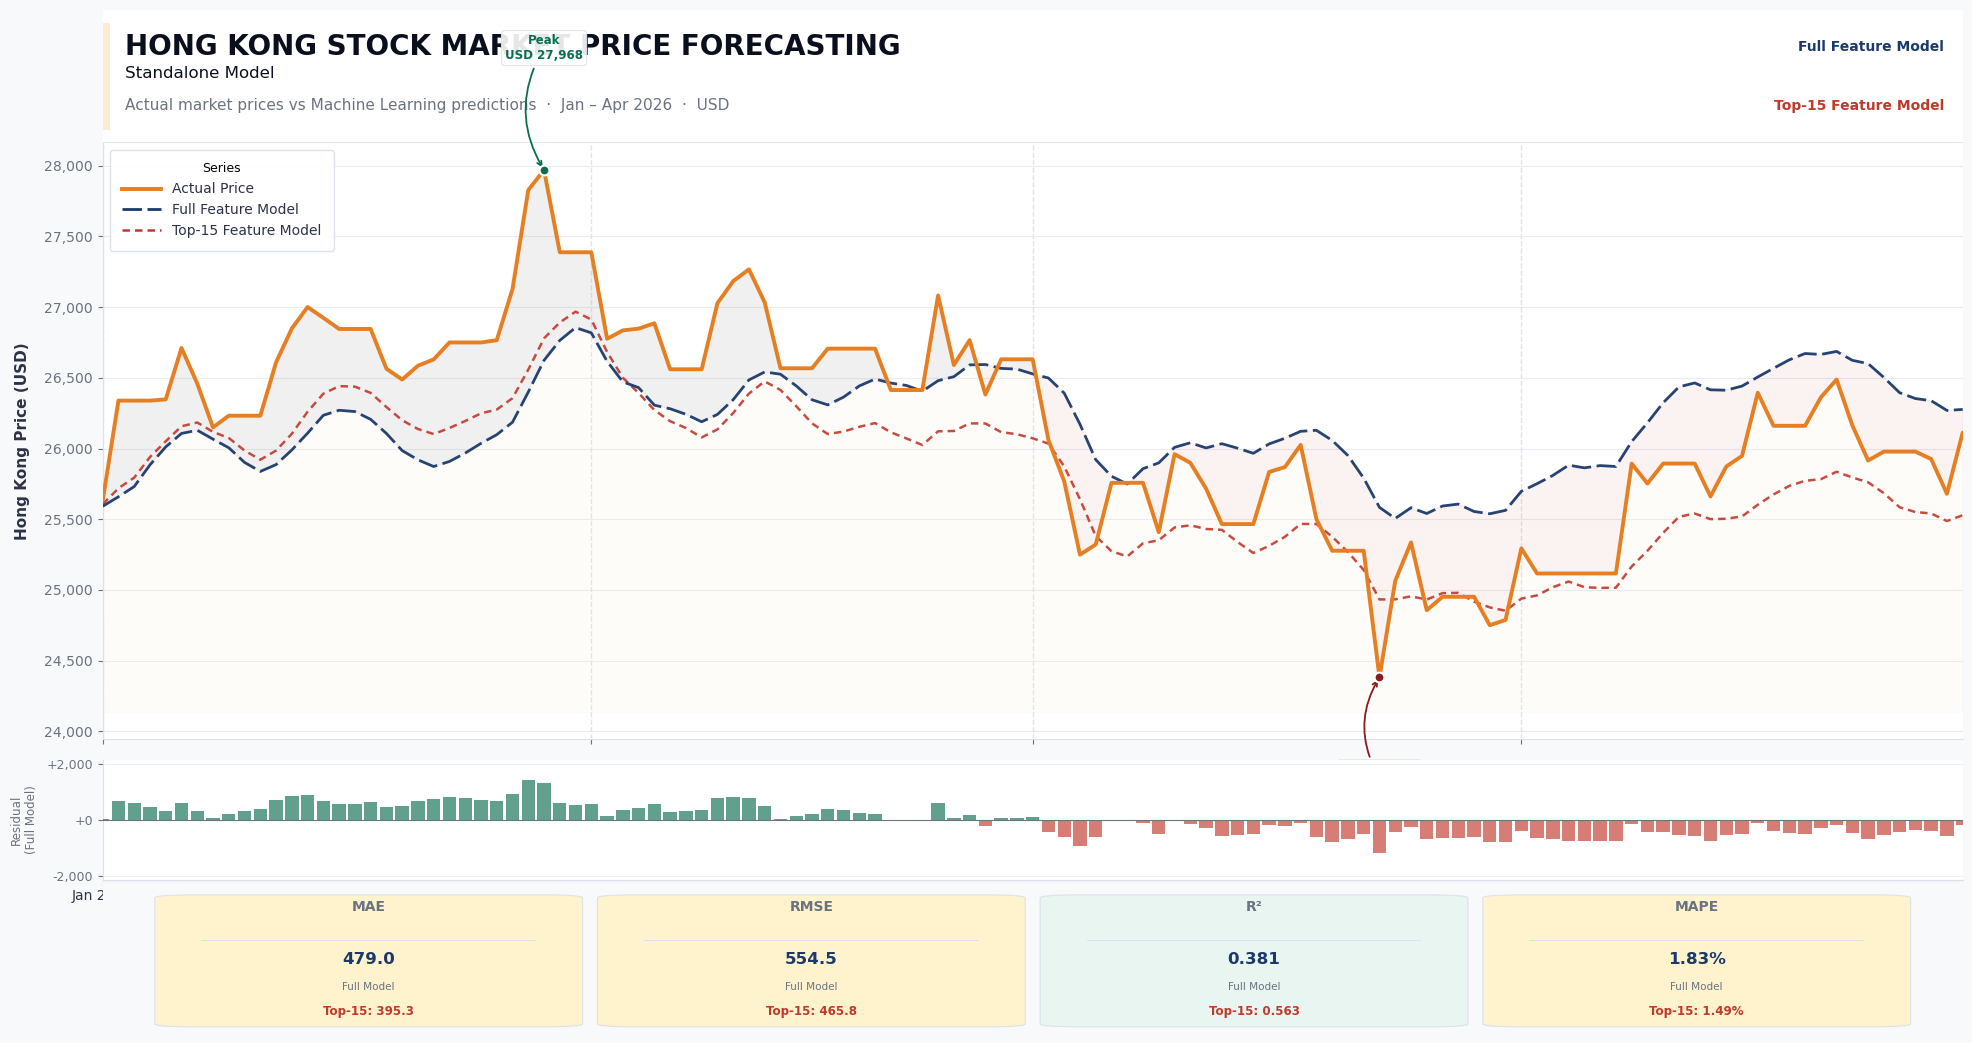

In [139]:
# ── KPI helper ────────────────────────────────────────────────────────────────
def kpis_Hong_Kong(a, p):
    mae  = np.mean(np.abs(a - p))
    rmse = np.sqrt(np.mean((a - p) ** 2))
    r2   = 1 - np.sum((a - p) ** 2) / np.sum((a - a.mean()) ** 2)
    mape = np.mean(np.abs((a - p) / a)) * 100
    return mae, rmse, r2, mape

plot_df_Hong_Kong   = test_Hong_Kong.sort_values('date').copy()
dates_Hong_Kong     = plot_df_Hong_Kong['date'].values
actual_Hong_Kong    = plot_df_Hong_Kong[target_col_Hong_Kong].values
full_pred_Hong_Kong = plot_df_Hong_Kong['pred_price'].values
top_pred_Hong_Kong  = plot_df_Hong_Kong['pred_price_top'].values

mae_f_Hong_Kong, rmse_f_Hong_Kong, r2_f_Hong_Kong, mape_f_Hong_Kong = kpis_Hong_Kong(actual_Hong_Kong, full_pred_Hong_Kong)
mae_t_Hong_Kong, rmse_t_Hong_Kong, r2_t_Hong_Kong, mape_t_Hong_Kong = kpis_Hong_Kong(actual_Hong_Kong, top_pred_Hong_Kong)

# ── Palette ───────────────────────────────────────────────────────────────────
PAGE, WHITE, BORDER, GRID = '#F8F9FB', '#FFFFFF', '#DDE1E9', '#EAECF2'
MKT_DARK  = '#E67E22'
MKT_FILL  = '#FDEBD0'
NAVY      = '#1B3A6B'
CRIMSON   = '#C0392B'
TEXT_H, TEXT_B, TEXT_M = '#0A0F1E', '#2C3347', '#6B7280'
GREEN_KPI, GREEN_BG     = '#0B6E4F', '#E8F5F0'
RED_KPI                 = '#8B1A1A'
AMBER_KPI, AMBER_BG     = '#7A4F00', '#FEF3CD'

# ── Figure & layout ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 11), facecolor=PAGE)
outer = gridspec.GridSpec(3, 1, height_ratios=[0.13, 0.72, 0.15],
                          hspace=0, left=0.04, right=0.97, top=0.97, bottom=0.04)

# ── Header band ───────────────────────────────────────────────────────────────
ax_head = fig.add_subplot(outer[0])
ax_head.set_facecolor(WHITE)
ax_head.set_xlim(0, 1); ax_head.set_ylim(0, 1)
for sp in ax_head.spines.values(): sp.set_visible(False)
ax_head.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax_head.add_patch(mpatches.FancyBboxPatch((0, 0.1), 0.004, 0.8,
    boxstyle='square,pad=0', fc=MKT_FILL, ec='none',
    transform=ax_head.transAxes, clip_on=False))
ax_head.text(0.012, 0.72, 'HONG KONG STOCK MARKET PRICE FORECASTING', transform=ax_head.transAxes,
             fontsize=20, fontweight='bold', color=TEXT_H, va='center')
ax_head.text(0.012, 0.52, 'Standalone Model', transform=ax_head.transAxes,
             fontsize=12, fontweight='normal', color=TEXT_H, va='center')
ax_head.text(0.012, 0.28,
    'Actual market prices vs Machine Learning predictions  ·  Jan – Apr 2026  ·  USD',
    transform=ax_head.transAxes, fontsize=11, color=TEXT_M, va='center')
ax_head.text(0.99, 0.72, 'Full Feature Model', transform=ax_head.transAxes,
             fontsize=10, fontweight='bold', color=NAVY, ha='right', va='center')
ax_head.text(0.99, 0.28, f'Top-{top_k_Hong_Kong} Feature Model', transform=ax_head.transAxes,
             fontsize=10, fontweight='bold', color=CRIMSON, ha='right', va='center')
ax_head.axhline(0, color=BORDER, linewidth=1.2)

# ── Chart + residual ──────────────────────────────────────────────────────────
inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[1],
                                         height_ratios=[5, 1], hspace=0.06)
ax   = fig.add_subplot(inner[0])
ax_r = fig.add_subplot(inner[1], sharex=ax)

for a in [ax, ax_r]:
    a.set_facecolor(WHITE)
    a.tick_params(colors=TEXT_M, labelsize=10)
    for sp in a.spines.values(): sp.set_edgecolor(BORDER); sp.set_linewidth(0.8)
    a.spines['top'].set_visible(False); a.spines['right'].set_visible(False)

# fills
ax.fill_between(dates_Hong_Kong, actual_Hong_Kong, actual_Hong_Kong.min() - actual_Hong_Kong.min() * 0.01,
    color=MKT_FILL, alpha=0.12, zorder=1)
ax.fill_between(dates_Hong_Kong, actual_Hong_Kong, full_pred_Hong_Kong,
    where=(actual_Hong_Kong >= full_pred_Hong_Kong), color=NAVY,    alpha=0.06, zorder=2, interpolate=True)
ax.fill_between(dates_Hong_Kong, actual_Hong_Kong, full_pred_Hong_Kong,
    where=(actual_Hong_Kong < full_pred_Hong_Kong),  color=CRIMSON, alpha=0.06, zorder=2, interpolate=True)

# lines
ax.plot(dates_Hong_Kong, actual_Hong_Kong,    color=MKT_DARK, linewidth=2.8, zorder=6,
        solid_capstyle='round', label='Actual Price')
ax.plot(dates_Hong_Kong, full_pred_Hong_Kong, color=NAVY,     linewidth=2.0, linestyle=(0,(7,2)),
        zorder=5, alpha=0.95, label='Full Feature Model')
ax.plot(dates_Hong_Kong, top_pred_Hong_Kong,  color=CRIMSON,  linewidth=1.8, linestyle=(0,(3,2)),
        zorder=4, alpha=0.90, label=f'Top-{top_k_Hong_Kong} Feature Model')

# month dividers
for ms in pd.date_range(plot_df_Hong_Kong['date'].min(), plot_df_Hong_Kong['date'].max(), freq='MS'):
    ax.axvline(ms, color=BORDER, linewidth=1.0, linestyle='--', alpha=0.9, zorder=1)
ax.set_xlim(dates_Hong_Kong[0], dates_Hong_Kong[-1])

# peak & trough annotations
pidx_Hong_Kong = np.argmax(actual_Hong_Kong)
pval_Hong_Kong = actual_Hong_Kong[pidx_Hong_Kong]
pdate_Hong_Kong = dates_Hong_Kong[pidx_Hong_Kong]
tidx_Hong_Kong = np.argmin(actual_Hong_Kong)
tval_Hong_Kong = actual_Hong_Kong[tidx_Hong_Kong]
tdate_Hong_Kong = dates_Hong_Kong[tidx_Hong_Kong]
offset_Hong_Kong = actual_Hong_Kong.mean() * 0.03
for x, y, lbl, col, ya, arc in [
    (pdate_Hong_Kong, pval_Hong_Kong, f'Peak\nUSD {pval_Hong_Kong:,.0f}',   GREEN_KPI, pval_Hong_Kong + offset_Hong_Kong,   0.3),
    (tdate_Hong_Kong, tval_Hong_Kong, f'Trough\nUSD {tval_Hong_Kong:,.0f}', RED_KPI,   tval_Hong_Kong - offset_Hong_Kong,  -0.3),
]:
    ax.annotate(lbl, xy=(x, y), xytext=(x, ya), color=col,
        fontsize=8.5, fontweight='bold', ha='center',
        arrowprops=dict(arrowstyle='->', color=col,
            connectionstyle=f'arc3,rad={arc}', lw=1.3),
        bbox=dict(boxstyle='round,pad=0.3', fc=WHITE, ec=BORDER, alpha=0.9, lw=0.8),
        zorder=10)
    ax.scatter([x], [y], color=col, s=50, zorder=11, edgecolors=WHITE, linewidths=1.5)

# grid & labels
ax.yaxis.grid(True, color=GRID, linewidth=0.8, zorder=0); ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_ylabel(f'Hong Kong Price (USD)', color=TEXT_B, fontsize=11,
              fontweight='bold', labelpad=10)
ax.tick_params(axis='x', labelbottom=False)

ax.legend(handles=[
    Line2D([0], [0], color=MKT_DARK, linewidth=2.8,                      label='Actual Price'),
    Line2D([0], [0], color=NAVY,      linewidth=2.0, linestyle=(0,(7,2)), label='Full Feature Model'),
    Line2D([0], [0], color=CRIMSON,   linewidth=1.8, linestyle=(0,(3,2)), label=f'Top-{top_k_Hong_Kong} Feature Model'),
], loc='upper left', frameon=True, framealpha=0.95, facecolor=WHITE, edgecolor=BORDER,
   labelcolor=TEXT_B, fontsize=10, borderpad=0.9, handlelength=2.8,
   title='Series', title_fontsize=9)

# residual strip
res_Hong_Kong = actual_Hong_Kong - full_pred_Hong_Kong
ax_r.bar(dates_Hong_Kong, res_Hong_Kong,
         color=[GREEN_KPI if v >= 0 else CRIMSON for v in res_Hong_Kong],
         alpha=0.65, width=0.85, zorder=3)
ax_r.axhline(0, color=TEXT_M, linewidth=0.8, zorder=4)
ax_r.yaxis.grid(True, color=GRID, linewidth=0.5, zorder=0); ax_r.set_axisbelow(True)
ax_r.set_ylabel('Residual\n(Full Model)', color=TEXT_M, fontsize=8.5, labelpad=6)
ax_r.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+,.0f}'))
ax_r.tick_params(colors=TEXT_M, labelsize=9)
pad_Hong_Kong = max(abs(res_Hong_Kong.min()), abs(res_Hong_Kong.max())) * 1.5
ax_r.set_ylim(-pad_Hong_Kong, pad_Hong_Kong)
ax_r.xaxis.set_major_locator(mdates.MonthLocator())
ax_r.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax_r.tick_params(axis='x', labelsize=10, colors=TEXT_B)

# ── KPI strip ─────────────────────────────────────────────────────────────────
ax_kpi = fig.add_subplot(outer[2])
ax_kpi.set_facecolor(PAGE); ax_kpi.set_xlim(0, 1); ax_kpi.set_ylim(0, 1)
for sp in ax_kpi.spines.values(): sp.set_visible(False)
ax_kpi.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax_kpi.axhline(1.0, color=BORDER, linewidth=1.0)

kpi_cards_Hong_Kong = [
    ('MAE',  f'{mae_f_Hong_Kong:,.1f}',  f'{mae_t_Hong_Kong:,.1f}',  AMBER_KPI, AMBER_BG),
    ('RMSE', f'{rmse_f_Hong_Kong:,.1f}', f'{rmse_t_Hong_Kong:,.1f}', AMBER_KPI, AMBER_BG),
    ('R²',   f'{r2_f_Hong_Kong:.3f}',    f'{r2_t_Hong_Kong:.3f}',    GREEN_KPI, GREEN_BG),
    ('MAPE', f'{mape_f_Hong_Kong:.2f}%', f'{mape_t_Hong_Kong:.2f}%', AMBER_KPI, AMBER_BG),
]
card_w = 0.19
gap    = (1.0 - len(kpi_cards_Hong_Kong) * card_w) / (len(kpi_cards_Hong_Kong) + 1)
for i, (metric, vf, vt, tcol, bgcol) in enumerate(kpi_cards_Hong_Kong):
    x0 = gap + i * (card_w + gap); xc = x0 + card_w / 2
    ax_kpi.add_patch(mpatches.FancyBboxPatch((x0, 0.06), card_w, 0.82,
        boxstyle='round,pad=0.02', fc=bgcol, ec=BORDER, linewidth=0.8,
        transform=ax_kpi.transAxes, clip_on=False))
    ax_kpi.text(xc, 0.82, metric, transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=10, fontweight='bold', color=TEXT_M)
    ax_kpi.add_patch(mpatches.FancyBboxPatch((x0 + 0.005, 0.60), card_w - 0.01, 0.005,
        boxstyle='square,pad=0', fc=BORDER, ec='none',
        transform=ax_kpi.transAxes, clip_on=False))
    ax_kpi.text(xc, 0.48, vf, transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=12, fontweight='bold', color=NAVY)
    ax_kpi.text(xc, 0.30, 'Full Model', transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=7.5, color=TEXT_M)
    ax_kpi.text(xc, 0.14, f'Top-{top_k_Hong_Kong}: {vt}', transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=8.5, fontweight='bold', color=CRIMSON)

plt.savefig(ai_data_dir / 'visualizations'/'standalone_Hong_Kong_price_prediction_model.png',
            dpi=300, bbox_inches='tight', facecolor=PAGE)
plt.show()

<h4 style="color: #CEDDF4;"> 8.23 Hong Kong Price Prediction (tomorrow)</h4>

In [140]:
latest_top_Hong_Kong = X_test_top_Hong_Kong.iloc[-1:]

pred_return_tomorrow_Hong_Kong = top_model_Hong_Kong.predict(latest_top_Hong_Kong)[0]

last_log_price_Hong_Kong = np.log(train_Hong_Kong[target_col_Hong_Kong].iloc[-1])

pred_price_tomorrow_Hong_Kong = np.exp(last_log_price_Hong_Kong + pred_return_tomorrow_Hong_Kong)

print("Predicted Hong Kong Price Tomorrow:", pred_price_tomorrow_Hong_Kong)

Predicted Hong Kong Price Tomorrow: 25671.890259845273


<h4 style="color: #CEDDF4;">9. London Price Prediction</h4>

<h4 style="color: #CEDDF4;"> 9.1 Setup</h4>

In [141]:
# define target variable
target_col_London = 'uk_london_price_usd'
# avoid modifying original dataset
df_London = pd.read_csv(ai_data_dir / 'new_master_table.csv')

<h4 style="color: #CEDDF4;"> 9.2 Time preprocessing</h4>

In [142]:
df_London['date'] = pd.to_datetime(df_London['date'], dayfirst=False, format='mixed', errors='coerce')
df_London = df_London.sort_values('date')

<h4 style="color: #CEDDF4;"> 9.3 Remove leakage features</h4>

In [143]:
# ── 1. always-drop keywords (leakage, noise, duplicates) ────────────────────
leakage_keywords_London = [
    '_open_', '_high_', '_low_',     # intraday OHLC leakage on all assets
    '_open',  '_high',  '_low',      # suffix variants
    'gpr_event',                     # forward-looking GPR event flag
    'ai_gpr_Unnamed',                # index artefact
    'gold_price_oz_egp',             # EGP-denominated gold (derived, leaks FX)
    'cbe_inflations_headline_inflation_yy',  # monthly fill creates leakage
    'cbe_inflations_core_inflation_yy',
    '_energy_',                      # all country-level energy mix columns
    'egpusd_value',                  # duplicated by FX cols
    'dollar_historical_data_value',  # duplicated by dollarindex_value
    'cpi_PCPIPCH',                   # duplicate CPI series
]

df_London = df_London.drop(columns=[
    c for c in df_London.columns
    if any(k in c for k in leakage_keywords_London)
], errors='ignore')

# ── 2. drop all OTHER stock market price columns (cross-market leakage) ───────
other_stock_cols_London = [
    'nasdaq_price_usd',
    'nasdaq_high_usd',
    'nasdaq_low_usd',
    'nasdaq_open_usd',
    'sp500_price_usd',
    'sp500_high_usd',
    'sp500_low_usd',
    'sp500_open_usd',
    'dowjones_price_usd',
    'dowjones_high_usd',
    'dowjones_low_usd',
    'dowjones_open_usd',
    'china_shanghai_price_usd',
    'china_shanghai_high_usd',
    'china_shanghai_low_usd',
    'china_shanghai_open_usd',
    'hongkong_hongkong_price_usd',
    'hongkong_hongkong_high_usd',
    'hongkong_hongkong_low_usd',
    'hongkong_hongkong_open_usd',
    'uk_london_high_usd',
    'uk_london_low_usd',
    'uk_london_open_usd',
    'japan_tokyo_price_usd',
    'japan_tokyo_high_usd',
    'japan_tokyo_low_usd',
    'japan_tokyo_open_usd',
    'egx30_price_egp',
    'egx30_high_price_egp',
    'egx30_low_price_egp',
    'egx30_change_percent',
]

df_London = df_London.drop(columns=[
    c for c in other_stock_cols_London if c in df_London.columns
], errors='ignore')

<h4 style="color: #CEDDF4;"> 9.4 Macro feature engineering</h4>

In [144]:
df_London['real_rate_us'] = df_London['usd_fedfunds_value'] - df_London['cpi_value']            # US real interest rate
df_London['real_rate_eu'] = df_London['euro_interest_value'] - df_London['euro_inflation_value']  # EU real interest rate

df_London['yield_spread_10_2'] = (                                                               # US yield curve spread
    df_London['10y_treasury_historical_data_monthly_value'] -
    df_London['2y_treasury_historical_data_monthly_value']
)
df_London['yield_spread_10_1'] = (                                                               # short-end spread
    df_London['10y_treasury_historical_data_monthly_value'] -
    df_London['1y_treasury_historical_data_monthly_value']
)

df_London['oil_x_dxy']  = df_London['brent_oil_price_usd'] * df_London['dollarindex_value']     # oil × dollar interaction
df_London['vix_x_dxy']  = df_London['vix_price_usd']       * df_London['dollarindex_value']     # volatility × dollar interaction
df_London['gold_x_dxy'] = df_London['gold_price_usd']      * df_London['dollarindex_value']     # gold × dollar interaction

df_London['vix_mom']  = df_London['vix_price_usd'].pct_change()        # VIX momentum (risk-on/off)
df_London['oil_mom']  = df_London['brent_oil_price_usd'].pct_change()  # oil momentum
df_London['gold_mom'] = df_London['gold_price_usd'].pct_change()       # gold momentum

<h4 style="color: #CEDDF4;"> 9.5 Feature engineering</h4>

In [145]:
df_London['log_price'] = np.log(df_London[target_col_London])  # log transformation for stability
df_London['return']    = df_London['log_price'].diff()            # daily log-return

# ── simple moving averages & distance from SMA (trend-following signals) ──────
for w in [5, 10, 20, 50]:
    df_London[f'sma_{w}']          = df_London[target_col_London].rolling(w).mean().shift(1)
    df_London[f'price_vs_sma_{w}'] = (df_London[target_col_London] / df_London[f'sma_{w}'] - 1).shift(1)

# ── RSI-14 (momentum oscillator) ──────────────────────────────────────────────
_delta_London    = df_London['return'].clip(lower=0)
_loss_London     = (-df_London['return']).clip(lower=0)
_avg_gain_London = _delta_London.rolling(14).mean()
_avg_loss_London = _loss_London.rolling(14).mean().replace(0, 1e-9)
df_London['rsi_14'] = (100 - 100 / (1 + _avg_gain_London / _avg_loss_London)).shift(1)

# ── Bollinger Band width (volatility regime signal) ───────────────────────────
_bb_mid_London       = df_London[target_col_London].rolling(20).mean()
_bb_std_London       = df_London[target_col_London].rolling(20).std()
df_London['bb_width']= (4 * _bb_std_London / _bb_mid_London).shift(1)  # normalised bandwidth

# ── calendar features ─────────────────────────────────────────────────────────
df_London['day_of_week']    = df_London['date'].dt.dayofweek    # Mon=0 … Fri=4
df_London['month']          = df_London['date'].dt.month
df_London['quarter']        = df_London['date'].dt.quarter
df_London['is_month_end']   = df_London['date'].dt.is_month_end.astype(int)
df_London['is_quarter_end'] = df_London['date'].dt.is_quarter_end.astype(int)

# ── target: next-day smoothed return (identical to gold/oil model) ────────────
df_London['target'] = df_London['return'].rolling(5).mean().shift(-1)  # future smoothed return target
df_London['target'] = df_London['target'].clip(-0.03, 0.03)            # limit extreme values

<h4 style="color: #CEDDF4;"> 9.6 Lag features</h4>

In [146]:
for lag in [1, 2, 3, 5, 10, 20]:
    df_London[f'return_lag_{lag}'] = df_London['return'].shift(lag)  # past returns

df_London['log_price_lag1'] = df_London['log_price'].shift(1)  # previous price level

# ── lagged macro signals (prevent same-day leakage) ──────────────────────────
df_London['vix_lag1']      = df_London['vix_price_usd'].shift(1)   # yesterday's fear index
df_London['gold_lag1']     = df_London['gold_price_usd'].shift(1)  # yesterday's gold price
df_London['oil_lag1']      = df_London['brent_oil_price_usd'].shift(1)  # yesterday's oil price
df_London['dxy_lag1']      = df_London['dollarindex_value'].shift(1)    # yesterday's dollar index

C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\823403269.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_London['dxy_lag1']      = df_London['dollarindex_value'].shift(1)    # yesterday's dollar index


<h4 style="color: #CEDDF4;"> 9.7 Volatility and momentum</h4>

In [147]:
df_London['vol_7']         = df_London['return'].rolling(7).std().shift(1)    # short-term realised volatility
df_London['vol_20']        = df_London['return'].rolling(20).std().shift(1)   # medium-term realised volatility
df_London['vol_ratio']     = df_London['vol_7'] / (df_London['vol_20'] + 1e-9)  # vol regime: >1 = expanding

df_London['mom_7']         = df_London['return'].rolling(7).mean().shift(1)   # short-term momentum
df_London['mom_20']        = df_London['return'].rolling(20).mean().shift(1)  # medium-term momentum
df_London['mom_crossover'] = df_London['mom_7'] - df_London['mom_20']           # momentum crossover signal

df_London['price_trend_7'] = df_London[target_col_London].rolling(7).mean().shift(1)   # 7-day price trend
df_London['price_trend_20']= df_London[target_col_London].rolling(20).mean().shift(1)  # 20-day price trend

C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\1088880892.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_London['vol_7']         = df_London['return'].rolling(7).std().shift(1)    # short-term realised volatility
C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\1088880892.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_London['vol_20']        = df_London['return'].rolling(20).std().shift(1)   # medium-term realised volatility
C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\1088880892.py:3: PerformanceWarning: D

<h4 style="color: #CEDDF4;"> 9.8 Data cleaning</h4>

In [148]:
df_London = df_London.dropna()  # remove missing values

<h4 style="color: #CEDDF4;"> 9.9 Feature selection</h4>

In [149]:
features_London = [c for c in df_London.columns if c not in ['date', target_col_London, 'target']]  # model inputs

<h4 style="color: #CEDDF4;"> 9.10 Train/test split</h4>

In [150]:
train_London = df_London[df_London['date'] <= '2025-12-31']                                            # training period
test_London  = df_London[(df_London['date'] > '2025-12-31') & (df_London['date'] <= '2026-04-30')]  # testing period

X_train_London = train_London[features_London]
y_train_London = train_London['target']

X_test_London  = test_London[features_London]
y_test_London  = test_London['target']

<h4 style="color: #CEDDF4;"> 9.11 time series Cross-validation</h4>

In [151]:
tscv_London = TimeSeriesSplit(n_splits=5)

for i, (tr, val) in enumerate(tscv_London.split(X_train_London)):

    model_cv_London = lgb.LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.01,
        num_leaves=64,
        max_depth=6,
        verbose=-1
    )

    model_cv_London.fit(X_train_London.iloc[tr], y_train_London.iloc[tr])  # train fold model

    pred_cv_London = model_cv_London.predict(X_train_London.iloc[val])  # validation prediction

    print("Fold", i+1)
    print("MAE:", mean_absolute_error(y_train_London.iloc[val], pred_cv_London))  # error
    print("DIR:", np.mean(np.sign(y_train_London.iloc[val]) == np.sign(pred_cv_London)))  # direction accuracy

Fold 1
MAE: 0.0011005592143227374
DIR: 0.835
Fold 2
MAE: 0.0024492005929670217
DIR: 0.7916666666666666
Fold 3
MAE: 0.0012487572117433742
DIR: 0.83
Fold 4
MAE: 0.0012822532211677346
DIR: 0.7766666666666666
Fold 5
MAE: 0.0008894896328618181
DIR: 0.83


<h4 style="color: #CEDDF4;"> 9.12 Full Model training</h4>

In [152]:
model_London = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

model_London.fit(X_train_London, y_train_London)

,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.01
,n_estimators,3000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


<h4 style="color: #CEDDF4;"> 9.13 Feature selection</h4>

In [153]:
selector_London = SelectFromModel(model_London, threshold='median', prefit=True)

X_train_sel_London = selector_London.transform(X_train_London)
X_test_sel_London  = selector_London.transform(X_test_London)

model_London.fit(X_train_sel_London, y_train_London)

with open(ai_data_dir/'models'/"standalone_london_full_features_model.pkl", "wb") as f:
    pickle.dump(model_London, f)

c:\Users\HMSY\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
c:\Users\HMSY\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


<h4 style="color: #CEDDF4;"> 9.14 Prediction (full model)</h4>

In [154]:
pred_returns_London = model_London.predict(X_test_sel_London)

c:\Users\HMSY\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


<h4 style="color: #CEDDF4;"> 9.15 Price Prediction (full model)</h4>

In [155]:
start_price_London = train_London[target_col_London].iloc[-1]

prices_London = [start_price_London]

for r in pred_returns_London:
    prices_London.append(prices_London[-1] * np.exp(r))

prices_London = prices_London[1:]

test_London = test_London.copy()
test_London['pred_price'] = prices_London

<h4 style="color: #CEDDF4;"> 9.16 Evaluation (full model)</h4>

In [156]:
mae_London       = mean_absolute_error(test_London[target_col_London], test_London['pred_price'])
direction_London = np.mean(np.sign(test_London['target']) == np.sign(pred_returns_London))

print("Full Model MAE:", mae_London)
print("Full Model Direction:", direction_London)

Full Model MAE: 186.23977198879552
Full Model Direction: 0.8571428571428571


<h4 style="color: #CEDDF4;"> 9.17 Top Features Extraction</h4>

In [157]:
importance_model_London = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

importance_model_London.fit(X_train_London, y_train_London)

#model saving into pickle file

#with open(ai_data_dir/"London_top_features_model.pkl", "wb") as f:
    #pickle.dump(importance_model_London, f)

importance_London = pd.Series(
    importance_model_London.feature_importances_,
    index=X_train_London.columns
).sort_values(ascending=False)

<h4 style="color: #CEDDF4;"> 9.18 Top Features selection</h4>

In [158]:
top_k_London        = 15
top_features_London = importance_London.head(top_k_London).index.tolist()

X_train_top_London = X_train_London[top_features_London]
X_test_top_London  = X_test_London[top_features_London]

<h4 style="color: #CEDDF4;"> 9.19 Top model training</h4>

In [159]:
top_model_London = lgb.LGBMRegressor(
    objective='regression',
    boosting_type='gbdt',

    n_estimators=3000,
    learning_rate=0.02,

    num_leaves=128,
    max_depth=10,

    min_child_samples=10,
    min_child_weight=1e-3,

    subsample=0.9,
    subsample_freq=1,

    colsample_bytree=0.9,

    reg_alpha=0.1,
    reg_lambda=0.3,

    random_state=42,
    verbose=-1
)

top_model_London.fit(X_train_top_London, y_train_London)

#model saving into pickle file

with open(ai_data_dir/'models'/"standalone_london_top_features_model.pkl", "wb") as f:
    pickle.dump(top_model_London, f)

pred_top_London = top_model_London.predict(X_test_top_London)

<h4 style="color: #CEDDF4;"> 9.20 Price Prediction (top model)</h4>

In [160]:
prices_top_London = [start_price_London]

for r in pred_top_London:
    prices_top_London.append(prices_top_London[-1] * np.exp(r))

prices_top_London = prices_top_London[1:]

test_London['pred_price_top'] = prices_top_London

<h4 style="color: #CEDDF4;"> 9.21 Evaluation (top model)</h4>

In [161]:
mae_top_London       = mean_absolute_error(test_London[target_col_London], test_London['pred_price_top'])
direction_top_London = np.mean(np.sign(test_London['target']) == np.sign(pred_top_London))

print("Top Features Model MAE:", mae_top_London)
print("Top Features Model Direction:", direction_top_London)

Top Features Model MAE: 81.56460542783194
Top Features Model Direction: 0.8571428571428571


<h4 style="color: #CEDDF4;"> 9.22 Model Comparison Using Visualizations</h4>

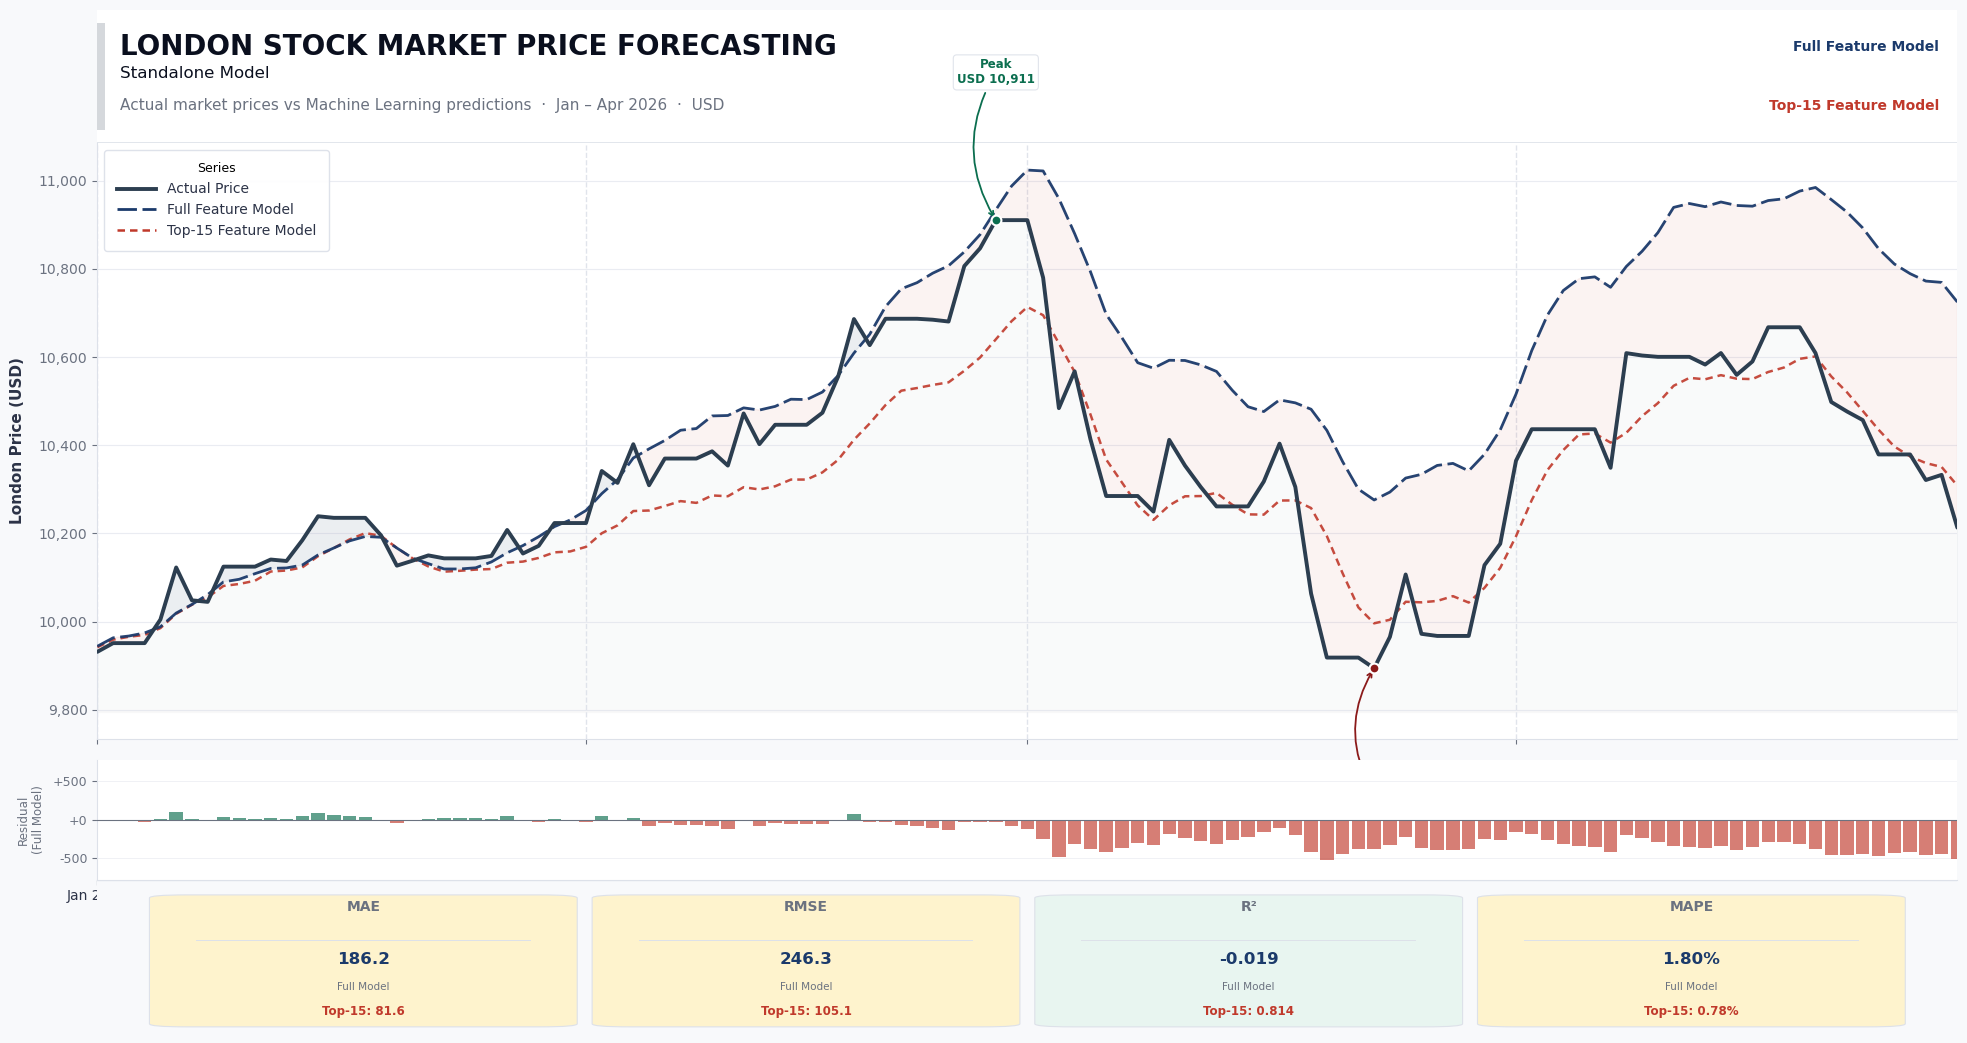

In [162]:
# ── KPI helper ────────────────────────────────────────────────────────────────
def kpis_London(a, p):
    mae  = np.mean(np.abs(a - p))
    rmse = np.sqrt(np.mean((a - p) ** 2))
    r2   = 1 - np.sum((a - p) ** 2) / np.sum((a - a.mean()) ** 2)
    mape = np.mean(np.abs((a - p) / a)) * 100
    return mae, rmse, r2, mape

plot_df_London   = test_London.sort_values('date').copy()
dates_London     = plot_df_London['date'].values
actual_London    = plot_df_London[target_col_London].values
full_pred_London = plot_df_London['pred_price'].values
top_pred_London  = plot_df_London['pred_price_top'].values

mae_f_London, rmse_f_London, r2_f_London, mape_f_London = kpis_London(actual_London, full_pred_London)
mae_t_London, rmse_t_London, r2_t_London, mape_t_London = kpis_London(actual_London, top_pred_London)

# ── Palette ───────────────────────────────────────────────────────────────────
PAGE, WHITE, BORDER, GRID = '#F8F9FB', '#FFFFFF', '#DDE1E9', '#EAECF2'
MKT_DARK  = '#2C3E50'
MKT_FILL  = '#D5D8DC'
NAVY      = '#1B3A6B'
CRIMSON   = '#C0392B'
TEXT_H, TEXT_B, TEXT_M = '#0A0F1E', '#2C3347', '#6B7280'
GREEN_KPI, GREEN_BG     = '#0B6E4F', '#E8F5F0'
RED_KPI                 = '#8B1A1A'
AMBER_KPI, AMBER_BG     = '#7A4F00', '#FEF3CD'

# ── Figure & layout ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 11), facecolor=PAGE)
outer = gridspec.GridSpec(3, 1, height_ratios=[0.13, 0.72, 0.15],
                          hspace=0, left=0.04, right=0.97, top=0.97, bottom=0.04)

# ── Header band ───────────────────────────────────────────────────────────────
ax_head = fig.add_subplot(outer[0])
ax_head.set_facecolor(WHITE)
ax_head.set_xlim(0, 1); ax_head.set_ylim(0, 1)
for sp in ax_head.spines.values(): sp.set_visible(False)
ax_head.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax_head.add_patch(mpatches.FancyBboxPatch((0, 0.1), 0.004, 0.8,
    boxstyle='square,pad=0', fc=MKT_FILL, ec='none',
    transform=ax_head.transAxes, clip_on=False))
ax_head.text(0.012, 0.72, 'LONDON STOCK MARKET PRICE FORECASTING', transform=ax_head.transAxes,
             fontsize=20, fontweight='bold', color=TEXT_H, va='center')
ax_head.text(0.012, 0.52, 'Standalone Model', transform=ax_head.transAxes,
             fontsize=12, fontweight='normal', color=TEXT_H, va='center')
ax_head.text(0.012, 0.28,
    'Actual market prices vs Machine Learning predictions  ·  Jan – Apr 2026  ·  USD',
    transform=ax_head.transAxes, fontsize=11, color=TEXT_M, va='center')
ax_head.text(0.99, 0.72, 'Full Feature Model', transform=ax_head.transAxes,
             fontsize=10, fontweight='bold', color=NAVY, ha='right', va='center')
ax_head.text(0.99, 0.28, f'Top-{top_k_London} Feature Model', transform=ax_head.transAxes,
             fontsize=10, fontweight='bold', color=CRIMSON, ha='right', va='center')
ax_head.axhline(0, color=BORDER, linewidth=1.2)

# ── Chart + residual ──────────────────────────────────────────────────────────
inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[1],
                                         height_ratios=[5, 1], hspace=0.06)
ax   = fig.add_subplot(inner[0])
ax_r = fig.add_subplot(inner[1], sharex=ax)

for a in [ax, ax_r]:
    a.set_facecolor(WHITE)
    a.tick_params(colors=TEXT_M, labelsize=10)
    for sp in a.spines.values(): sp.set_edgecolor(BORDER); sp.set_linewidth(0.8)
    a.spines['top'].set_visible(False); a.spines['right'].set_visible(False)

# fills
ax.fill_between(dates_London, actual_London, actual_London.min() - actual_London.min() * 0.01,
    color=MKT_FILL, alpha=0.12, zorder=1)
ax.fill_between(dates_London, actual_London, full_pred_London,
    where=(actual_London >= full_pred_London), color=NAVY,    alpha=0.06, zorder=2, interpolate=True)
ax.fill_between(dates_London, actual_London, full_pred_London,
    where=(actual_London < full_pred_London),  color=CRIMSON, alpha=0.06, zorder=2, interpolate=True)

# lines
ax.plot(dates_London, actual_London,    color=MKT_DARK, linewidth=2.8, zorder=6,
        solid_capstyle='round', label='Actual Price')
ax.plot(dates_London, full_pred_London, color=NAVY,     linewidth=2.0, linestyle=(0,(7,2)),
        zorder=5, alpha=0.95, label='Full Feature Model')
ax.plot(dates_London, top_pred_London,  color=CRIMSON,  linewidth=1.8, linestyle=(0,(3,2)),
        zorder=4, alpha=0.90, label=f'Top-{top_k_London} Feature Model')

# month dividers
for ms in pd.date_range(plot_df_London['date'].min(), plot_df_London['date'].max(), freq='MS'):
    ax.axvline(ms, color=BORDER, linewidth=1.0, linestyle='--', alpha=0.9, zorder=1)
ax.set_xlim(dates_London[0], dates_London[-1])

# peak & trough annotations
pidx_London = np.argmax(actual_London)
pval_London = actual_London[pidx_London]
pdate_London = dates_London[pidx_London]
tidx_London = np.argmin(actual_London)
tval_London = actual_London[tidx_London]
tdate_London = dates_London[tidx_London]
offset_London = actual_London.mean() * 0.03
for x, y, lbl, col, ya, arc in [
    (pdate_London, pval_London, f'Peak\nUSD {pval_London:,.0f}',   GREEN_KPI, pval_London + offset_London,   0.3),
    (tdate_London, tval_London, f'Trough\nUSD {tval_London:,.0f}', RED_KPI,   tval_London - offset_London,  -0.3),
]:
    ax.annotate(lbl, xy=(x, y), xytext=(x, ya), color=col,
        fontsize=8.5, fontweight='bold', ha='center',
        arrowprops=dict(arrowstyle='->', color=col,
            connectionstyle=f'arc3,rad={arc}', lw=1.3),
        bbox=dict(boxstyle='round,pad=0.3', fc=WHITE, ec=BORDER, alpha=0.9, lw=0.8),
        zorder=10)
    ax.scatter([x], [y], color=col, s=50, zorder=11, edgecolors=WHITE, linewidths=1.5)

# grid & labels
ax.yaxis.grid(True, color=GRID, linewidth=0.8, zorder=0); ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_ylabel(f'London Price (USD)', color=TEXT_B, fontsize=11,
              fontweight='bold', labelpad=10)
ax.tick_params(axis='x', labelbottom=False)

ax.legend(handles=[
    Line2D([0], [0], color=MKT_DARK, linewidth=2.8,                      label='Actual Price'),
    Line2D([0], [0], color=NAVY,      linewidth=2.0, linestyle=(0,(7,2)), label='Full Feature Model'),
    Line2D([0], [0], color=CRIMSON,   linewidth=1.8, linestyle=(0,(3,2)), label=f'Top-{top_k_London} Feature Model'),
], loc='upper left', frameon=True, framealpha=0.95, facecolor=WHITE, edgecolor=BORDER,
   labelcolor=TEXT_B, fontsize=10, borderpad=0.9, handlelength=2.8,
   title='Series', title_fontsize=9)

# residual strip
res_London = actual_London - full_pred_London
ax_r.bar(dates_London, res_London,
         color=[GREEN_KPI if v >= 0 else CRIMSON for v in res_London],
         alpha=0.65, width=0.85, zorder=3)
ax_r.axhline(0, color=TEXT_M, linewidth=0.8, zorder=4)
ax_r.yaxis.grid(True, color=GRID, linewidth=0.5, zorder=0); ax_r.set_axisbelow(True)
ax_r.set_ylabel('Residual\n(Full Model)', color=TEXT_M, fontsize=8.5, labelpad=6)
ax_r.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+,.0f}'))
ax_r.tick_params(colors=TEXT_M, labelsize=9)
pad_London = max(abs(res_London.min()), abs(res_London.max())) * 1.5
ax_r.set_ylim(-pad_London, pad_London)
ax_r.xaxis.set_major_locator(mdates.MonthLocator())
ax_r.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax_r.tick_params(axis='x', labelsize=10, colors=TEXT_B)

# ── KPI strip ─────────────────────────────────────────────────────────────────
ax_kpi = fig.add_subplot(outer[2])
ax_kpi.set_facecolor(PAGE); ax_kpi.set_xlim(0, 1); ax_kpi.set_ylim(0, 1)
for sp in ax_kpi.spines.values(): sp.set_visible(False)
ax_kpi.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax_kpi.axhline(1.0, color=BORDER, linewidth=1.0)

kpi_cards_London = [
    ('MAE',  f'{mae_f_London:,.1f}',  f'{mae_t_London:,.1f}',  AMBER_KPI, AMBER_BG),
    ('RMSE', f'{rmse_f_London:,.1f}', f'{rmse_t_London:,.1f}', AMBER_KPI, AMBER_BG),
    ('R²',   f'{r2_f_London:.3f}',    f'{r2_t_London:.3f}',    GREEN_KPI, GREEN_BG),
    ('MAPE', f'{mape_f_London:.2f}%', f'{mape_t_London:.2f}%', AMBER_KPI, AMBER_BG),
]
card_w = 0.19
gap    = (1.0 - len(kpi_cards_London) * card_w) / (len(kpi_cards_London) + 1)
for i, (metric, vf, vt, tcol, bgcol) in enumerate(kpi_cards_London):
    x0 = gap + i * (card_w + gap); xc = x0 + card_w / 2
    ax_kpi.add_patch(mpatches.FancyBboxPatch((x0, 0.06), card_w, 0.82,
        boxstyle='round,pad=0.02', fc=bgcol, ec=BORDER, linewidth=0.8,
        transform=ax_kpi.transAxes, clip_on=False))
    ax_kpi.text(xc, 0.82, metric, transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=10, fontweight='bold', color=TEXT_M)
    ax_kpi.add_patch(mpatches.FancyBboxPatch((x0 + 0.005, 0.60), card_w - 0.01, 0.005,
        boxstyle='square,pad=0', fc=BORDER, ec='none',
        transform=ax_kpi.transAxes, clip_on=False))
    ax_kpi.text(xc, 0.48, vf, transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=12, fontweight='bold', color=NAVY)
    ax_kpi.text(xc, 0.30, 'Full Model', transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=7.5, color=TEXT_M)
    ax_kpi.text(xc, 0.14, f'Top-{top_k_London}: {vt}', transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=8.5, fontweight='bold', color=CRIMSON)

plt.savefig(ai_data_dir / 'visualizations'/'standalone_London_price_prediction_model.png',
            dpi=300, bbox_inches='tight', facecolor=PAGE)
plt.show()

<h4 style="color: #CEDDF4;"> 9.23 London Price Prediction (tomorrow)</h4>

In [163]:
latest_top_London = X_test_top_London.iloc[-1:]

pred_return_tomorrow_London = top_model_London.predict(latest_top_London)[0]

last_log_price_London = np.log(train_London[target_col_London].iloc[-1])

pred_price_tomorrow_London = np.exp(last_log_price_London + pred_return_tomorrow_London)

print("Predicted London Price Tomorrow:", pred_price_tomorrow_London)

Predicted London Price Tomorrow: 9890.651208902415


<h4 style="color: #CEDDF4;">10. Tokyo Price Prediction</h4>

<h4 style="color: #CEDDF4;"> 10.1 Setup</h4>

In [164]:
# define target variable
target_col_Tokyo = 'japan_tokyo_price_usd'
# avoid modifying original dataset
df_Tokyo = pd.read_csv(ai_data_dir / 'new_master_table.csv')

<h4 style="color: #CEDDF4;"> 10.2 Time preprocessing</h4>

In [165]:
df_Tokyo['date'] = pd.to_datetime(df_Tokyo['date'], dayfirst=False, format='mixed', errors='coerce')
df_Tokyo = df_Tokyo.sort_values('date')

<h4 style="color: #CEDDF4;"> 10.3 Remove leakage features</h4>

In [166]:
# ── 1. always-drop keywords (leakage, noise, duplicates) ────────────────────
leakage_keywords_Tokyo = [
    '_open_', '_high_', '_low_',     # intraday OHLC leakage on all assets
    '_open',  '_high',  '_low',      # suffix variants
    'gpr_event',                     # forward-looking GPR event flag
    'ai_gpr_Unnamed',                # index artefact
    'gold_price_oz_egp',             # EGP-denominated gold (derived, leaks FX)
    'cbe_inflations_headline_inflation_yy',  # monthly fill creates leakage
    'cbe_inflations_core_inflation_yy',
    '_energy_',                      # all country-level energy mix columns
    'egpusd_value',                  # duplicated by FX cols
    'dollar_historical_data_value',  # duplicated by dollarindex_value
    'cpi_PCPIPCH',                   # duplicate CPI series
]

df_Tokyo = df_Tokyo.drop(columns=[
    c for c in df_Tokyo.columns
    if any(k in c for k in leakage_keywords_Tokyo)
], errors='ignore')

# ── 2. drop all OTHER stock market price columns (cross-market leakage) ───────
other_stock_cols_Tokyo = [
    'nasdaq_price_usd',
    'nasdaq_high_usd',
    'nasdaq_low_usd',
    'nasdaq_open_usd',
    'sp500_price_usd',
    'sp500_high_usd',
    'sp500_low_usd',
    'sp500_open_usd',
    'dowjones_price_usd',
    'dowjones_high_usd',
    'dowjones_low_usd',
    'dowjones_open_usd',
    'china_shanghai_price_usd',
    'china_shanghai_high_usd',
    'china_shanghai_low_usd',
    'china_shanghai_open_usd',
    'hongkong_hongkong_price_usd',
    'hongkong_hongkong_high_usd',
    'hongkong_hongkong_low_usd',
    'hongkong_hongkong_open_usd',
    'uk_london_price_usd',
    'uk_london_high_usd',
    'uk_london_low_usd',
    'uk_london_open_usd',
    'japan_tokyo_high_usd',
    'japan_tokyo_low_usd',
    'japan_tokyo_open_usd',
    'egx30_price_egp',
    'egx30_high_price_egp',
    'egx30_low_price_egp',
    'egx30_change_percent',
]

df_Tokyo = df_Tokyo.drop(columns=[
    c for c in other_stock_cols_Tokyo if c in df_Tokyo.columns
], errors='ignore')

<h4 style="color: #CEDDF4;"> 10.4 Macro feature engineering</h4>

In [167]:
df_Tokyo['real_rate_us'] = df_Tokyo['usd_fedfunds_value'] - df_Tokyo['cpi_value']            # US real interest rate
df_Tokyo['real_rate_eu'] = df_Tokyo['euro_interest_value'] - df_Tokyo['euro_inflation_value']  # EU real interest rate

df_Tokyo['yield_spread_10_2'] = (                                                               # US yield curve spread
    df_Tokyo['10y_treasury_historical_data_monthly_value'] -
    df_Tokyo['2y_treasury_historical_data_monthly_value']
)
df_Tokyo['yield_spread_10_1'] = (                                                               # short-end spread
    df_Tokyo['10y_treasury_historical_data_monthly_value'] -
    df_Tokyo['1y_treasury_historical_data_monthly_value']
)

df_Tokyo['oil_x_dxy']  = df_Tokyo['brent_oil_price_usd'] * df_Tokyo['dollarindex_value']     # oil × dollar interaction
df_Tokyo['vix_x_dxy']  = df_Tokyo['vix_price_usd']       * df_Tokyo['dollarindex_value']     # volatility × dollar interaction
df_Tokyo['gold_x_dxy'] = df_Tokyo['gold_price_usd']      * df_Tokyo['dollarindex_value']     # gold × dollar interaction

df_Tokyo['vix_mom']  = df_Tokyo['vix_price_usd'].pct_change()        # VIX momentum (risk-on/off)
df_Tokyo['oil_mom']  = df_Tokyo['brent_oil_price_usd'].pct_change()  # oil momentum
df_Tokyo['gold_mom'] = df_Tokyo['gold_price_usd'].pct_change()       # gold momentum

<h4 style="color: #CEDDF4;"> 10.5 Feature engineering</h4>

In [168]:
df_Tokyo['log_price'] = np.log(df_Tokyo[target_col_Tokyo])  # log transformation for stability
df_Tokyo['return']    = df_Tokyo['log_price'].diff()            # daily log-return

# ── simple moving averages & distance from SMA (trend-following signals) ──────
for w in [5, 10, 20, 50]:
    df_Tokyo[f'sma_{w}']          = df_Tokyo[target_col_Tokyo].rolling(w).mean().shift(1)
    df_Tokyo[f'price_vs_sma_{w}'] = (df_Tokyo[target_col_Tokyo] / df_Tokyo[f'sma_{w}'] - 1).shift(1)

# ── RSI-14 (momentum oscillator) ──────────────────────────────────────────────
_delta_Tokyo    = df_Tokyo['return'].clip(lower=0)
_loss_Tokyo     = (-df_Tokyo['return']).clip(lower=0)
_avg_gain_Tokyo = _delta_Tokyo.rolling(14).mean()
_avg_loss_Tokyo = _loss_Tokyo.rolling(14).mean().replace(0, 1e-9)
df_Tokyo['rsi_14'] = (100 - 100 / (1 + _avg_gain_Tokyo / _avg_loss_Tokyo)).shift(1)

# ── Bollinger Band width (volatility regime signal) ───────────────────────────
_bb_mid_Tokyo       = df_Tokyo[target_col_Tokyo].rolling(20).mean()
_bb_std_Tokyo       = df_Tokyo[target_col_Tokyo].rolling(20).std()
df_Tokyo['bb_width']= (4 * _bb_std_Tokyo / _bb_mid_Tokyo).shift(1)  # normalised bandwidth

# ── calendar features ─────────────────────────────────────────────────────────
df_Tokyo['day_of_week']    = df_Tokyo['date'].dt.dayofweek    # Mon=0 … Fri=4
df_Tokyo['month']          = df_Tokyo['date'].dt.month
df_Tokyo['quarter']        = df_Tokyo['date'].dt.quarter
df_Tokyo['is_month_end']   = df_Tokyo['date'].dt.is_month_end.astype(int)
df_Tokyo['is_quarter_end'] = df_Tokyo['date'].dt.is_quarter_end.astype(int)

# ── target: next-day smoothed return (identical to gold/oil model) ────────────
df_Tokyo['target'] = df_Tokyo['return'].rolling(5).mean().shift(-1)  # future smoothed return target
df_Tokyo['target'] = df_Tokyo['target'].clip(-0.03, 0.03)            # limit extreme values

<h4 style="color: #CEDDF4;"> 10.6 Lag features</h4>

In [169]:
for lag in [1, 2, 3, 5, 10, 20]:
    df_Tokyo[f'return_lag_{lag}'] = df_Tokyo['return'].shift(lag)  # past returns

df_Tokyo['log_price_lag1'] = df_Tokyo['log_price'].shift(1)  # previous price level

# ── lagged macro signals (prevent same-day leakage) ──────────────────────────
df_Tokyo['vix_lag1']      = df_Tokyo['vix_price_usd'].shift(1)   # yesterday's fear index
df_Tokyo['gold_lag1']     = df_Tokyo['gold_price_usd'].shift(1)  # yesterday's gold price
df_Tokyo['oil_lag1']      = df_Tokyo['brent_oil_price_usd'].shift(1)  # yesterday's oil price
df_Tokyo['dxy_lag1']      = df_Tokyo['dollarindex_value'].shift(1)    # yesterday's dollar index

C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\419003895.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_Tokyo['dxy_lag1']      = df_Tokyo['dollarindex_value'].shift(1)    # yesterday's dollar index


<h4 style="color: #CEDDF4;"> 10.7 Volatility and momentum</h4>

In [170]:
df_Tokyo['vol_7']         = df_Tokyo['return'].rolling(7).std().shift(1)    # short-term realised volatility
df_Tokyo['vol_20']        = df_Tokyo['return'].rolling(20).std().shift(1)   # medium-term realised volatility
df_Tokyo['vol_ratio']     = df_Tokyo['vol_7'] / (df_Tokyo['vol_20'] + 1e-9)  # vol regime: >1 = expanding

df_Tokyo['mom_7']         = df_Tokyo['return'].rolling(7).mean().shift(1)   # short-term momentum
df_Tokyo['mom_20']        = df_Tokyo['return'].rolling(20).mean().shift(1)  # medium-term momentum
df_Tokyo['mom_crossover'] = df_Tokyo['mom_7'] - df_Tokyo['mom_20']           # momentum crossover signal

df_Tokyo['price_trend_7'] = df_Tokyo[target_col_Tokyo].rolling(7).mean().shift(1)   # 7-day price trend
df_Tokyo['price_trend_20']= df_Tokyo[target_col_Tokyo].rolling(20).mean().shift(1)  # 20-day price trend

C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\815077475.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_Tokyo['vol_7']         = df_Tokyo['return'].rolling(7).std().shift(1)    # short-term realised volatility
C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\815077475.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_Tokyo['vol_20']        = df_Tokyo['return'].rolling(20).std().shift(1)   # medium-term realised volatility
C:\Users\HMSY\AppData\Local\Temp\ipykernel_12000\815077475.py:3: PerformanceWarning: DataFram

<h4 style="color: #CEDDF4;"> 10.8 Data cleaning</h4>

In [171]:
df_Tokyo = df_Tokyo.dropna()  # remove missing values

<h4 style="color: #CEDDF4;"> 10.9 Feature selection</h4>

In [172]:
features_Tokyo = [c for c in df_Tokyo.columns if c not in ['date', target_col_Tokyo, 'target']]  # model inputs

<h4 style="color: #CEDDF4;"> 10.10 Train/test split</h4>

In [173]:
train_Tokyo = df_Tokyo[df_Tokyo['date'] <= '2025-12-31']                                            # training period
test_Tokyo  = df_Tokyo[(df_Tokyo['date'] > '2025-12-31') & (df_Tokyo['date'] <= '2026-04-30')]  # testing period

X_train_Tokyo = train_Tokyo[features_Tokyo]
y_train_Tokyo = train_Tokyo['target']

X_test_Tokyo  = test_Tokyo[features_Tokyo]
y_test_Tokyo  = test_Tokyo['target']

<h4 style="color: #CEDDF4;"> 10.11 time series Cross-validation</h4>

In [174]:
tscv_Tokyo = TimeSeriesSplit(n_splits=5)

for i, (tr, val) in enumerate(tscv_Tokyo.split(X_train_Tokyo)):

    model_cv_Tokyo = lgb.LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.01,
        num_leaves=64,
        max_depth=6,
        verbose=-1
    )

    model_cv_Tokyo.fit(X_train_Tokyo.iloc[tr], y_train_Tokyo.iloc[tr])  # train fold model

    pred_cv_Tokyo = model_cv_Tokyo.predict(X_train_Tokyo.iloc[val])  # validation prediction

    print("Fold", i+1)
    print("MAE:", mean_absolute_error(y_train_Tokyo.iloc[val], pred_cv_Tokyo))  # error
    print("DIR:", np.mean(np.sign(y_train_Tokyo.iloc[val]) == np.sign(pred_cv_Tokyo)))  # direction accuracy

Fold 1
MAE: 0.0016857201529324624
DIR: 0.8083333333333333
Fold 2
MAE: 0.003274258531045529
DIR: 0.7133333333333334
Fold 3
MAE: 0.0016487267317681637
DIR: 0.8316666666666667
Fold 4
MAE: 0.0016262563561274645
DIR: 0.815
Fold 5
MAE: 0.0018244791770550487
DIR: 0.8433333333333334


<h4 style="color: #CEDDF4;"> 10.12 Full Model training</h4>

In [175]:
model_Tokyo = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

model_Tokyo.fit(X_train_Tokyo, y_train_Tokyo)

,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.01
,n_estimators,3000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


<h4 style="color: #CEDDF4;"> 10.13 Feature selection</h4>

In [176]:
selector_Tokyo = SelectFromModel(model_Tokyo, threshold='median', prefit=True)

X_train_sel_Tokyo = selector_Tokyo.transform(X_train_Tokyo)
X_test_sel_Tokyo  = selector_Tokyo.transform(X_test_Tokyo)

model_Tokyo.fit(X_train_sel_Tokyo, y_train_Tokyo)

with open(ai_data_dir/'models'/"standalone_tokyo_full_features_model.pkl", "wb") as f:
    pickle.dump(model_Tokyo, f)

c:\Users\HMSY\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
c:\Users\HMSY\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


<h4 style="color: #CEDDF4;"> 10.14 Prediction (full model)</h4>

In [177]:
pred_returns_Tokyo = model_Tokyo.predict(X_test_sel_Tokyo)

c:\Users\HMSY\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


<h4 style="color: #CEDDF4;"> 10.15 Price Prediction (full model)</h4>

In [178]:
start_price_Tokyo = train_Tokyo[target_col_Tokyo].iloc[-1]

prices_Tokyo = [start_price_Tokyo]

for r in pred_returns_Tokyo:
    prices_Tokyo.append(prices_Tokyo[-1] * np.exp(r))

prices_Tokyo = prices_Tokyo[1:]

test_Tokyo = test_Tokyo.copy()
test_Tokyo['pred_price'] = prices_Tokyo

<h4 style="color: #CEDDF4;"> 10.16 Evaluation (full model)</h4>

In [179]:
mae_Tokyo       = mean_absolute_error(test_Tokyo[target_col_Tokyo], test_Tokyo['pred_price'])
direction_Tokyo = np.mean(np.sign(test_Tokyo['target']) == np.sign(pred_returns_Tokyo))

print("Full Model MAE:", mae_Tokyo)
print("Full Model Direction:", direction_Tokyo)

Full Model MAE: 1996.8967626912104
Full Model Direction: 0.8067226890756303


<h4 style="color: #CEDDF4;"> 10.17 Top Features Extraction</h4>

In [180]:
importance_model_Tokyo = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

importance_model_Tokyo.fit(X_train_Tokyo, y_train_Tokyo)

#model saving into pickle file

#with open(ai_data_dir/"Tokyo_top_features_model.pkl", "wb") as f:
    #pickle.dump(importance_model_Tokyo, f)

importance_Tokyo = pd.Series(
    importance_model_Tokyo.feature_importances_,
    index=X_train_Tokyo.columns
).sort_values(ascending=False)

<h4 style="color: #CEDDF4;"> 10.18 Top Features selection</h4>

In [181]:
top_k_Tokyo        = 15
top_features_Tokyo = importance_Tokyo.head(top_k_Tokyo).index.tolist()

X_train_top_Tokyo = X_train_Tokyo[top_features_Tokyo]
X_test_top_Tokyo  = X_test_Tokyo[top_features_Tokyo]

<h4 style="color: #CEDDF4;"> 10.19 Top model training</h4>

In [182]:
top_model_Tokyo = lgb.LGBMRegressor(
    objective='regression',
    boosting_type='gbdt',

    n_estimators=3000,
    learning_rate=0.02,

    num_leaves=128,
    max_depth=10,

    min_child_samples=10,
    min_child_weight=1e-3,

    subsample=0.9,
    subsample_freq=1,

    colsample_bytree=0.9,

    reg_alpha=0.1,
    reg_lambda=0.3,

    random_state=42,
    verbose=-1
)

top_model_Tokyo.fit(X_train_top_Tokyo, y_train_Tokyo)

#model saving into pickle file

with open(ai_data_dir/'models'/"standalone_tokyo_top_features_model.pkl", "wb") as f:
    pickle.dump(top_model_Tokyo, f)

pred_top_Tokyo = top_model_Tokyo.predict(X_test_top_Tokyo)

<h4 style="color: #CEDDF4;"> 10.20 Price Prediction (top model)</h4>

In [183]:
prices_top_Tokyo = [start_price_Tokyo]

for r in pred_top_Tokyo:
    prices_top_Tokyo.append(prices_top_Tokyo[-1] * np.exp(r))

prices_top_Tokyo = prices_top_Tokyo[1:]

test_Tokyo['pred_price_top'] = prices_top_Tokyo

<h4 style="color: #CEDDF4;"> 10.21 Evaluation (top model)</h4>

In [184]:
mae_top_Tokyo       = mean_absolute_error(test_Tokyo[target_col_Tokyo], test_Tokyo['pred_price_top'])
direction_top_Tokyo = np.mean(np.sign(test_Tokyo['target']) == np.sign(pred_top_Tokyo))

print("Top Features Model MAE:", mae_top_Tokyo)
print("Top Features Model Direction:", direction_top_Tokyo)

Top Features Model MAE: 1004.1507146709274
Top Features Model Direction: 0.8151260504201681


<h4 style="color: #CEDDF4;"> 10.22 Model Comparison Using Visualizations</h4>

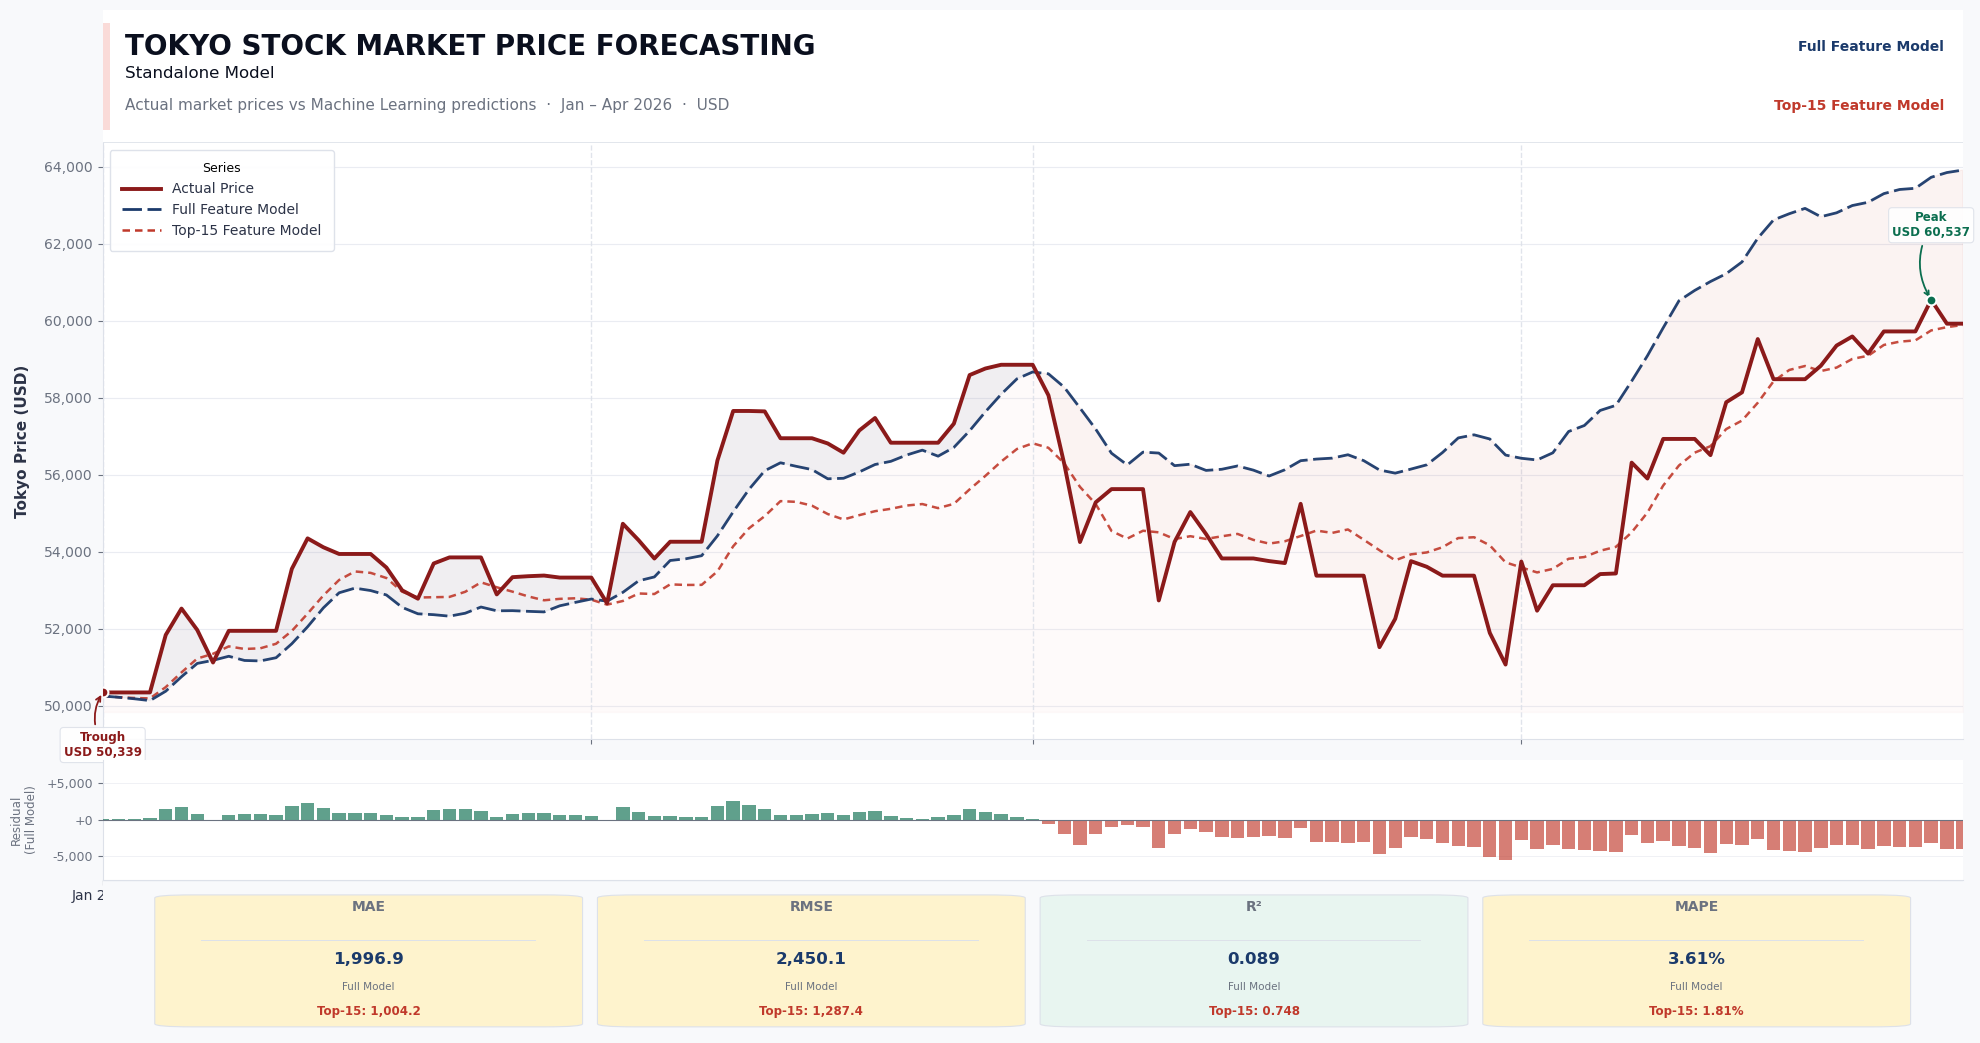

In [185]:
# ── KPI helper ────────────────────────────────────────────────────────────────
def kpis_Tokyo(a, p):
    mae  = np.mean(np.abs(a - p))
    rmse = np.sqrt(np.mean((a - p) ** 2))
    r2   = 1 - np.sum((a - p) ** 2) / np.sum((a - a.mean()) ** 2)
    mape = np.mean(np.abs((a - p) / a)) * 100
    return mae, rmse, r2, mape

plot_df_Tokyo   = test_Tokyo.sort_values('date').copy()
dates_Tokyo     = plot_df_Tokyo['date'].values
actual_Tokyo    = plot_df_Tokyo[target_col_Tokyo].values
full_pred_Tokyo = plot_df_Tokyo['pred_price'].values
top_pred_Tokyo  = plot_df_Tokyo['pred_price_top'].values

mae_f_Tokyo, rmse_f_Tokyo, r2_f_Tokyo, mape_f_Tokyo = kpis_Tokyo(actual_Tokyo, full_pred_Tokyo)
mae_t_Tokyo, rmse_t_Tokyo, r2_t_Tokyo, mape_t_Tokyo = kpis_Tokyo(actual_Tokyo, top_pred_Tokyo)

# ── Palette ───────────────────────────────────────────────────────────────────
PAGE, WHITE, BORDER, GRID = '#F8F9FB', '#FFFFFF', '#DDE1E9', '#EAECF2'
MKT_DARK  = '#8B1A1A'
MKT_FILL  = '#FADBD8'
NAVY      = '#1B3A6B'
CRIMSON   = '#C0392B'
TEXT_H, TEXT_B, TEXT_M = '#0A0F1E', '#2C3347', '#6B7280'
GREEN_KPI, GREEN_BG     = '#0B6E4F', '#E8F5F0'
RED_KPI                 = '#8B1A1A'
AMBER_KPI, AMBER_BG     = '#7A4F00', '#FEF3CD'

# ── Figure & layout ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 11), facecolor=PAGE)
outer = gridspec.GridSpec(3, 1, height_ratios=[0.13, 0.72, 0.15],
                          hspace=0, left=0.04, right=0.97, top=0.97, bottom=0.04)

# ── Header band ───────────────────────────────────────────────────────────────
ax_head = fig.add_subplot(outer[0])
ax_head.set_facecolor(WHITE)
ax_head.set_xlim(0, 1); ax_head.set_ylim(0, 1)
for sp in ax_head.spines.values(): sp.set_visible(False)
ax_head.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax_head.add_patch(mpatches.FancyBboxPatch((0, 0.1), 0.004, 0.8,
    boxstyle='square,pad=0', fc=MKT_FILL, ec='none',
    transform=ax_head.transAxes, clip_on=False))
ax_head.text(0.012, 0.72, 'TOKYO STOCK MARKET PRICE FORECASTING', transform=ax_head.transAxes,
             fontsize=20, fontweight='bold', color=TEXT_H, va='center')
ax_head.text(0.012, 0.52, 'Standalone Model', transform=ax_head.transAxes,
             fontsize=12, fontweight='normal', color=TEXT_H, va='center')
ax_head.text(0.012, 0.28,
    'Actual market prices vs Machine Learning predictions  ·  Jan – Apr 2026  ·  USD',
    transform=ax_head.transAxes, fontsize=11, color=TEXT_M, va='center')
ax_head.text(0.99, 0.72, 'Full Feature Model', transform=ax_head.transAxes,
             fontsize=10, fontweight='bold', color=NAVY, ha='right', va='center')
ax_head.text(0.99, 0.28, f'Top-{top_k_Tokyo} Feature Model', transform=ax_head.transAxes,
             fontsize=10, fontweight='bold', color=CRIMSON, ha='right', va='center')
ax_head.axhline(0, color=BORDER, linewidth=1.2)

# ── Chart + residual ──────────────────────────────────────────────────────────
inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[1],
                                         height_ratios=[5, 1], hspace=0.06)
ax   = fig.add_subplot(inner[0])
ax_r = fig.add_subplot(inner[1], sharex=ax)

for a in [ax, ax_r]:
    a.set_facecolor(WHITE)
    a.tick_params(colors=TEXT_M, labelsize=10)
    for sp in a.spines.values(): sp.set_edgecolor(BORDER); sp.set_linewidth(0.8)
    a.spines['top'].set_visible(False); a.spines['right'].set_visible(False)

# fills
ax.fill_between(dates_Tokyo, actual_Tokyo, actual_Tokyo.min() - actual_Tokyo.min() * 0.01,
    color=MKT_FILL, alpha=0.12, zorder=1)
ax.fill_between(dates_Tokyo, actual_Tokyo, full_pred_Tokyo,
    where=(actual_Tokyo >= full_pred_Tokyo), color=NAVY,    alpha=0.06, zorder=2, interpolate=True)
ax.fill_between(dates_Tokyo, actual_Tokyo, full_pred_Tokyo,
    where=(actual_Tokyo < full_pred_Tokyo),  color=CRIMSON, alpha=0.06, zorder=2, interpolate=True)

# lines
ax.plot(dates_Tokyo, actual_Tokyo,    color=MKT_DARK, linewidth=2.8, zorder=6,
        solid_capstyle='round', label='Actual Price')
ax.plot(dates_Tokyo, full_pred_Tokyo, color=NAVY,     linewidth=2.0, linestyle=(0,(7,2)),
        zorder=5, alpha=0.95, label='Full Feature Model')
ax.plot(dates_Tokyo, top_pred_Tokyo,  color=CRIMSON,  linewidth=1.8, linestyle=(0,(3,2)),
        zorder=4, alpha=0.90, label=f'Top-{top_k_Tokyo} Feature Model')

# month dividers
for ms in pd.date_range(plot_df_Tokyo['date'].min(), plot_df_Tokyo['date'].max(), freq='MS'):
    ax.axvline(ms, color=BORDER, linewidth=1.0, linestyle='--', alpha=0.9, zorder=1)
ax.set_xlim(dates_Tokyo[0], dates_Tokyo[-1])

# peak & trough annotations
pidx_Tokyo = np.argmax(actual_Tokyo)
pval_Tokyo = actual_Tokyo[pidx_Tokyo]
pdate_Tokyo = dates_Tokyo[pidx_Tokyo]
tidx_Tokyo = np.argmin(actual_Tokyo)
tval_Tokyo = actual_Tokyo[tidx_Tokyo]
tdate_Tokyo = dates_Tokyo[tidx_Tokyo]
offset_Tokyo = actual_Tokyo.mean() * 0.03
for x, y, lbl, col, ya, arc in [
    (pdate_Tokyo, pval_Tokyo, f'Peak\nUSD {pval_Tokyo:,.0f}',   GREEN_KPI, pval_Tokyo + offset_Tokyo,   0.3),
    (tdate_Tokyo, tval_Tokyo, f'Trough\nUSD {tval_Tokyo:,.0f}', RED_KPI,   tval_Tokyo - offset_Tokyo,  -0.3),
]:
    ax.annotate(lbl, xy=(x, y), xytext=(x, ya), color=col,
        fontsize=8.5, fontweight='bold', ha='center',
        arrowprops=dict(arrowstyle='->', color=col,
            connectionstyle=f'arc3,rad={arc}', lw=1.3),
        bbox=dict(boxstyle='round,pad=0.3', fc=WHITE, ec=BORDER, alpha=0.9, lw=0.8),
        zorder=10)
    ax.scatter([x], [y], color=col, s=50, zorder=11, edgecolors=WHITE, linewidths=1.5)

# grid & labels
ax.yaxis.grid(True, color=GRID, linewidth=0.8, zorder=0); ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_ylabel(f'Tokyo Price (USD)', color=TEXT_B, fontsize=11,
              fontweight='bold', labelpad=10)
ax.tick_params(axis='x', labelbottom=False)

ax.legend(handles=[
    Line2D([0], [0], color=MKT_DARK, linewidth=2.8,                      label='Actual Price'),
    Line2D([0], [0], color=NAVY,      linewidth=2.0, linestyle=(0,(7,2)), label='Full Feature Model'),
    Line2D([0], [0], color=CRIMSON,   linewidth=1.8, linestyle=(0,(3,2)), label=f'Top-{top_k_Tokyo} Feature Model'),
], loc='upper left', frameon=True, framealpha=0.95, facecolor=WHITE, edgecolor=BORDER,
   labelcolor=TEXT_B, fontsize=10, borderpad=0.9, handlelength=2.8,
   title='Series', title_fontsize=9)

# residual strip
res_Tokyo = actual_Tokyo - full_pred_Tokyo
ax_r.bar(dates_Tokyo, res_Tokyo,
         color=[GREEN_KPI if v >= 0 else CRIMSON for v in res_Tokyo],
         alpha=0.65, width=0.85, zorder=3)
ax_r.axhline(0, color=TEXT_M, linewidth=0.8, zorder=4)
ax_r.yaxis.grid(True, color=GRID, linewidth=0.5, zorder=0); ax_r.set_axisbelow(True)
ax_r.set_ylabel('Residual\n(Full Model)', color=TEXT_M, fontsize=8.5, labelpad=6)
ax_r.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+,.0f}'))
ax_r.tick_params(colors=TEXT_M, labelsize=9)
pad_Tokyo = max(abs(res_Tokyo.min()), abs(res_Tokyo.max())) * 1.5
ax_r.set_ylim(-pad_Tokyo, pad_Tokyo)
ax_r.xaxis.set_major_locator(mdates.MonthLocator())
ax_r.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax_r.tick_params(axis='x', labelsize=10, colors=TEXT_B)

# ── KPI strip ─────────────────────────────────────────────────────────────────
ax_kpi = fig.add_subplot(outer[2])
ax_kpi.set_facecolor(PAGE); ax_kpi.set_xlim(0, 1); ax_kpi.set_ylim(0, 1)
for sp in ax_kpi.spines.values(): sp.set_visible(False)
ax_kpi.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax_kpi.axhline(1.0, color=BORDER, linewidth=1.0)

kpi_cards_Tokyo = [
    ('MAE',  f'{mae_f_Tokyo:,.1f}',  f'{mae_t_Tokyo:,.1f}',  AMBER_KPI, AMBER_BG),
    ('RMSE', f'{rmse_f_Tokyo:,.1f}', f'{rmse_t_Tokyo:,.1f}', AMBER_KPI, AMBER_BG),
    ('R²',   f'{r2_f_Tokyo:.3f}',    f'{r2_t_Tokyo:.3f}',    GREEN_KPI, GREEN_BG),
    ('MAPE', f'{mape_f_Tokyo:.2f}%', f'{mape_t_Tokyo:.2f}%', AMBER_KPI, AMBER_BG),
]
card_w = 0.19
gap    = (1.0 - len(kpi_cards_Tokyo) * card_w) / (len(kpi_cards_Tokyo) + 1)
for i, (metric, vf, vt, tcol, bgcol) in enumerate(kpi_cards_Tokyo):
    x0 = gap + i * (card_w + gap); xc = x0 + card_w / 2
    ax_kpi.add_patch(mpatches.FancyBboxPatch((x0, 0.06), card_w, 0.82,
        boxstyle='round,pad=0.02', fc=bgcol, ec=BORDER, linewidth=0.8,
        transform=ax_kpi.transAxes, clip_on=False))
    ax_kpi.text(xc, 0.82, metric, transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=10, fontweight='bold', color=TEXT_M)
    ax_kpi.add_patch(mpatches.FancyBboxPatch((x0 + 0.005, 0.60), card_w - 0.01, 0.005,
        boxstyle='square,pad=0', fc=BORDER, ec='none',
        transform=ax_kpi.transAxes, clip_on=False))
    ax_kpi.text(xc, 0.48, vf, transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=12, fontweight='bold', color=NAVY)
    ax_kpi.text(xc, 0.30, 'Full Model', transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=7.5, color=TEXT_M)
    ax_kpi.text(xc, 0.14, f'Top-{top_k_Tokyo}: {vt}', transform=ax_kpi.transAxes,
        ha='center', va='center', fontsize=8.5, fontweight='bold', color=CRIMSON)

plt.savefig(ai_data_dir / 'visualizations'/'standalone_Tokyo_price_prediction_model.png',
            dpi=300, bbox_inches='tight', facecolor=PAGE)
plt.show()

<h4 style="color: #CEDDF4;"> 10.23 Tokyo Price Prediction (tomorrow)</h4>

In [186]:
latest_top_Tokyo = X_test_top_Tokyo.iloc[-1:]

pred_return_tomorrow_Tokyo = top_model_Tokyo.predict(latest_top_Tokyo)[0]

last_log_price_Tokyo = np.log(train_Tokyo[target_col_Tokyo].iloc[-1])

pred_price_tomorrow_Tokyo = np.exp(last_log_price_Tokyo + pred_return_tomorrow_Tokyo)

print("Predicted Tokyo Price Tomorrow:", pred_price_tomorrow_Tokyo)

Predicted Tokyo Price Tomorrow: 50385.00382857387
